# BI10 Round 1 - Consumer Financial Health & Engagement 2025


| Phần | Nội dung |
|---|---|
| 0. Setup | Đường dẫn, nhãn, bảng màu, hàm vẽ/lưu chart |
| 1. Preprocess | Đọc 2 file CSV, kiểm tra chất lượng dữ liệu, tạo feature, cache parquet |
| 2. Task 1 | EDA - Q1 tháng cao điểm, Q2 thiết yếu vs không thiết yếu, Q3 tỉnh & kênh số, Q4 danh mục, Q5 nhóm tuổi |
| 3. Task 2 | Financial health - phân phối, driver, khác biệt theo nhóm, nhóm *stressed but highly engaged* |
| 4. Task 3 | Engagement - phân phối, kênh, đa dạng danh mục, recency/frequency, nhóm *healthy but disengaged* |

**Output:** mỗi cell chart hiển thị chart ngay bên dưới, tiếp theo là cell **Findings** tóm tắt số liệu và nhận định.

**Định nghĩa dùng xuyên suốt:** *Digital* = mọi kênh không phải POS (QR, E-commerce, Mobile App, Recurring).
*Online* = theo `online_transaction_flag` (**không** gồm QR). `financial_health_score` là chỉ số sức khỏe tài chính,
**không phải** điểm tín dụng.

## 0. Setup


### Imports & paths

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.transforms import ScaledTranslation

# Notebook sits in the "Vòng 1" folder (next to BI10_ROUND01_DATASET)
ROOT = Path.cwd() if (Path.cwd() / "BI10_ROUND01_DATASET").exists() else Path.cwd().parent
RAW = ROOT / "BI10_ROUND01_DATASET"
CACHE = ROOT / "data_cache"
OUT = ROOT / "outputs"
TABLES = OUT / "tables"
for p in (CACHE, TABLES):
    p.mkdir(parents=True, exist_ok=True)

TXN_CSV = RAW / "consumer_transactions_2025.csv"
CM_CSV = RAW / "consumer_financial_health_engagement_2025.csv"
TXN_PQ = CACHE / "transactions.parquet"
CM_PQ = CACHE / "consumer_month.parquet"
CUST_PQ = CACHE / "customer_features.parquet"

### Labels

In [ ]:
CATEGORY_EN = {
    "Chăm sóc cá nhân": "Personal care",
    "Du lịch": "Travel",
    "Dịch vụ trực tuyến khác": "Other online services",
    "Giải trí": "Entertainment",
    "Mua sắm khác tại cửa hàng": "Other in-store shopping",
    "Mua sắm trực tuyến": "Online shopping",
    "Mua sắm tại cửa hàng": "In-store shopping",
    "Nhà cửa và tiện ích": "Home & utilities",
    "Siêu thị và tạp hóa tại cửa hàng": "Supermarket & grocery (in-store)",
    "Sức khỏe và thể thao": "Health & fitness",
    "Trẻ em và thú cưng": "Kids & pets",
    "Tạp hóa trực tuyến": "Online grocery",
    "Xăng dầu và di chuyển": "Fuel & transport",
    "Ăn uống": "Food & dining",
}
HEALTH_SEG_EN = {
    "Có dấu hiệu căng thẳng tài chính": "Stressed",
    "Căng thẳng": "Stressed",
    "Cần theo dõi": "Watch",
    "Ổn định": "Stable",
    "Khỏe mạnh": "Healthy",
}
HEALTH_ORDER = ["Stressed", "Watch", "Stable", "Healthy"]
ENG_SEG_EN = {
    "Tương tác thấp": "Low",
    "Tương tác trung bình": "Medium",
    "Tương tác cao": "High",
    "Tương tác rất cao": "Very high",
}
ENG_ORDER = ["Low", "Medium", "High", "Very high"]
CHANNEL_ORDER = ["POS", "QR Payment", "E-commerce", "Mobile App", "Recurring Payment"]
AGE_BINS = [0, 17, 24, 34, 44, 54, 64, 200]
AGE_LABELS = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
DOW = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Keyword rules, evaluated in order; first match wins. Exported to tables/occupation_mapping.csv.
OCCUPATION_RULES = [
    ("Healthcare", ["Bác sĩ", "Dược", "Điều dưỡng", "y tế", "Y tế", "lâm sàng", "trị liệu", "cứu thương",
                    "cấp cứu", "Thầy thuốc", "tâm lý", "châm cứu", "nắn chỉnh", "bàn chân", "chỉnh thị",
                    "kính thuốc", "đo mắt", "thính học", "xạ trị", "chẩn đoán", "Thư ký y khoa", "vi lượng",
                    "sinh lý vận động", "Nhà vật lý y", "Trình dược"]),
    ("Education", ["Giáo viên", "Giảng viên", "giáo sư", "Giáo sư", "hướng dẫn học tập", "Thủ thư", "giáo dục",
                   "hướng nghiệp"]),
    ("Finance, legal & business", ["tài chính", "Kế toán", "kế toán", "ngân hàng", "giao dịch", "môi giới",
                                   "bảo hiểm", "thuế", "Thuế", "đầu tư", "Luật", "pháp", "Thư ký", "kinh doanh",
                                   "thu mua", "Giám đốc", "giám đốc", "Chánh văn phòng", "rủi ro", "hưu trí",
                                   "Nhà kinh tế", "nhân sự", "tư vấn quản lý", "bán hàng", "công chứng",
                                   "Nhà thống kê"]),
    ("Engineering & IT", ["Kỹ sư", "Kỹ thuật viên", "Lập trình", "công nghệ thông tin", "dữ liệu",
                          "phân tích hệ thống", "Nhà thiết kế web", "Quản lý hệ thống", "Kiểm soát viên không lưu",
                          "Phi công", "Nhà thầu"]),
    ("Science & research", ["Nhà khoa học", "nghiên cứu", "Nghiên cứu", "di truyền", "hóa học", "Nhà hóa",
                            "địa chất", "Nhà địa", "sinh thái", "hải dương", "thủy văn", "dược lý", "độc chất",
                            "miễn dịch", "luyện kim", "khảo cổ", "khảo sát", "trắc địa", "địa chấn", "phôi học",
                            "bò sát", "Nhà vật lý", "tình báo"]),
    ("Media, arts & design", ["Biên tập", "báo", "Nhà văn", "Họa sĩ", "Nghệ", "nghệ thuật", "nhạc", "Nhạc",
                              "Vũ công", "thiết kế", "phim", "truyền hình", "phát thanh", "quảng cáo", "tiếp thị",
                              "truyền thông", "công chúng", "Kiến trúc sư", "Đạo diễn", "trang điểm", "hoạt hình",
                              "kỹ xảo", "sân khấu", "trường quay", "bối cảnh", "Phóng viên", "Thông dịch",
                              "từ điển", "màu sắc", "trưng bày", "sự kiện", "Người bán sách", "bản đồ",
                              "phục chế", "nội dung", "phòng tranh", "Nhà sản xuất", "ánh sáng", "Người dẫn",
                              "Người quay"]),
    ("Public service & security", ["Cán bộ", "Công chức", "Cảnh sát", "Lính", "Sĩ quan", "Kiểm lâm", "Thanh tra",
                                   "chính", "cứu trợ", "cộng đồng", "từ thiện", "tình nguyện", "Trợ lý chính trị",
                                   "lưu trữ", "an toàn lao động", "vệ sinh lao động", "Người phụ trách bảo tàng"]),
    ("Agriculture & environment", ["nông", "lâm", "cây", "vườn", "chăn nuôi", "thủy sản", "môi trường",
                                   "thổ nhưỡng", "giống", "vật nuôi", "đất đai", "quy hoạch", "Quản lý mỏ",
                                   "năng lượng"]),
    ("Management & services", ["Quản lý", "Quản trị", "Nhân viên", "Tiếp viên", "Trợ lý", "Điều phối",
                               "Tổng giám đốc", "Thư"]),
]


def occupation_group(name: str) -> str:
    for group, keys in OCCUPATION_RULES:
        if any(k in name for k in keys):
            return group
    return "Other"

### Palette (dataviz reference instance, light)

In [ ]:
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948")
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
GRAY = "#c3c2b7"          # de-emphasised marks / baseline
GRAY_LIGHT = "#e1e0d9"    # gridlines
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
SURFACE = "#fcfcfb"
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
# ordinal ramp for ordered bands (start at step 250 so the lightest mark stays visible)
BLUE_ORDINAL4 = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
DIVERGING = {"neg": RED, "mid": "#f0efec", "pos": BLUE}
SOURCE = "Source: ITB synthetic Consumer Financial Health & Engagement 2025 dataset; team analysis."


def style():
    plt.rcParams.update({
        "font.family": ["Segoe UI", "DejaVu Sans"],
        "font.size": 10.5,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 12,
        "axes.labelcolor": INK_2,
        "axes.edgecolor": GRAY,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRAY_LIGHT,
        "grid.linewidth": 0.6,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "text.color": INK,
        "legend.frameon": False,
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "lines.linewidth": 2,
    })


def show_chart(fig, name, title=None, subtitle=None, note=None):
    """Display a chart inline (nothing is written to disk).
ame is only the chart id used in notebook headings.
    Headline + subtitle sit above the plot area and a source/caption footer below it (figure coords beyond 0-1);
    the inline backend renders with bbox_inches='tight', so the canvas grows to fit them."""
    off = lambda dy: fig.transFigure + ScaledTranslation(0, dy, fig.dpi_scale_trans)  # dy in inches
    if title:
        fig.text(0.01, 1, title, ha="left", va="bottom", fontsize=14, fontweight="bold", color=INK,
                 transform=off(0.42 if subtitle else 0.15))
    if subtitle:
        fig.text(0.01, 1, subtitle, ha="left", va="bottom", fontsize=10.5, color=INK_2, transform=off(0.15))
    footer = SOURCE if note is None else f"{note}\n{SOURCE}"
    fig.text(0.01, 0, footer, ha="left", va="top", fontsize=7.5, color=MUTED, transform=off(-0.12))
    plt.show()


def bn(x):
    """VND -> billions (tỷ VND)."""
    return x / 1e9


def pct(x, d=1):
    return f"{x * 100:.{d}f}%"


def load_txn(columns=None):
    return pd.read_parquet(TXN_PQ, columns=columns)


def load_cm():
    return pd.read_parquet(CM_PQ)


def load_cust():
    return pd.read_parquet(CUST_PQ)


class Findings:
    """Collects headline numbers so every figure quoted in slides comes from code output."""

    def __init__(self, name):
        self.name = name
        self.lines = []

    def add(self, text):
        print(text)
        self.lines.append(text)

In [ ]:
%config InlineBackend.figure_format = 'retina'
style()
print('ROOT =', ROOT)

ROOT = D:\Đại học\Cuộc thi Data\Business Intelligence 2026\Vòng 1


## 1. Preprocess

Reads both raw files once, caches them as parquet, engineers the fields used by Tasks 1-3,
and writes a data-quality summary. Run this first.

In [ ]:
import numpy as np
import pandas as pd

### Transactions -> parquet (only the fields the analysis needs; PII such as names/addresses dropped)

In [ ]:
txn_cols = ["transaction_id", "activity_datetime", "consumer_id", "gender", "age_at_transaction", "occupation",
            "province_city", "merchant_id", "spending_category", "spend_amount_vnd", "transaction_channel",
            "payment_method", "online_transaction_flag", "essential_spending_flag", "transaction_month",
            "transaction_day_of_week", "transaction_hour"]
cat_cols = ["consumer_id", "gender", "occupation", "province_city", "merchant_id", "spending_category",
            "transaction_channel", "payment_method"]
t = pd.read_csv(TXN_CSV, usecols=txn_cols, dtype={c: "category" for c in cat_cols})
t["activity_datetime"] = pd.to_datetime(t["activity_datetime"])
for c in ["online_transaction_flag", "essential_spending_flag", "transaction_month", "transaction_day_of_week",
          "transaction_hour", "age_at_transaction"]:
    t[c] = t[c].astype("int16")
t["category_en"] = t["spending_category"].map(CATEGORY_EN).astype("category")
# "Digital" = any non-POS channel. QR Payment carries online_flag = 0 in the data, so digital != online.
t["digital_flag"] = (t["transaction_channel"] != "POS").astype("int8")
t["date"] = t["activity_datetime"].dt.normalize()
t.to_parquet(TXN_PQ, index=False)
print("transactions", t.shape)

transactions (1852394, 20)


### Data-quality checks (recorded for the Introduction slide / appendix)

In [ ]:
m = pd.read_csv(CM_CSV)
dq = []
def chk(name, value, ok=None):
    dq.append({"check": name, "value": value, "status": "" if ok is None else ("PASS" if ok else "NOTE")})

chk("Transaction rows", len(t))
chk("Consumer-month rows", len(m))
chk("Distinct consumers (txn / monthly)", f"{t.consumer_id.nunique()} / {m.consumer_id.nunique()}")
chk("Distinct merchants", t.merchant_id.nunique())
chk("Date range", f"{t.activity_datetime.min()} .. {t.activity_datetime.max()}")
chk("Duplicate transaction_id", int(t.transaction_id.duplicated().sum()), t.transaction_id.duplicated().sum() == 0)
chk("Duplicate consumer-month keys", int(m.duplicated(["consumer_id", "analysis_month"]).sum()),
    m.duplicated(["consumer_id", "analysis_month"]).sum() == 0)
chk("Missing values in transactions", int(t.isna().sum().sum()), t.isna().sum().sum() == 0)
chk("Missing next_month_low_health_flag (last month of each consumer, by design)",
    int(m.next_month_low_health_flag.isna().sum()))
chk("Min / max spend_amount_vnd", f"{t.spend_amount_vnd.min():,} / {t.spend_amount_vnd.max():,}",
    t.spend_amount_vnd.min() > 0)

agg = (t.assign(on=t.spend_amount_vnd * t.online_transaction_flag, es=t.spend_amount_vnd * t.essential_spending_flag,
                dg=t.spend_amount_vnd * t.digital_flag)
         .groupby(["consumer_id", "transaction_month"], observed=True)
         .agg(spend=("spend_amount_vnd", "sum"), n=("spend_amount_vnd", "size"), on=("on", "sum"),
              es=("es", "sum"), digital_spend_vnd=("dg", "sum"), digital_txn_count=("digital_flag", "sum"))
         .reset_index())
m["transaction_month"] = pd.to_datetime(m.analysis_month).dt.month
j = m.merge(agg, on=["consumer_id", "transaction_month"], how="left")
recon = ((j.total_spend_vnd == j.spend) & (j.transaction_count == j.n) & (j.online_spend_vnd == j.on)
         & (j.essential_spend_vnd == j.es)).mean()
chk("Consumer-month totals reconcile with transactions (spend, count, online, essential)", f"{recon:.1%}",
    recon == 1)
chk("QR Payment rows flagged online", int(((t.transaction_channel == "QR Payment") & (t.online_transaction_flag == 1)).sum()),
    None)
chk("Health-segment label mismatch vs dictionary ('Có dấu hiệu căng thẳng tài chính' vs 'Căng thẳng')",
    int((m.financial_health_segment == "Có dấu hiệu căng thẳng tài chính").sum()), False)
months_per = m.groupby("consumer_id").size()
chk("Consumers with 12 / 2 / 1 months of data",
    f"{(months_per == 12).sum()} / {(months_per == 2).sum()} / {(months_per == 1).sum()}", False)
chk("Consumer-months with age < 18", int((m.age < 18).sum()), False)
chk("credit_utilization_ratio capped at 1.5", int((m.credit_utilization_ratio >= 1.5).sum()), None)
pd.DataFrame(dq).to_csv(TABLES / "data_quality_checks.csv", index=False, encoding="utf-8-sig")
print(pd.DataFrame(dq).to_string())

                                                                                               check                                       value status
0                                                                                   Transaction rows                                     1852394       
1                                                                                Consumer-month rows                                       10992       
2                                                                 Distinct consumers (txn / monthly)                                   999 / 999       
3                                                                                 Distinct merchants                                         693       
4                                                                                         Date range  2025-01-01 00:00:18 .. 2025-12-31 23:59:53       
5                                                                           Duplicate tr

### Consumer-month enrichment

In [ ]:
m = j.drop(columns=["spend", "n", "on", "es"])
m["analysis_month"] = pd.to_datetime(m.analysis_month)
m["health_seg"] = pd.Categorical(m.financial_health_segment.map(HEALTH_SEG_EN),
                                 ["Stressed", "Watch", "Stable", "Healthy"], ordered=True)
m["eng_seg"] = pd.Categorical(m.engagement_segment.map(ENG_SEG_EN), ["Low", "Medium", "High", "Very high"],
                              ordered=True)
m["age_group"] = pd.cut(m.age, AGE_BINS, labels=AGE_LABELS)
m["occupation_group"] = m.occupation.map(occupation_group)
m["digital_spend_ratio"] = m.digital_spend_vnd / m.total_spend_vnd
m["digital_txn_share"] = m.digital_txn_count / m.transaction_count
m["txn_per_active_day"] = m.transaction_count / m.active_transaction_days
m["balance_change_ratio"] = (m.ending_balance_vnd - m.opening_balance_vnd) / m.monthly_income_vnd
m.to_parquet(CM_PQ, index=False)

occ = (m.drop_duplicates("consumer_id").groupby(["occupation_group", "occupation"]).size()
         .rename("customers").reset_index())
occ.to_csv(TABLES / "occupation_mapping.csv", index=False, encoding="utf-8-sig")
print(m.drop_duplicates("consumer_id").occupation_group.value_counts())

occupation_group
Media, arts & design         180
Healthcare                   163
Engineering & IT             143
Finance, legal & business    139
Science & research           113
Public service & security     89
Education                     70
Management & services         43
Agriculture & environment     39
Other                         20
Name: count, dtype: int64


### Customer-level feature table (mean over the customer's observed months)

In [ ]:
ratio_cols = ["financial_health_score", "engagement_score", "essential_spend_ratio", "discretionary_spend_ratio",
              "online_spend_ratio", "digital_spend_ratio", "digital_txn_share", "spend_to_income_ratio",
              "credit_utilization_ratio", "spending_volatility", "category_diversity", "transaction_count",
              "active_transaction_days", "transaction_recency_days", "txn_per_active_day",
              "average_transaction_value_vnd", "balance_change_ratio"]
cust = m.groupby("consumer_id").agg(
    months_observed=("analysis_month", "size"),
    age=("age", "max"), gender=("gender", "first"), occupation=("occupation", "first"),
    occupation_group=("occupation_group", "first"), province_city=("province_city", "first"),
    total_spend_vnd=("total_spend_vnd", "sum"),
    min_health=("financial_health_score", "min"), max_health=("financial_health_score", "max"),
    stressed_months=("financial_health_score", lambda s: (s < 40).sum()),
    low_health_months=("financial_health_score", lambda s: (s < 60).sum()),
    healthy_months=("financial_health_score", lambda s: (s >= 80).sum()),
    **{c: (c, "mean") for c in ratio_cols})
# Channel mix per customer (share of transactions) and annual distinct categories, from transactions
ch = pd.crosstab(t.consumer_id, t.transaction_channel, normalize="index").add_prefix("share_txn_")
ch.columns = [c.replace(" ", "_") for c in ch.columns]
cust = cust.join(ch)
cust["channels_used"] = pd.crosstab(t.consumer_id, t.transaction_channel).gt(0).sum(axis=1)
cust["annual_category_diversity"] = t.groupby("consumer_id", observed=True).spending_category.nunique()
cust["age_group"] = pd.cut(cust.age, AGE_BINS, labels=AGE_LABELS)
cust["health_seg"] = pd.cut(cust.financial_health_score, [-1, 40, 60, 80, 101], right=False,
                            labels=["Stressed", "Watch", "Stable", "Healthy"])
cust["eng_seg"] = pd.cut(cust.engagement_score, [-1, 40, 60, 80, 101], right=False,
                         labels=["Low", "Medium", "High", "Very high"])
cust.reset_index().to_parquet(CUST_PQ, index=False)
print("customers", cust.shape)

customers (999, 39)


## 2. Task 1 - Exploratory data analysis

Every number quoted in the slides is printed here and saved to outputs/findings_task1.md.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter

style()
F = Findings("task1")
t = load_txn(["transaction_month", "spend_amount_vnd", "date", "category_en", "consumer_id", "digital_flag",
              "essential_spending_flag", "transaction_channel", "province_city", "transaction_hour",
              "transaction_day_of_week"])
m = load_cm()
annual = t.spend_amount_vnd.sum()
F.add(f"# Task 1 findings\n\nAnnual spend: {bn(annual):,.1f} bn VND across {len(t):,} transactions.")

# Task 1 findings

Annual spend: 3,244.6 bn VND across 1,852,394 transactions.


### Q1 peak month

In [ ]:
mo = t.groupby("transaction_month").agg(S=("spend_amount_vnd", "sum"), N=("spend_amount_vnd", "size"),
                                        days=("date", "nunique"), cust=("consumer_id", "nunique"))
mo["ticket"] = mo.S / mo.N
mo["share"] = mo.S / annual
mo["S_per_day"] = mo.S / mo.days
mo["N_per_cust"] = mo.N / mo.cust
mo.to_csv(TABLES / "t1_q1_monthly.csv")
hi, lo = mo.S.idxmax(), mo.S.idxmin()
H, L = mo.loc[hi], mo.loc[lo]
# Midpoint (Shapley) decomposition: dS = dN * avg(T) + dT * avg(N) - exact, no residual
vol_eff = (H.N - L.N) * (H.ticket + L.ticket) / 2
tkt_eff = (H.ticket - L.ticket) * (H.N + L.N) / 2
dS = H.S - L.S
F.add(f"\n## Q1 Peak month\n- Highest: {MONTHS[hi-1]} = {bn(H.S):,.1f} bn VND ({pct(H.share)} of annual spend); "
      f"lowest: {MONTHS[lo-1]} = {bn(L.S):,.1f} bn VND ({pct(L.share)}).")
F.add(f"- Gap = {bn(dS):,.1f} bn VND; peak is {H.S / L.S:.2f}x the trough. Per calendar day: "
      f"{bn(H.S_per_day):.2f} vs {bn(L.S_per_day):.2f} bn/day ({H.S_per_day / L.S_per_day:.2f}x, adjusts for Feb's 28 days).")
F.add(f"- Transactions {H.N:,.0f} vs {L.N:,.0f} ({H.N / L.N:.2f}x); avg ticket {H.ticket:,.0f} vs {L.ticket:,.0f} VND "
      f"({H.ticket / L.ticket - 1:+.1%}).")
F.add(f"- Decomposition of the gap: volume effect {bn(vol_eff):,.1f} bn ({vol_eff / dS:.1%}), "
      f"ticket-size effect {bn(tkt_eff):,.1f} bn ({tkt_eff / dS:.1%}).")
F.add(f"- Active customers {H.cust:.0f} vs {L.cust:.0f}; transactions per active customer {H.N_per_cust:.1f} vs "
      f"{L.N_per_cust:.1f} -> the peak comes from each customer transacting more often, not from more customers.")

rest = t[t.transaction_month != hi]
base = rest.groupby("category_en", observed=True).agg(S=("spend_amount_vnd", "sum"), N=("spend_amount_vnd", "size")) / 11
peak = t[t.transaction_month == hi].groupby("category_en", observed=True).agg(S=("spend_amount_vnd", "sum"),
                                                                              N=("spend_amount_vnd", "size"))
up = pd.DataFrame({"spend_uplift": peak.S / base.S, "count_uplift": peak.N / base.N,
                   "ticket_uplift": (peak.S / peak.N) / (base.S / base.N), "added_bn": bn(peak.S - base.S)})
up.sort_values("added_bn", ascending=False).to_csv(TABLES / "t1_q1_peak_category_uplift.csv")
F.add(f"- vs the Jan-Nov monthly average, {MONTHS[hi-1]} count uplift ranges {up.count_uplift.min():.2f}x-"
      f"{up.count_uplift.max():.2f}x across all 14 categories; ticket uplift {up.ticket_uplift.min():.2f}x-"
      f"{up.ticket_uplift.max():.2f}x -> broad-based frequency surge, not a category- or basket-specific event.")
mix = t.assign(peak=t.transaction_month == hi, es=t.spend_amount_vnd * t.essential_spending_flag)
mixg = mix.groupby("peak").agg(es=("es", "sum"), S=("spend_amount_vnd", "sum"), dig=("digital_flag", "mean"))
F.add(f"- Essential share {pct(mixg.es[True] / mixg.S[True])} in peak vs {pct(mixg.es[False] / mixg.S[False])} "
      f"other months; digital txn share {pct(mixg.dig[True])} vs {pct(mixg.dig[False])} -> spending *structure* is unchanged.")
dec = t[t.transaction_month == hi]
dow_dec = dec.groupby("transaction_day_of_week").spend_amount_vnd.sum() / dec.groupby("transaction_day_of_week").date.nunique()
F.add(f"- Within {MONTHS[hi-1]}, daily spend follows the weekly cycle (Mon/Sun highest: "
      f"{bn(dow_dec.max()):.1f} bn/day vs Wed {bn(dow_dec.min()):.1f}); no single-day spike.")


## Q1 Peak month
- Highest: Dec = 488.0 bn VND (15.0% of annual spend); lowest: Feb = 174.4 bn VND (5.4%).
- Gap = 313.7 bn VND; peak is 2.80x the trough. Per calendar day: 15.74 vs 6.23 bn/day (2.53x, adjusts for Feb's 28 days).
- Transactions 280,598 vs 97,657 (2.87x); avg ticket 1,739,259 vs 1,785,485 VND (-2.6%).
- Decomposition of the gap: volume effect 322.4 bn (102.8%), ticket-size effect -8.7 bn (-2.8%).
- Active customers 918 vs 919; transactions per active customer 305.7 vs 106.3 -> the peak comes from each customer transacting more often, not from more customers.
- vs the Jan-Nov monthly average, Dec count uplift ranges 1.92x-1.99x across all 14 categories; ticket uplift 0.93x-1.08x -> broad-based frequency surge, not a category- or basket-specific event.
- Essential share 45.8% in peak vs 45.8% other months; digital txn share 41.1% vs 41.2% -> spending *structure* is unchanged.
- Within Dec, daily spend follows the weekly cycle (Mon/Sun highest: 21.6 bn/day vs Wed 10.9); n

#### 📊 Chart: `t1_q1_monthly_spend`




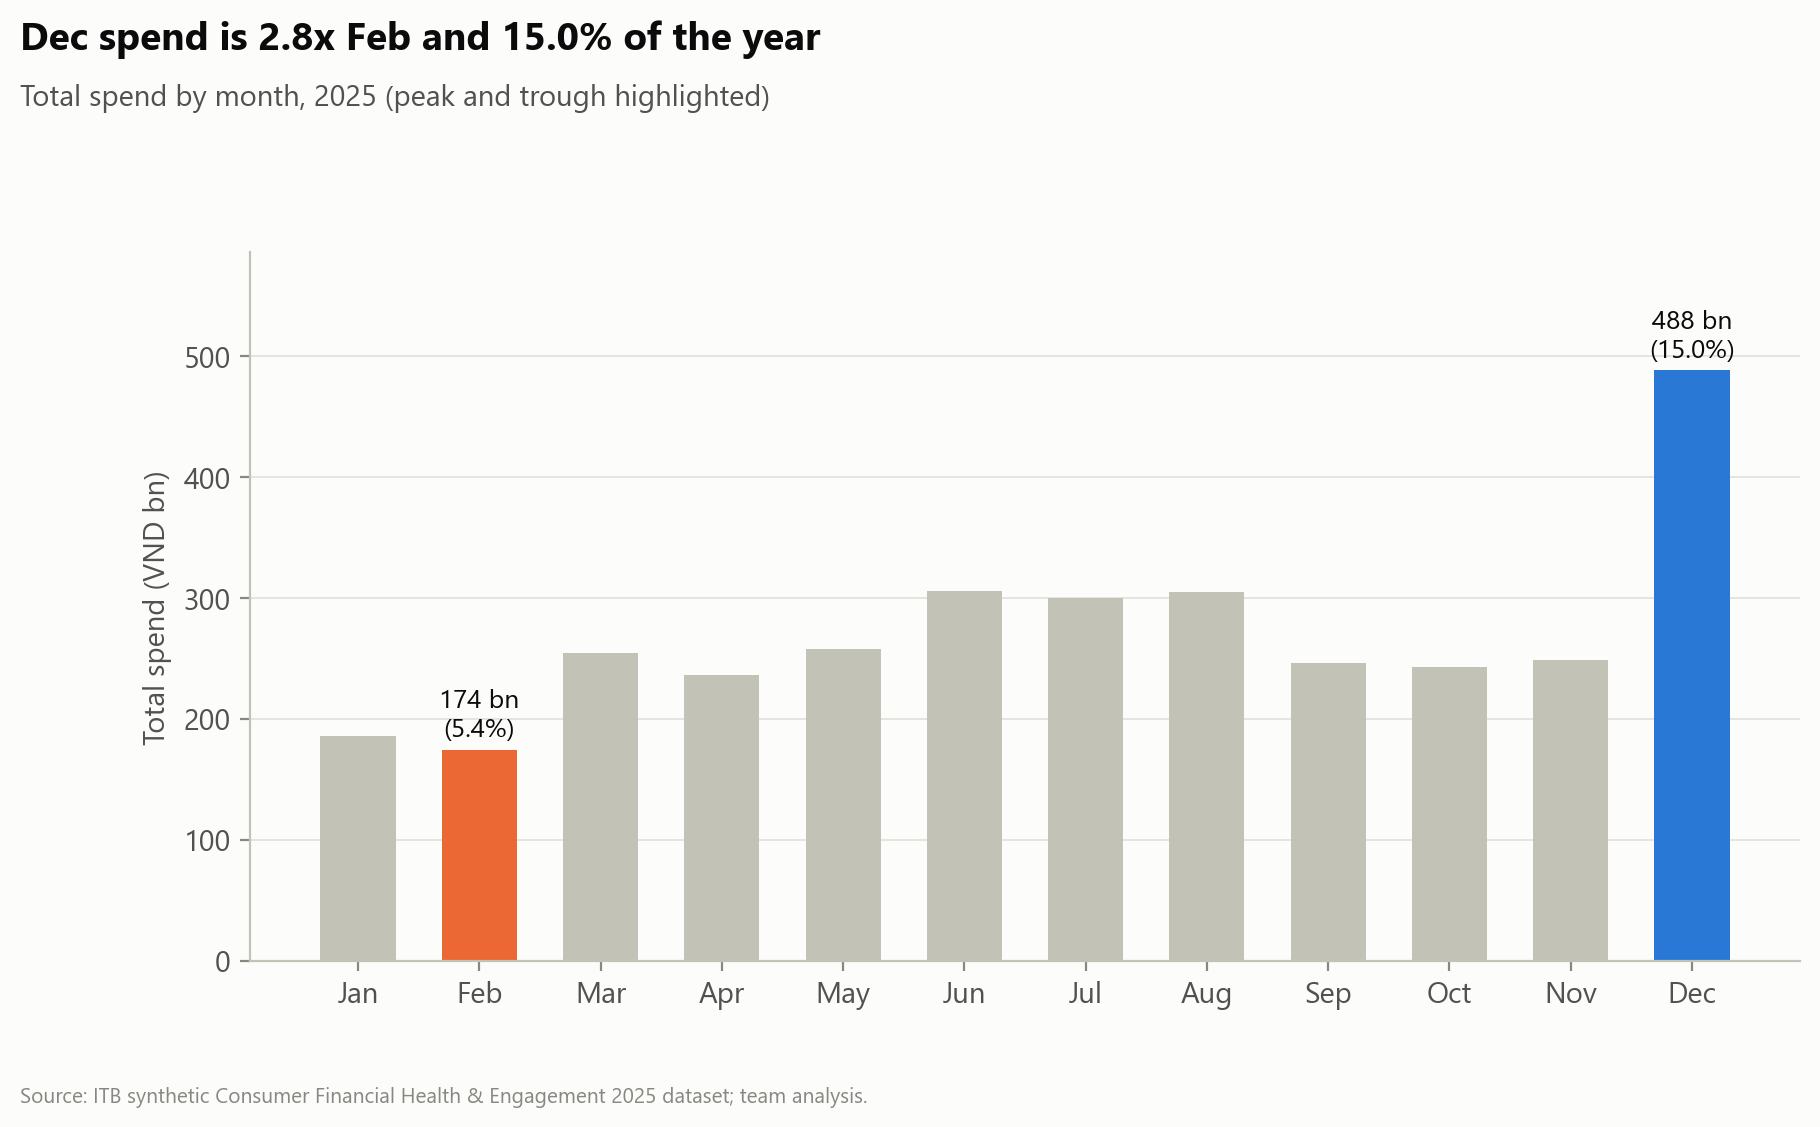

In [ ]:
# Chart Q1a: monthly spend, peak highlighted
fig, ax = plt.subplots(figsize=(10, 4.6))
colors = [BLUE if i == hi else (ORANGE if i == lo else GRAY) for i in mo.index]
ax.bar(MONTHS, bn(mo.S), color=colors, width=0.62)
for i, v in zip(mo.index, bn(mo.S)):
    if i in (hi, lo):
        ax.text(i - 1, v + 6, f"{v:,.0f} bn\n({pct(mo.share[i])})", ha="center", va="bottom", fontsize=9.5, color=INK)
ax.set_ylabel("Total spend (VND bn)")
ax.set_ylim(0, bn(H.S) * 1.2)
ax.grid(axis="x", visible=False)
show_chart(fig, "t1_q1_monthly_spend", title=f"{MONTHS[hi-1]} spend is {H.S / L.S:.1f}x {MONTHS[lo-1]} and {pct(H.share)} of the year", subtitle="Total spend by month, 2025 (peak and trough highlighted)")

**Findings - Q1 Peak month**
- Annual spend: **3,244.6 bn VND** across **1,852,394** transactions.
- Highest month: **December = 488.0 bn VND (15.0% of annual spend)**. Lowest: **February = 174.4 bn VND (5.4%)**.
- The gap is **313.7 bn VND**; the peak is **2.80x** the trough. Per calendar day (adjusting for February's 28 days) it is 15.74 vs 6.23 bn/day (**2.53x**).

#### 📊 Chart: `t1_q1_volume_vs_ticket`

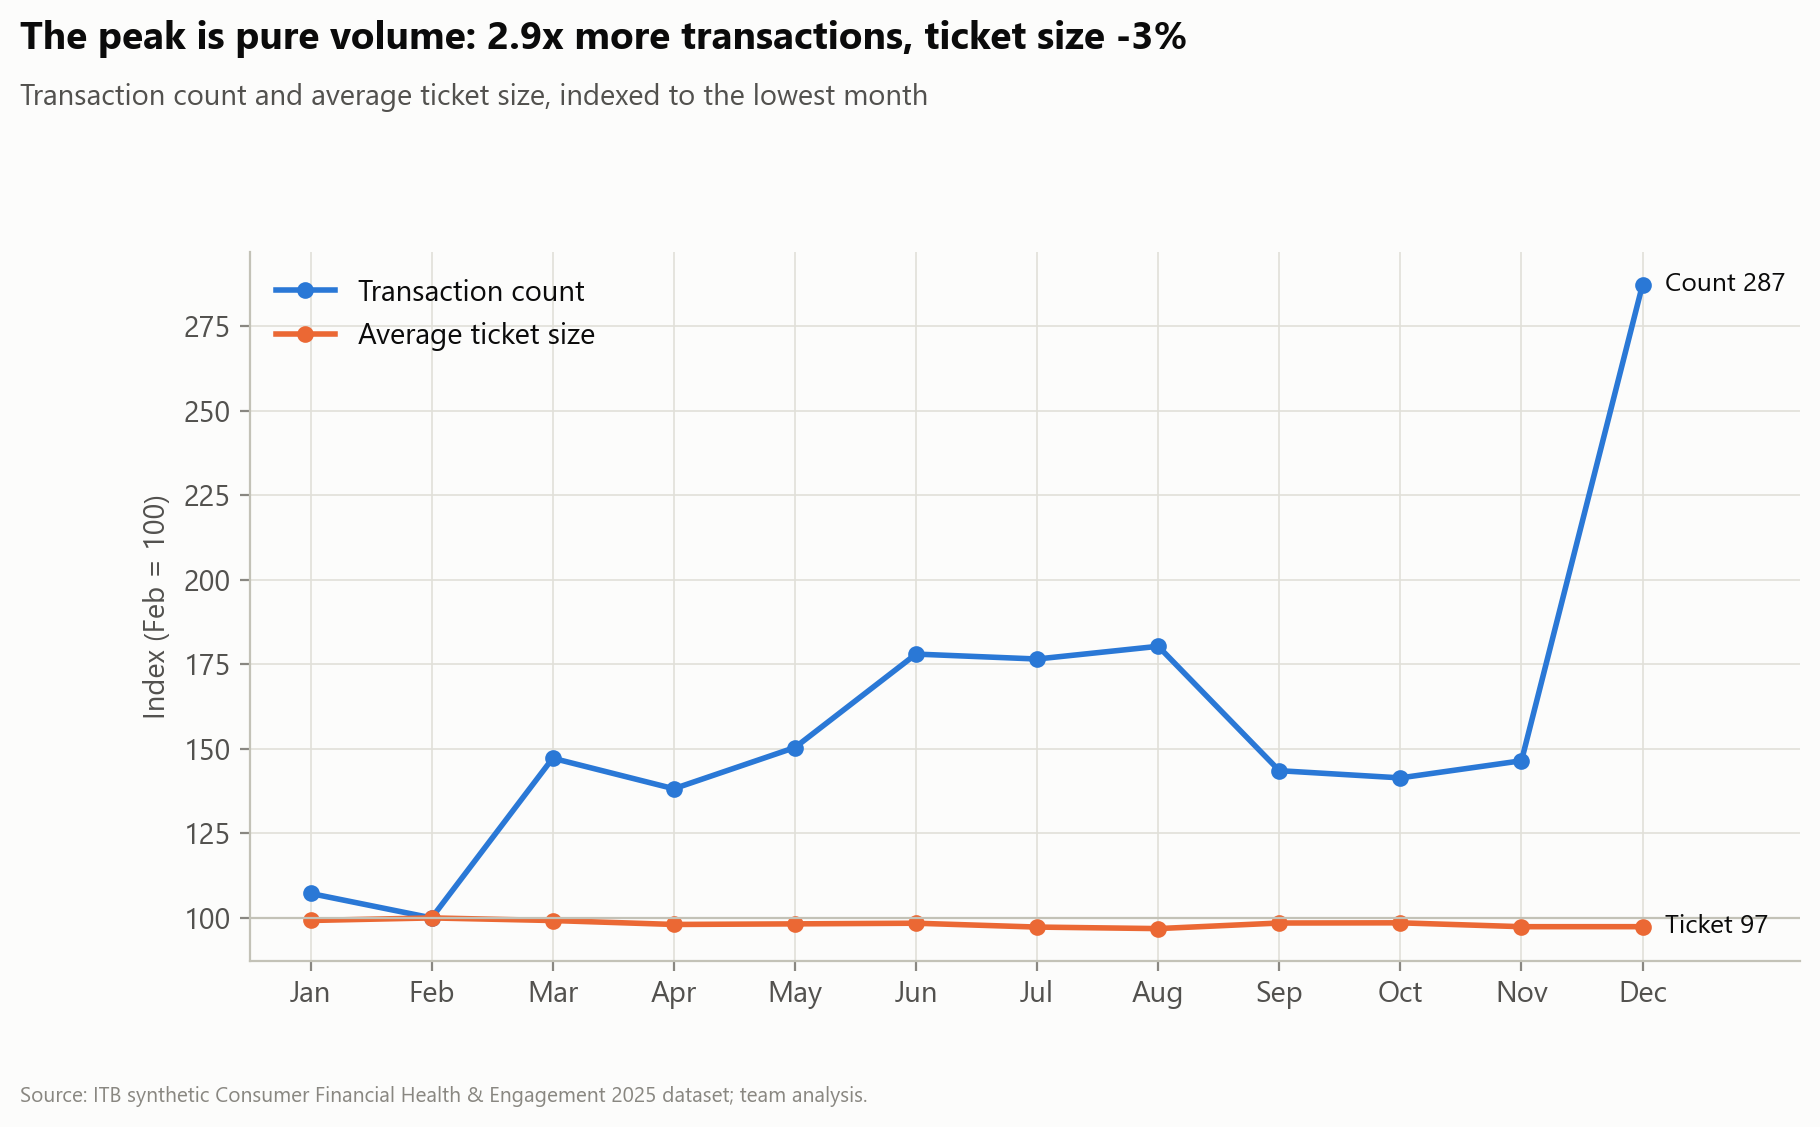

In [ ]:
# Chart Q1b: decomposition - index of N and T vs trough, one axis
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(MONTHS, mo.N / L.N * 100, color=BLUE, marker="o", ms=5, label="Transaction count")
ax.plot(MONTHS, mo.ticket / L.ticket * 100, color=ORANGE, marker="o", ms=5, label="Average ticket size")
ax.axhline(100, color=GRAY, lw=0.8)
ax.set_ylabel(f"Index ({MONTHS[lo-1]} = 100)")
ax.annotate(f"Count {H.N / L.N * 100:.0f}", (hi - 1, H.N / L.N * 100), xytext=(8, 0), textcoords="offset points",
            color=INK, va="center", fontsize=9.5)
ax.annotate(f"Ticket {H.ticket / L.ticket * 100:.0f}", (hi - 1, H.ticket / L.ticket * 100), xytext=(8, 0),
            textcoords="offset points", color=INK, va="center", fontsize=9.5)
ax.legend(loc="upper left")
ax.set_xlim(-0.5, 12.3)
show_chart(fig, "t1_q1_volume_vs_ticket", title=f"The peak is pure volume: {H.N / L.N:.1f}x more transactions, ticket size {H.ticket / L.ticket - 1:+.0%}",
     subtitle="Transaction count and average ticket size, indexed to the lowest month")

**Findings - Q1 volume vs ticket size**
- Transactions: **280,598 vs 97,657 (2.87x)**. Average ticket: **1,739,259 vs 1,785,485 VND (-2.6%)**.
- Decomposition of the Dec-Feb gap: **volume effect +322.4 bn (102.8%)**, ticket-size effect **-8.7 bn (-2.8%)**. The peak is entirely driven by transaction count.
- Active customers are almost identical (918 vs 919), but transactions per active customer are **305.7 vs 106.3**. Each customer transacts more often; the peak does not come from more customers.
- Against the Jan-Nov monthly average, December's count uplift is **1.92x-1.99x in all 14 categories** and its ticket uplift only 0.93x-1.08x. This is a broad-based frequency surge, not a category- or basket-specific event.
- Spending *structure* is unchanged: essential share is 45.8% in the peak vs 45.8% in other months, and digital share is 41.1% vs 41.2%.
- Within December, daily spend follows the weekly cycle (Mon/Sun highest at 21.6 bn/day vs Wed 10.9). There is no single-day spike.
- **Peak-season behaviour:** customers keep the same basket size and mix but shop far more often, which also pushes spend-to-income up (see Task 2: December has the worst financial health).

### Q2 essential vs discretionary by health

In [ ]:
stress = m[m.financial_health_score < 40]
healthy = m[m.financial_health_score >= 80]
def mix_row(d, name):
    return {"group": name, "customer_months": len(d), "customers": d.consumer_id.nunique(),
            "essential_share_pooled": d.essential_spend_vnd.sum() / d.total_spend_vnd.sum(),
            "essential_ratio_mean": d.essential_spend_ratio.mean(),
            "discretionary_ratio_mean": d.discretionary_spend_ratio.mean(),
            "spend_to_income_mean": d.spend_to_income_ratio.mean(),
            "credit_util_mean": d.credit_utilization_ratio.mean(),
            "volatility_mean": d.spending_volatility.mean(),
            "online_ratio_mean": d.online_spend_ratio.mean(),
            "txn_count_mean": d.transaction_count.mean()}
q2 = pd.DataFrame([mix_row(stress, "Stressed (<40)"), mix_row(m, "All customer-months"),
                   mix_row(healthy, "Healthy (>=80)")]).set_index("group")
q2.to_csv(TABLES / "t1_q2_essential_vs_discretionary.csv")
S_, A_, H_ = q2.iloc[0], q2.iloc[1], q2.iloc[2]
F.add(f"\n## Q2 Essential vs discretionary\n- Stressed: {S_.customer_months:.0f} customer-months "
      f"({S_.customers:.0f} customers); Healthy: {H_.customer_months:.0f} customer-months ({H_.customers:.0f} customers).")
F.add(f"- Essential share of spend: Stressed {pct(S_.essential_share_pooled)} vs Healthy {pct(H_.essential_share_pooled)} "
      f"(all: {pct(A_.essential_share_pooled)}); mean ratio {S_.essential_ratio_mean:.3f} vs {H_.essential_ratio_mean:.3f}.")
F.add(f"- Discretionary share: Stressed {pct(1 - S_.essential_share_pooled)} vs Healthy {pct(1 - H_.essential_share_pooled)} "
      f"({(1 - S_.essential_share_pooled) - (1 - H_.essential_share_pooled):+.1%} pts).")
F.add(f"- Spend-to-income: {S_.spend_to_income_mean:.2f} vs {H_.spend_to_income_mean:.2f}; credit utilisation "
      f"{S_.credit_util_mean:.2f} vs {H_.credit_util_mean:.2f}; volatility {S_.volatility_mean:.2f} vs {H_.volatility_mean:.2f}.")

# Category mix of the two groups (transaction detail for the same customer-months)
keys = lambda d: set(zip(d.consumer_id, d.transaction_month))
tk = pd.Series(list(zip(t.consumer_id, t.transaction_month)))
cat_mix = {}
for name, d in [("Stressed", stress), ("Healthy", healthy)]:
    sub = t[tk.isin(keys(d)).values]
    cat_mix[name] = sub.groupby("category_en", observed=True).spend_amount_vnd.sum() / sub.spend_amount_vnd.sum()
cm = pd.DataFrame(cat_mix)
ess_map = t.drop_duplicates("category_en").set_index("category_en").essential_spending_flag
cm["essential"] = ess_map.reindex(cm.index).values
cm["diff_pts"] = (cm.Stressed - cm.Healthy) * 100
cm = cm.sort_values("diff_pts")
cm.to_csv(TABLES / "t1_q2_category_mix_stressed_vs_healthy.csv")
top_up = cm.diff_pts.idxmax(); top_dn = cm.diff_pts.idxmin()
F.add(f"- Largest category over-weight in Stressed months: {top_up} ({cm.diff_pts.max():+.1f} pts); largest under-weight: "
      f"{top_dn} ({cm.diff_pts.min():+.1f} pts).")


## Q2 Essential vs discretionary
- Stressed: 95 customer-months (70 customers); Healthy: 475 customer-months (303 customers).
- Essential share of spend: Stressed 28.4% vs Healthy 59.5% (all: 45.8%); mean ratio 0.288 vs 0.611.
- Discretionary share: Stressed 71.6% vs Healthy 40.5% (+31.1% pts).
- Spend-to-income: 2.10 vs 0.29; credit utilisation 0.58 vs 0.08; volatility 3.02 vs 0.98.
- Largest category over-weight in Stressed months: Travel (+22.2 pts); largest under-weight: Supermarket & grocery (in-store) (-8.5 pts).


#### 📊 Chart: `t1_q2_essential_mix`

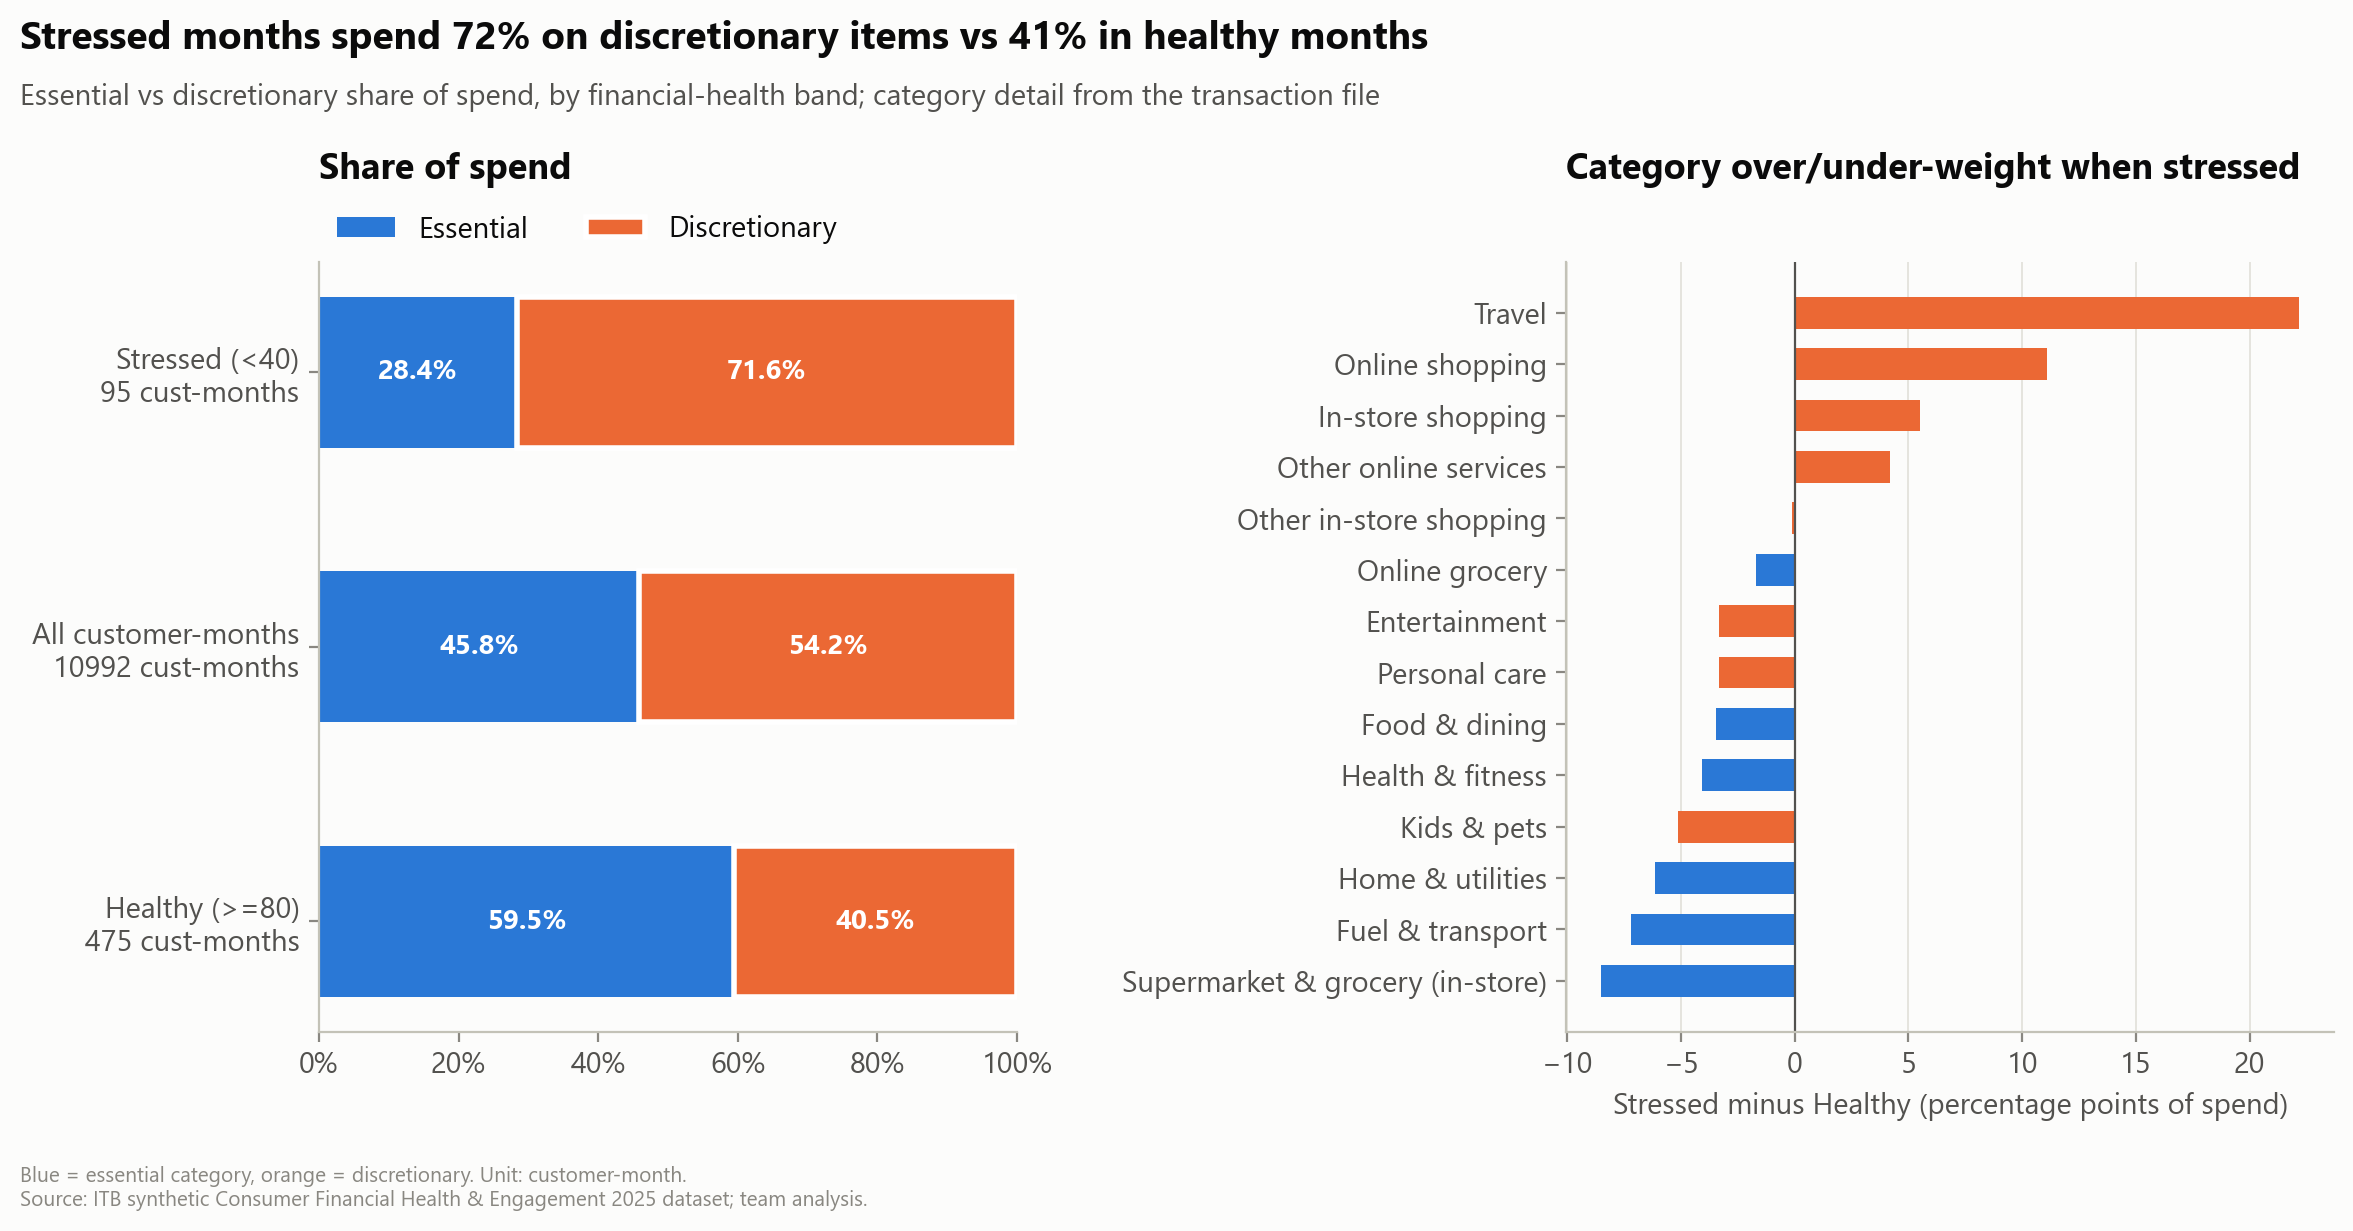

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.1], "wspace": 0.75})
ax = axes[0]
groups = ["Stressed (<40)", "All customer-months", "Healthy (>=80)"]
ess = q2.loc[groups, "essential_share_pooled"].values
y = np.arange(len(groups))[::-1]
ax.barh(y, ess, color=BLUE, height=0.55, label="Essential")
ax.barh(y, 1 - ess, left=ess, color=ORANGE, height=0.55, label="Discretionary", edgecolor="white", linewidth=2)
for yi, e in zip(y, ess):
    ax.text(e / 2, yi, pct(e), ha="center", va="center", color="white", fontsize=10, fontweight="bold")
    ax.text(e + (1 - e) / 2, yi, pct(1 - e), ha="center", va="center", color="white", fontsize=10, fontweight="bold")
ax.set_yticks(y, [f"{g}\n{q2.loc[g, 'customer_months']:.0f} cust-months" for g in groups])
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlim(0, 1); ax.grid(False)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2, borderaxespad=0.2)
ax.set_title("Share of spend", pad=30)
ax = axes[1]
c = [BLUE if e == 1 else ORANGE for e in cm.essential]
ax.barh(cm.index, cm.diff_pts, color=c, height=0.62)
ax.axvline(0, color=INK_2, lw=0.8)
ax.set_xlabel("Stressed minus Healthy (percentage points of spend)")
ax.grid(axis="y", visible=False)
ax.set_title("Category over/under-weight when stressed", pad=30)
show_chart(fig, "t1_q2_essential_mix", title=f"Stressed months spend {pct(1 - S_.essential_share_pooled, 0)} on discretionary items vs "
     f"{pct(1 - H_.essential_share_pooled, 0)} in healthy months", subtitle="Essential vs discretionary share of spend, by financial-health band; "
     "category detail from the transaction file", note="Blue = essential category, orange = discretionary. Unit: customer-month.")

**Findings - Q2 Essential vs discretionary**
- Stressed (<40): **95 customer-months (70 customers)**. Healthy (>=80): **475 customer-months (303 customers)**.
- Essential share of spend: **Stressed 28.4% vs Healthy 59.5%** (all customer-months 45.8%). Mean ratio 0.288 vs 0.611.
- Discretionary share: **Stressed 71.6% vs Healthy 40.5% (+31.1 pts)**.
- Spend-to-income is **2.10 vs 0.29**, credit utilisation **0.58 vs 0.08**, and volatility **3.02 vs 0.98**.
- Largest over-weight in stressed months: **Travel (+22.2 pts)**. Largest under-weight: **Supermarket & grocery in-store (-8.5 pts)**.
- **Interpretation:** financial stress coincides with discretionary (travel, shopping) spending crowding out essentials. The budget is being stretched by lifestyle spend, not by the cost of necessities.

### Q3 provinces: high spend, low digital share

In [ ]:
pv = t.groupby("province_city", observed=True).agg(spend=("spend_amount_vnd", "sum"), txns=("spend_amount_vnd", "size"),
                                                   digital_txn_share=("digital_flag", "mean"),
                                                   customers=("consumer_id", "nunique"))
pv["digital_spend_share"] = (t.assign(d=t.spend_amount_vnd * t.digital_flag).groupby("province_city", observed=True).d.sum()
                             / pv.spend)
chmix = pd.crosstab(t.province_city, t.transaction_channel, normalize="index")[CHANNEL_ORDER]
pv = pv.join(chmix)
pv["spend_rank"] = pv.spend.rank(ascending=False).astype(int)
nat_dig = t.digital_flag.mean()
nat_mix = t.transaction_channel.value_counts(normalize=True)[CHANNEL_ORDER]
pv["gap_pts"] = (pv.digital_txn_share - nat_dig) * 100
cust_age = m.drop_duplicates("consumer_id").groupby("province_city").age.median()
pv["median_age"] = cust_age
pv["online_ratio_mean"] = m.groupby("province_city").online_spend_ratio.mean()
pv = pv.sort_values("spend", ascending=False)
pv.to_csv(TABLES / "t1_q3_province_channel.csv")
TOPN = 10
top = pv.head(TOPN)
lag = top[top.digital_txn_share < nat_dig].sort_values("digital_txn_share")
F.add(f"\n## Q3 Provinces: high spend, low digital share\n- Digital = any non-POS channel (QR, E-commerce, Mobile App, "
      f"Recurring). National digital transaction share = {pct(nat_dig)}; POS = {pct(nat_mix['POS'])}.")
F.add(f"- Among the top {TOPN} provinces by spend ({pct(top.spend.sum() / annual)} of national spend), "
      f"{len(lag)} are below the national digital share:")
for p, r in lag.iterrows():
    F.add(f"  - {p}: rank #{r.spend_rank:.0f} spend {bn(r.spend):,.1f} bn; digital {pct(r.digital_txn_share)} "
          f"({r.gap_pts:+.1f} pts); POS {pct(r.POS)} vs {pct(nat_mix['POS'])}; QR {pct(r['QR Payment'])} vs "
          f"{pct(nat_mix['QR Payment'])}; E-com {pct(r['E-commerce'])}; App {pct(r['Mobile App'])}; "
          f"Recurring {pct(r['Recurring Payment'])}; median customer age {r.median_age:.0f}.")
assert len(lag) >= 2, "Q3 asks for at least 2 provinces"
lead = top.sort_values("digital_txn_share").iloc[-1]
F.add(f"- Best digital adopter in the top {TOPN}: {top.digital_txn_share.idxmax()} ({pct(lead.digital_txn_share)}).")
gap_tx = ((nat_dig - lag.digital_txn_share) * lag.txns).sum()
F.add(f"- Closing the gap to the national share in these provinces = {gap_tx:,.0f} transactions/year shifted from POS to digital.")
# which channels explain the gap
dch = (lag[CHANNEL_ORDER[1:]].mul(lag.txns, axis=0).sum() / lag.txns.sum() - nat_mix[CHANNEL_ORDER[1:]]) * 100
F.add("- Channel gap vs national (pts, txn-weighted across lagging provinces): "
      + ", ".join(f"{k} {v:+.1f}" for k, v in dch.items()))
best = top.digital_txn_share.max()
gap_best = ((best - lag.digital_txn_share) * lag.txns).sum()
F.add(f"- Lifting them to the best top-{TOPN} adopter ({pct(best)}) = {gap_best:,.0f} transactions/year moved to digital.")
F.add(f"- Province digital share range: {pct(pv.digital_txn_share.min())}-{pct(pv.digital_txn_share.max())} "
      f"(std {pv.digital_txn_share.std() * 100:.1f} pts) -> the geographic gap is small in absolute terms.")
F.add(f"- Correlation province median customer age vs digital share: {pv.median_age.corr(pv.digital_txn_share):.2f} "
      f"(34 provinces); median age of lagging provinces: " + ", ".join(f"{p} {pv.loc[p, 'median_age']:.0f}" for p in lag.index)
      + f" vs national {m.drop_duplicates('consumer_id').age.median():.0f}.")
cust = pd.read_parquet(TABLES.parent.parent / "data_cache" / "customer_features.parquet")
F.add(f"- Customer-level digital share std = {cust.digital_txn_share.std() * 100:.1f} pts (vs {pv.digital_txn_share.std() * 100:.1f} "
      f"between provinces) -> adoption differs far more between individuals than between regions.")
agd = cust.groupby("age_group", observed=True).digital_txn_share.mean()
agd.to_csv(TABLES / "t1_q3_digital_share_by_age.csv")
F.add("- Digital share by age group: " + ", ".join(f"{a} {pct(v)}" for a, v in agd.items()))


## Q3 Provinces: high spend, low digital share
- Digital = any non-POS channel (QR, E-commerce, Mobile App, Recurring). National digital transaction share = 41.2%; POS = 58.8%.
- Among the top 10 provinces by spend (55.0% of national spend), 4 are below the national digital share:
  - Đồng Nai: rank #3 spend 183.1 bn; digital 40.7% (-0.5 pts); POS 59.3% vs 58.8%; QR 19.8% vs 19.8%; E-com 8.5%; App 7.6%; Recurring 4.8%; median customer age 44.
  - Hưng Yên: rank #10 spend 116.4 bn; digital 40.8% (-0.4 pts); POS 59.2% vs 58.8%; QR 19.8% vs 19.8%; E-com 8.4%; App 7.4%; Recurring 5.1%; median customer age 53.
  - Hà Nội: rank #2 spend 267.3 bn; digital 40.9% (-0.3 pts); POS 59.1% vs 58.8%; QR 19.9% vs 19.8%; E-com 8.5%; App 7.6%; Recurring 4.9%; median customer age 53.
  - Lâm Đồng: rank #6 spend 135.4 bn; digital 41.1% (-0.1 pts); POS 58.9% vs 58.8%; QR 19.7% vs 19.8%; E-com 8.7%; App 7.6%; Recurring 5.1%; median customer age 49.
- Best digital adopter in the top 10: Phú Thọ (42.0%).
- C

#### 📊 Chart: `t1_q3_province_digital_gap`

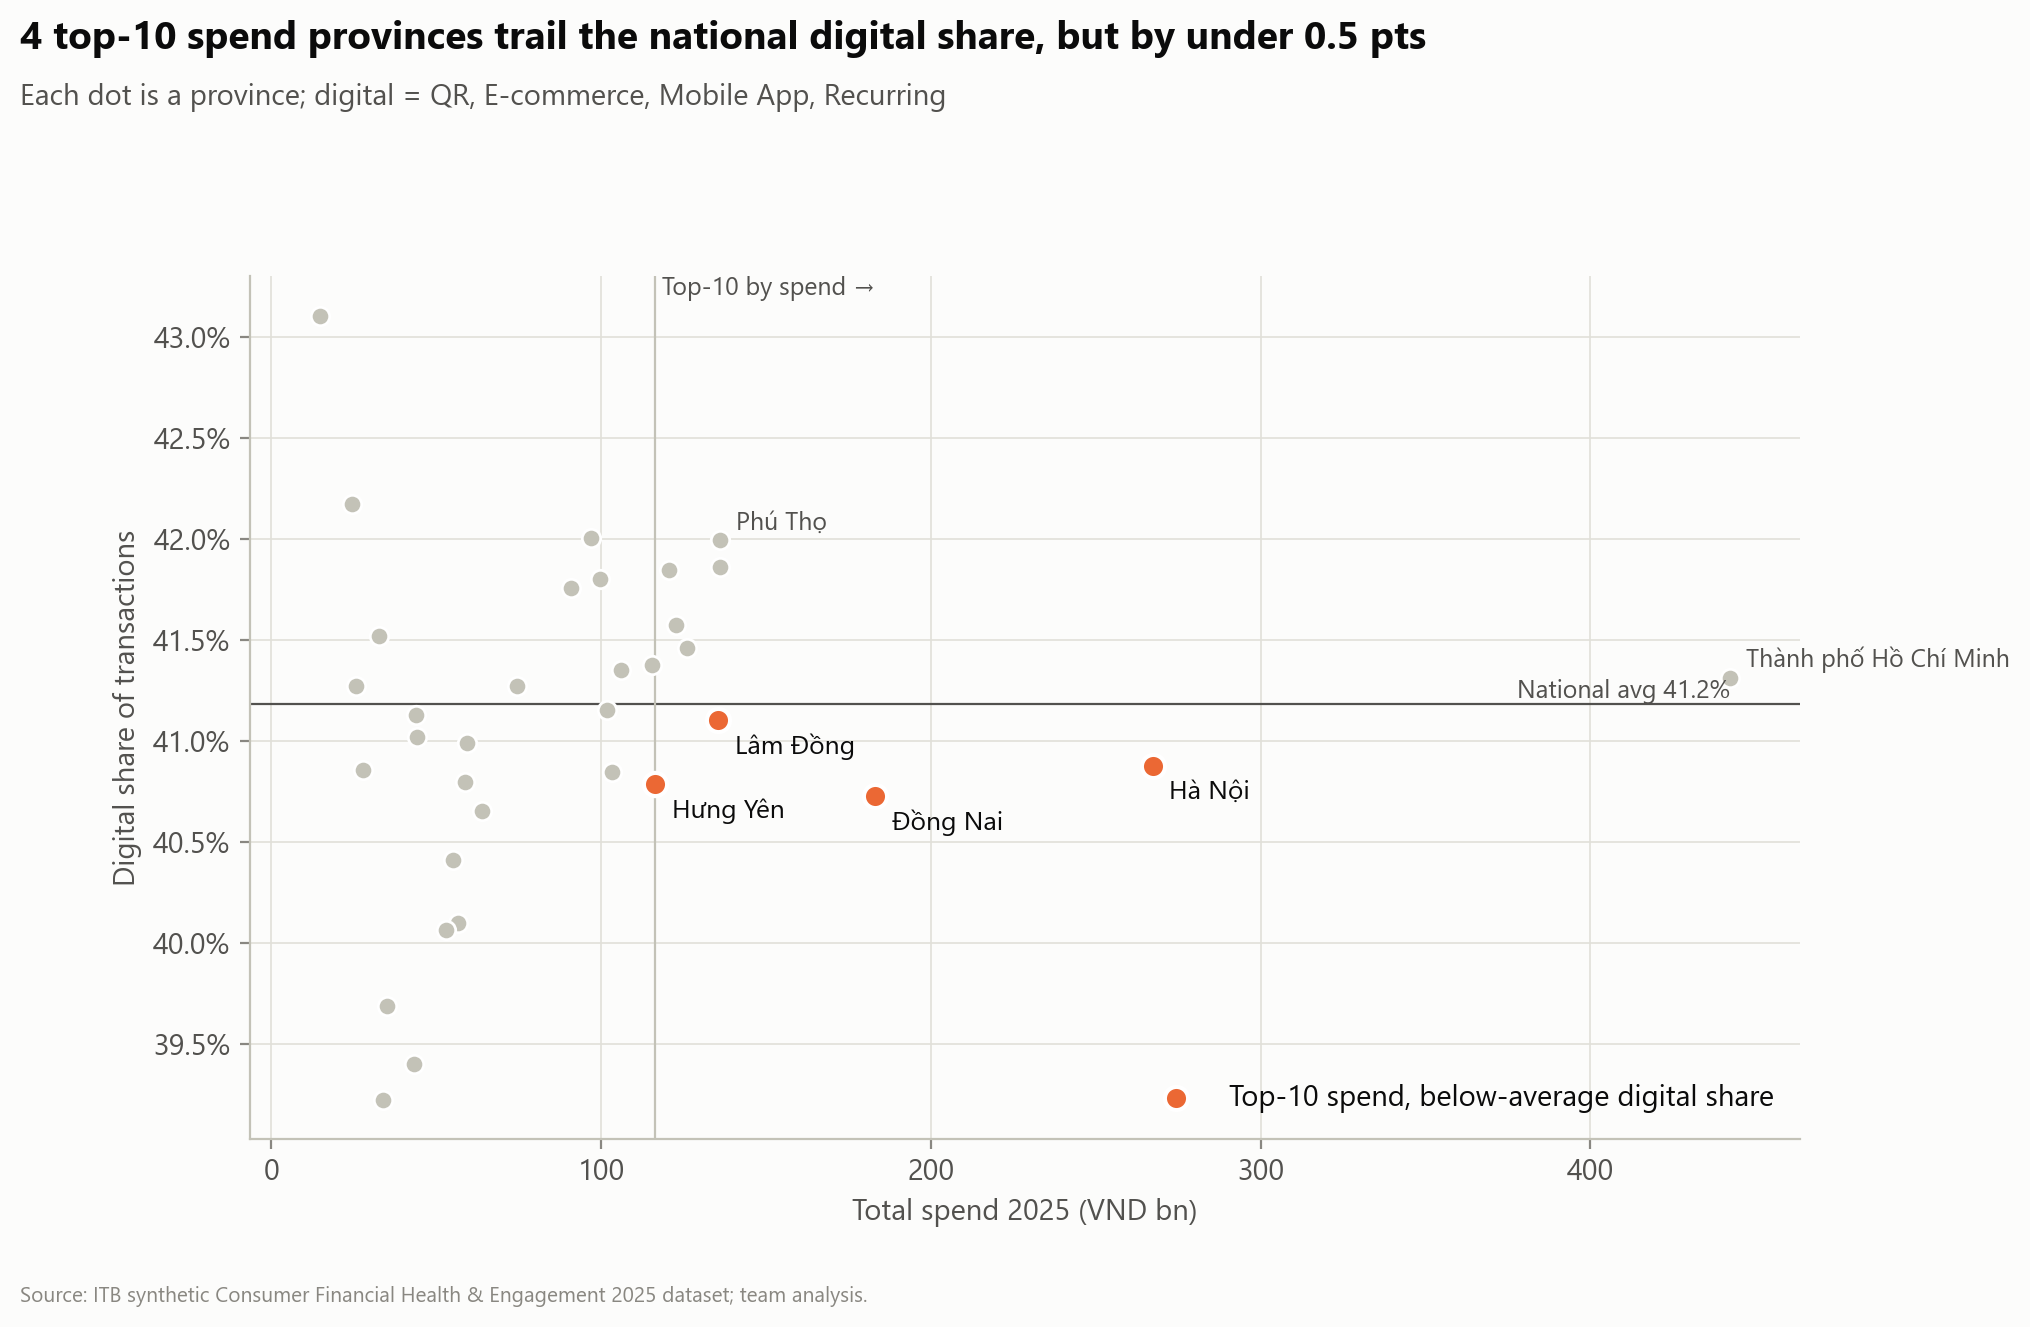

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.6))
rest_ = pv.drop(lag.index)
ax.scatter(bn(rest_.spend), rest_.digital_txn_share, s=44, color=GRAY, edgecolor="white", linewidth=1, zorder=3)
ax.scatter(bn(lag.spend), lag.digital_txn_share, s=70, color=ORANGE, edgecolor="white", linewidth=1.5, zorder=4,
           label=f"Top-{TOPN} spend, below-average digital share")
ax.axhline(nat_dig, color=INK_2, lw=0.8)
ax.text(bn(pv.spend.max()), nat_dig, f"National avg {pct(nat_dig)}", ha="right", va="bottom", fontsize=9, color=INK_2)
ax.axvline(bn(top.spend.min()), color=GRAY, lw=0.8)
ax.text(bn(top.spend.min()), ax.get_ylim()[1], f" Top-{TOPN} by spend →", va="top", fontsize=9, color=INK_2)
for p, r in lag.iterrows():
    ax.annotate(p, (bn(r.spend), r.digital_txn_share), xytext=(6, -12), textcoords="offset points", fontsize=9.5)
for p in [pv.index[0], top.digital_txn_share.idxmax()]:
    if p not in lag.index:
        r = pv.loc[p]
        ax.annotate(p, (bn(r.spend), r.digital_txn_share), xytext=(6, 4), textcoords="offset points", fontsize=9,
                    color=INK_2)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=1))
ax.set_xlabel("Total spend 2025 (VND bn)")
ax.set_ylabel("Digital share of transactions")
ax.legend(loc="lower right")
show_chart(fig, "t1_q3_province_digital_gap", title=f"{len(lag)} top-{TOPN} spend provinces trail the national digital share, but by under 0.5 pts", subtitle="Each dot is a province; digital = QR, E-commerce, Mobile App, Recurring")

**Findings - Q3 High-spend provinces with below-average digital share**
- Digital means any non-POS channel (QR, E-commerce, Mobile App, Recurring). National digital transaction share = **41.2%**; POS = 58.8%.
- The top 10 provinces by spend hold 55.0% of national spend. **4 of them are below the national digital share:**

| Province | Spend rank | Spend (bn VND) | Digital share | Gap vs national | Median customer age |
|---|---|---|---|---|---|
| Đồng Nai | #3 | 183.1 | 40.7% | -0.5 pts | 44 |
| Hưng Yên | #10 | 116.4 | 40.8% | -0.4 pts | 53 |
| Hà Nội | #2 | 267.3 | 40.9% | -0.3 pts | 53 |
| Lâm Đồng | #6 | 135.4 | 41.1% | -0.1 pts | 49 |

- Best digital adopter in the top 10: **Phú Thọ (42.0%)**.
- Province digital share only ranges **39.2%-43.1% (std 0.8 pts)**. The geographic gap is small in absolute terms.

#### 📊 Chart: `t1_q3_channel_gap`

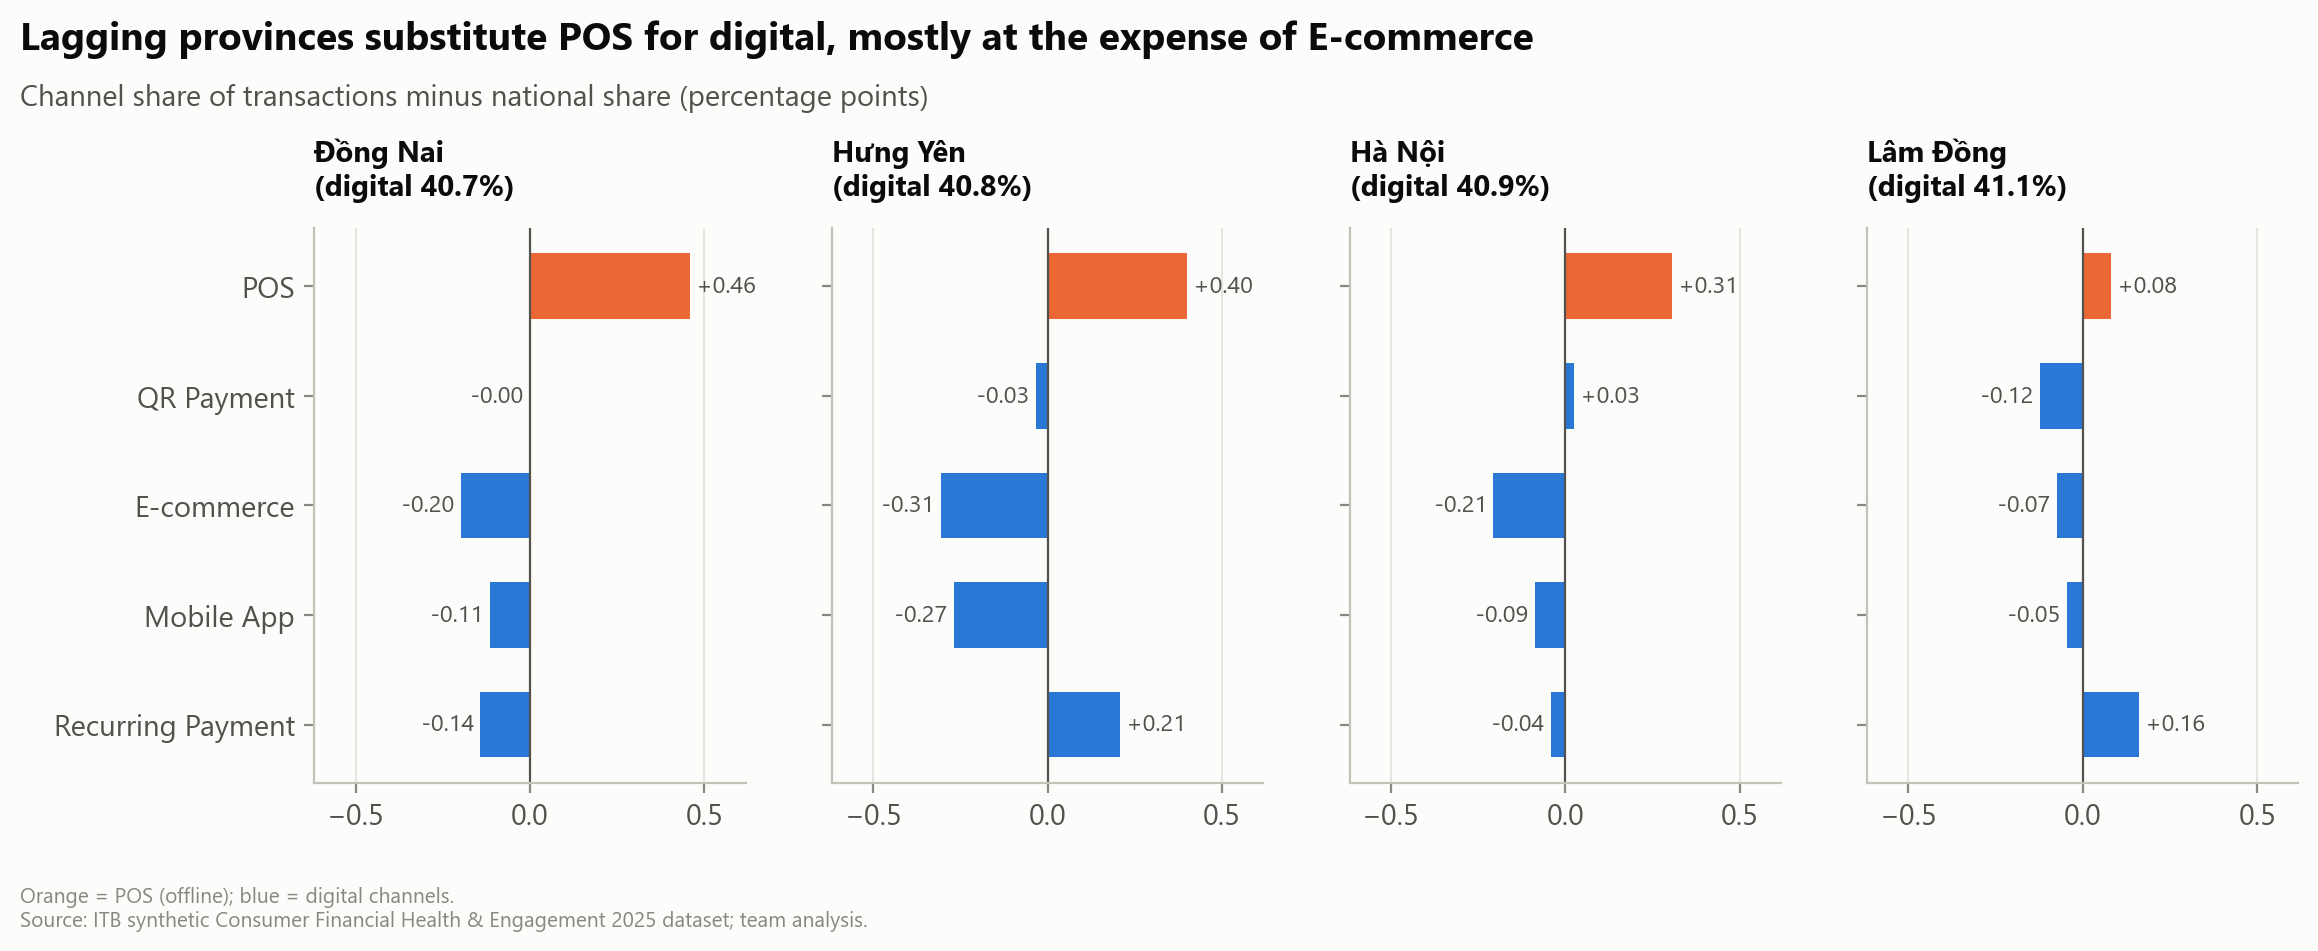

In [ ]:
# Channel gap vs national, in percentage points, one panel per lagging province (same x-scale)
gapch = (lag[CHANNEL_ORDER] - nat_mix[CHANNEL_ORDER]) * 100
gapch.to_csv(TABLES / "t1_q3_channel_gap_pts.csv")
fig, axes = plt.subplots(1, len(lag), figsize=(3.2 * len(lag), 3.6), sharey=True, sharex=True)
lim = np.abs(gapch.values).max() * 1.35
for ax, (p, r) in zip(np.atleast_1d(axes), gapch.iterrows()):
    ax.barh(CHANNEL_ORDER, r.values, color=[ORANGE if ch == "POS" else BLUE for ch in CHANNEL_ORDER], height=0.6)
    ax.axvline(0, color=INK_2, lw=0.8)
    for yi, v in enumerate(r.values):
        ax.text(v, yi, f" {v:+.2f} " if v >= 0 else f" {v:+.2f} ", ha="left" if v >= 0 else "right", va="center",
                fontsize=8.5, color=INK_2)
    ax.set_xlim(-lim, lim); ax.grid(axis="y", visible=False)
    ax.set_title(f"{p}\n(digital {pct(lag.loc[p, 'digital_txn_share'])})", fontsize=10.5)
np.atleast_1d(axes)[0].invert_yaxis()
worst_ch = dch.idxmin()
show_chart(fig, "t1_q3_channel_gap", title=f"Lagging provinces substitute POS for digital, mostly at the expense of {worst_ch}",
     subtitle="Channel share of transactions minus national share (percentage points)",
     note="Orange = POS (offline); blue = digital channels.")

**Findings - Q3 channel breakdown of the gap**
- The lagging provinces over-use POS (Đồng Nai +0.46 pts, Hưng Yên +0.40, Hà Nội +0.31, Lâm Đồng +0.08) and under-use digital channels.
- Channel gap vs national (transaction-weighted across the 4 provinces): **E-commerce -0.2 pts**, Mobile App -0.1, QR -0.0, Recurring +0.0. The shortfall sits mainly in **E-commerce**.
- Closing the gap to the national share = **1,274 transactions/year** shifted from POS to digital. Lifting the 4 provinces to Phú Thọ's level (42.0%) = **4,493 transactions/year**.

#### 📊 Chart: `t1_q3_gap_nature`

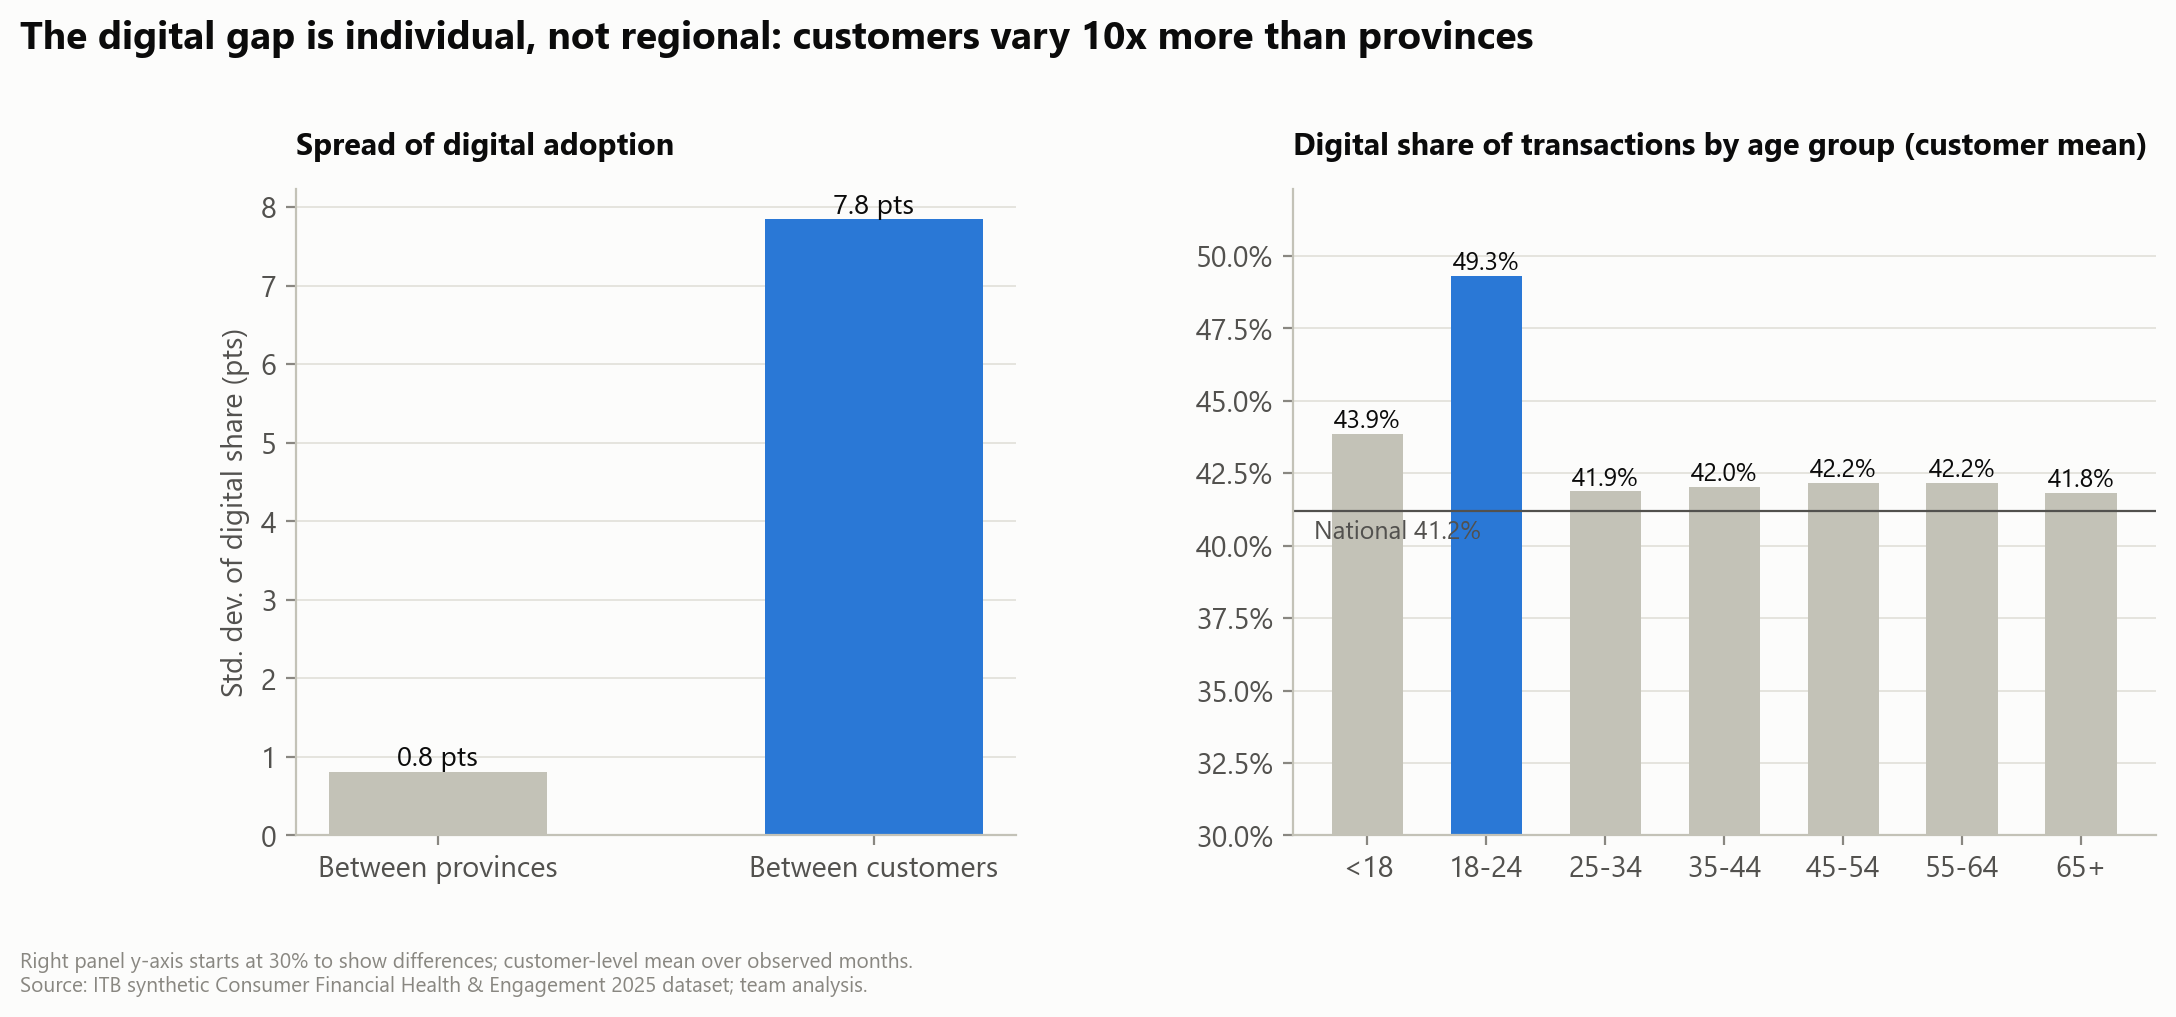

In [ ]:
# Nature of the gap: individual (age) differences dwarf regional ones
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.2], "wspace": 0.35})
ax = axes[0]
vals = [pv.digital_txn_share.std() * 100, cust.digital_txn_share.std() * 100]
ax.bar(["Between provinces", "Between customers"], vals, color=[GRAY, BLUE], width=0.5)
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:.1f} pts", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Std. dev. of digital share (pts)"); ax.grid(axis="x", visible=False)
ax.set_title("Spread of digital adoption", fontsize=11)
ax = axes[1]
ax.bar(agd.index.astype(str), agd.values, color=[BLUE if a == agd.idxmax() else GRAY for a in agd.index], width=0.6)
ax.axhline(nat_dig, color=INK_2, lw=0.8)
ax.text(-0.45, nat_dig - 0.003, f"National {pct(nat_dig)}", ha="left", va="top", fontsize=9, color=INK_2)
for i, v in enumerate(agd.values):
    ax.text(i, v, pct(v), ha="center", va="bottom", fontsize=9)
ax.set_ylim(0.3, agd.max() + 0.03)
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.grid(axis="x", visible=False)
ax.set_title("Digital share of transactions by age group (customer mean)", fontsize=11)
show_chart(fig, "t1_q3_gap_nature", title=f"The digital gap is individual, not regional: customers vary {vals[1] / vals[0]:.0f}x more than provinces",
     note="Right panel y-axis starts at 30% to show differences; customer-level mean over observed months.")

**Findings - Q3 nature of the digital adoption gap**
- Customer-level digital share std = **7.8 pts vs 0.8 pts between provinces**. Adoption differs about **10x more between individuals than between regions**.
- Province median customer age vs digital share: correlation **-0.51** across 34 provinces. Hà Nội and Hưng Yên have the oldest customer base (median 53 vs national 49).
- Digital share by age group: <18 43.9%, **18-24 49.3%**, 25-34 41.9%, 35-44 42.0%, 45-54 42.2%, 55-64 42.2%, 65+ 41.8%.
- **Interpretation:** the gap is a *customer-behaviour* gap (age and habit), not an infrastructure or regional one. Digital nudges should target individuals, not provinces.

### Q4 top category by count vs by spend

In [ ]:
cat = t.groupby("category_en", observed=True).agg(txns=("spend_amount_vnd", "size"), spend=("spend_amount_vnd", "sum"),
                                                  median_ticket=("spend_amount_vnd", "median"),
                                                  customers=("consumer_id", "nunique"))
cat["avg_ticket"] = cat.spend / cat.txns
cat["txn_share"] = cat.txns / cat.txns.sum()
cat["spend_share"] = cat.spend / cat.spend.sum()
cat["txn_per_customer_month"] = cat.txns / m.shape[0]
cat["digital_share"] = t.groupby("category_en", observed=True).digital_flag.mean()
cat = cat.sort_values("txns", ascending=False)
cat.to_csv(TABLES / "t1_q4_category.csv")
c_n, c_s = cat.txns.idxmax(), cat.spend.idxmax()
A, B = cat.loc[c_n], cat.loc[c_s]
F.add(f"\n## Q4 Top category by count vs by spend\n- By count: {c_n} = {A.txns:,.0f} txns ({pct(A.txn_share)}), "
      f"spend {bn(A.spend):,.1f} bn ({pct(A.spend_share)}), avg ticket {A.avg_ticket:,.0f} VND (median {A.median_ticket:,.0f}).")
F.add(f"- By spend: {c_s} = {bn(B.spend):,.1f} bn ({pct(B.spend_share)}), {B.txns:,.0f} txns ({pct(B.txn_share)}), "
      f"avg ticket {B.avg_ticket:,.0f} VND (median {B.median_ticket:,.0f}).")
F.add(f"- Ticket ratio {c_s} / {c_n} = {B.avg_ticket / A.avg_ticket:.2f}x; overall avg ticket "
      f"{annual / len(t):,.0f} VND.")
F.add(f"- Frequency: {c_n} {A.txn_per_customer_month:.1f} txns per customer-month vs {c_s} {B.txn_per_customer_month:.1f}.")
for c_ in (c_n, c_s):
    sub = t[t.category_en == c_]
    h = sub.groupby("transaction_hour").size(); d = sub.groupby("transaction_day_of_week").size()
    F.add(f"- {c_}: digital share {pct(cat.loc[c_, 'digital_share'])}; share of txns 00-11h {pct(h.loc[0:11].sum() / h.sum())} "
          f"(synthetic artefact: categories are generated in fixed half-day windows, not interpretable as real timing); weekend share "
          f"{pct(d.loc[[5, 6]].sum() / d.sum())}; top channel {sub.transaction_channel.value_counts(normalize=True).idxmax()} "
          f"({pct(sub.transaction_channel.value_counts(normalize=True).max())}).")


## Q4 Top category by count vs by spend
- By count: Fuel & transport = 188,029 txns (10.2%), spend 298.4 bn (9.2%), avg ticket 1,586,933 VND (median 1,572,000).
- By spend: Supermarket & grocery (in-store) = 513.8 bn (15.8%), 176,191 txns (9.5%), avg ticket 2,916,003 VND (median 2,626,000).
- Ticket ratio Supermarket & grocery (in-store) / Fuel & transport = 1.84x; overall avg ticket 1,751,589 VND.
- Frequency: Fuel & transport 17.1 txns per customer-month vs Supermarket & grocery (in-store) 16.0.
- Fuel & transport: digital share 30.2%; share of txns 00-11h 100.0% (synthetic artefact: categories are generated in fixed half-day windows, not interpretable as real timing); weekend share 33.2%; top channel POS (69.8%).
- Supermarket & grocery (in-store): digital share 24.9%; share of txns 00-11h 98.0% (synthetic artefact: categories are generated in fixed half-day windows, not interpretable as real timing); weekend share 32.4%; top channel POS (75.1%).


#### 📊 Chart: `t1_q4_category_count_vs_spend`

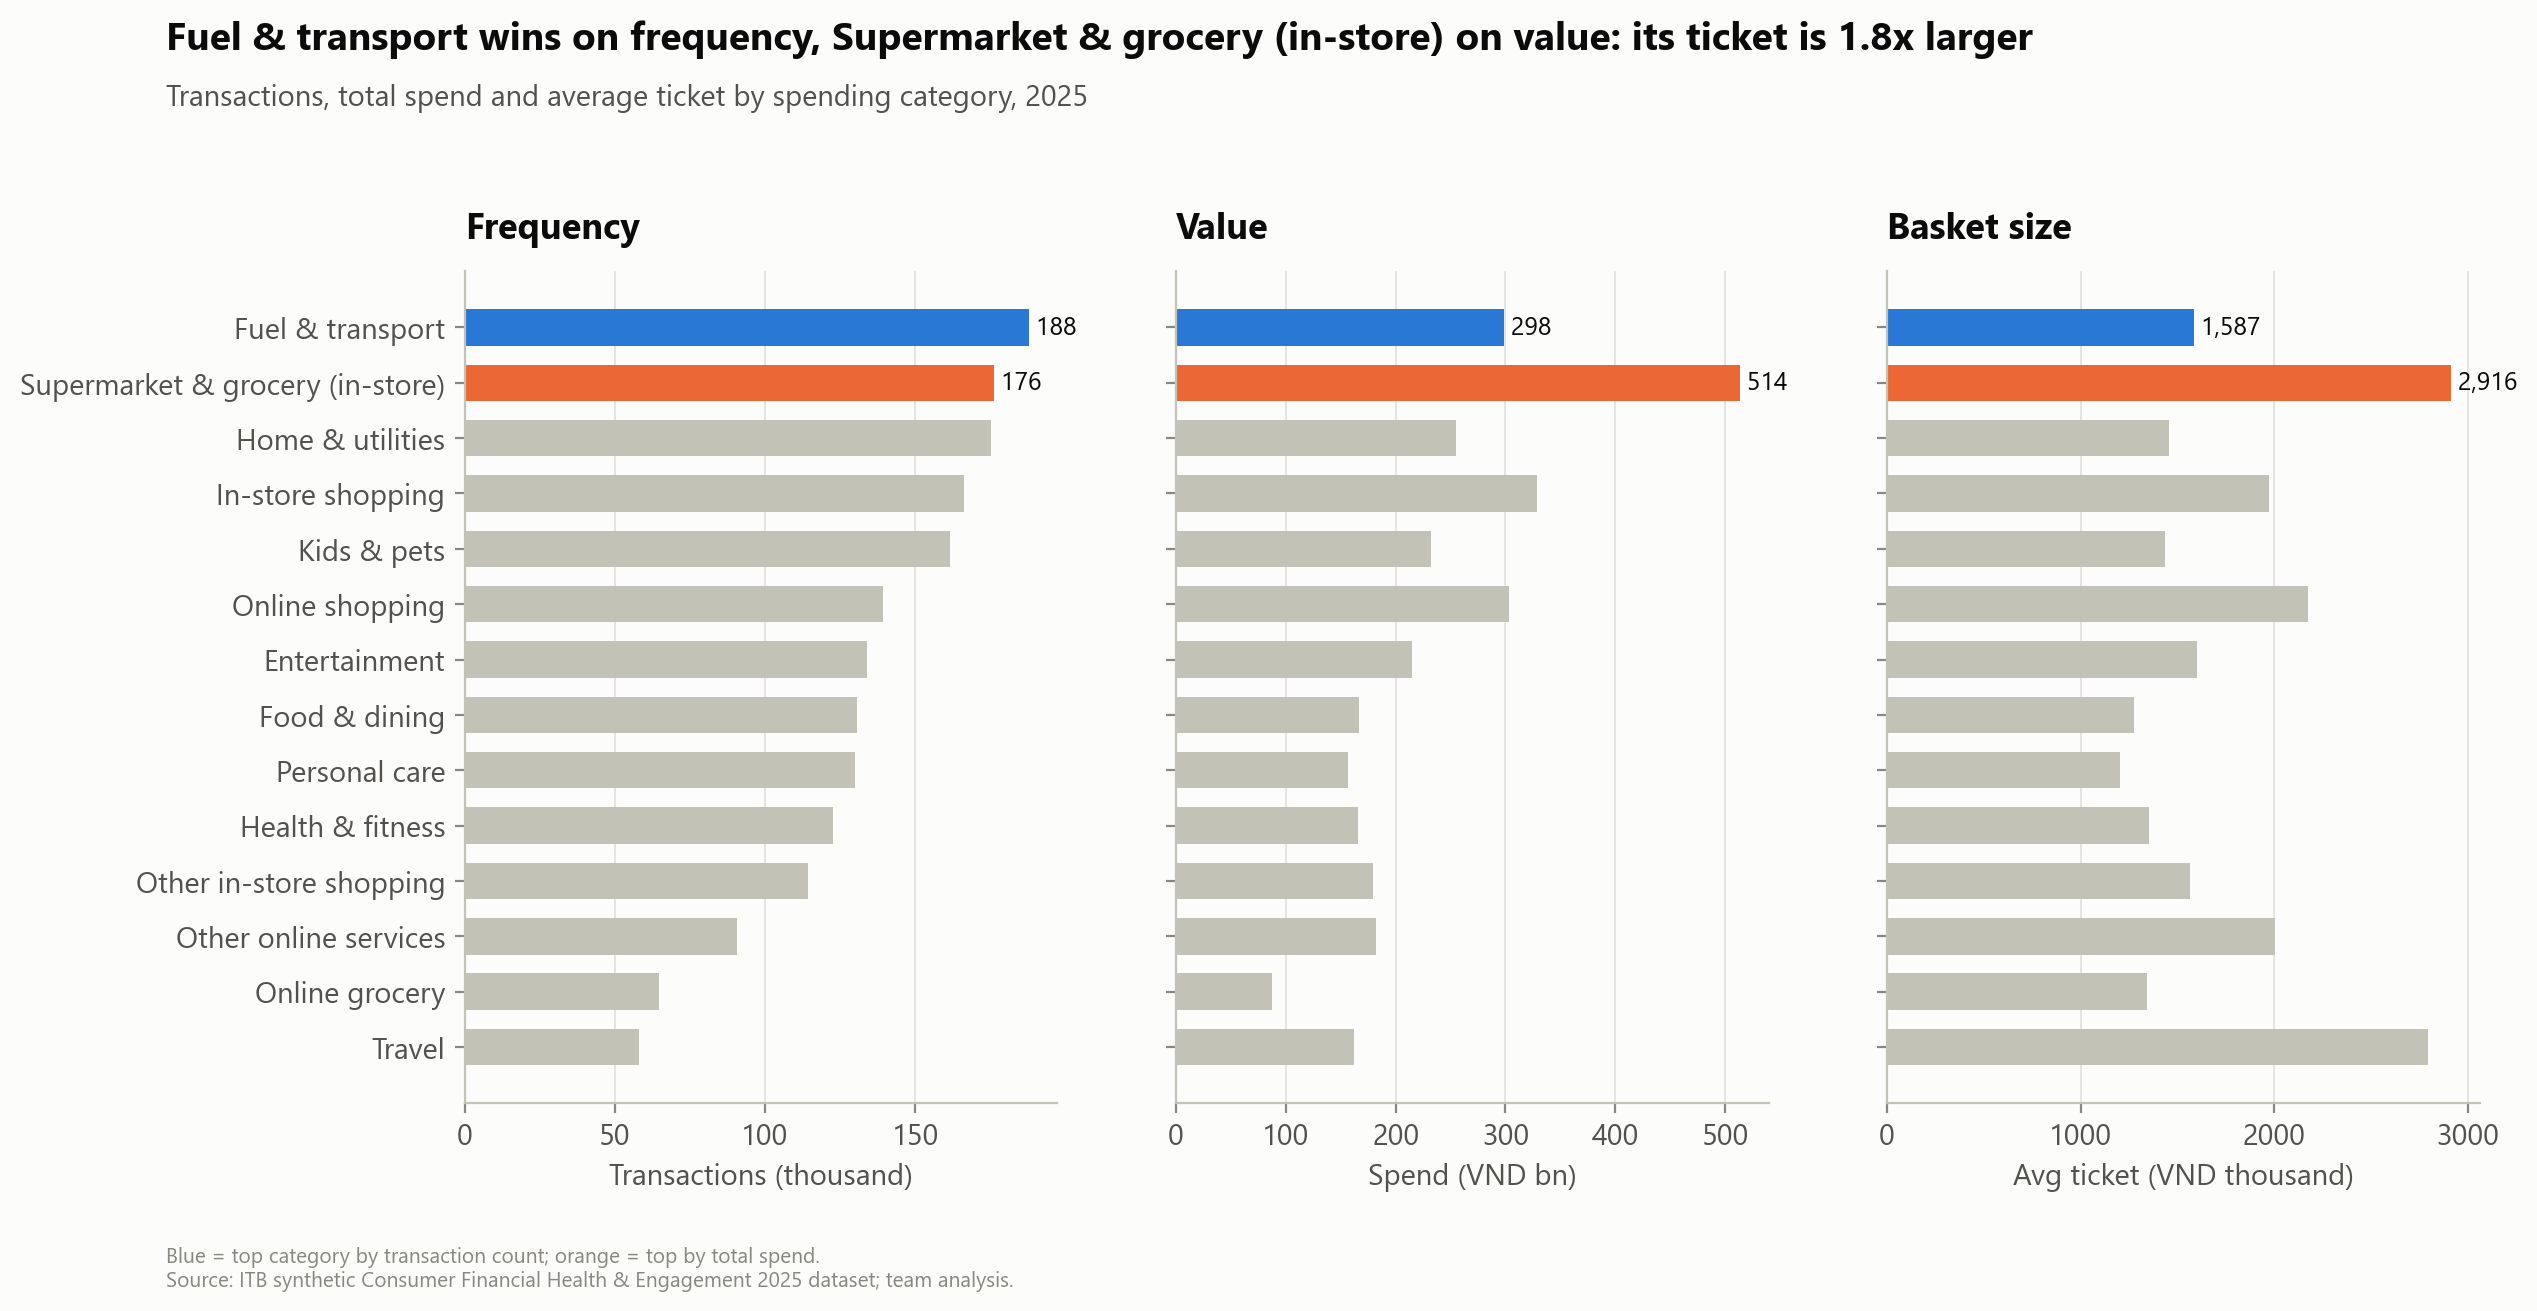

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5.4), sharey=True)
order = cat.sort_values("txns").index
hl = lambda idx: [BLUE if i == c_n else (ORANGE if i == c_s else GRAY) for i in idx]
for ax, col, lab, fmt in [(axes[0], "txns", "Transactions (thousand)", lambda v: v / 1e3),
                          (axes[1], "spend", "Spend (VND bn)", bn),
                          (axes[2], "avg_ticket", "Avg ticket (VND thousand)", lambda v: v / 1e3)]:
    vals = fmt(cat.loc[order, col])
    ax.barh(order, vals, color=hl(order), height=0.66)
    ax.set_xlabel(lab); ax.grid(axis="y", visible=False)
    for c_ in (c_n, c_s):
        ax.text(vals[c_], list(order).index(c_), f" {vals[c_]:,.0f}", va="center", fontsize=9)
axes[0].set_title("Frequency"); axes[1].set_title("Value"); axes[2].set_title("Basket size")
show_chart(fig, "t1_q4_category_count_vs_spend", title=f"{c_n} wins on frequency, {c_s} on value: its ticket is {B.avg_ticket / A.avg_ticket:.1f}x larger",
     subtitle="Transactions, total spend and average ticket by spending category, 2025", note="Blue = top category by transaction count; orange = top by total spend.")

**Findings - Q4 Top category by count vs by spend**
- **By transaction count: Fuel & transport** = 188,029 txns (10.2%), spend 298.4 bn (9.2%), avg ticket **1,586,933 VND** (median 1,572,000).
- **By total spend: Supermarket & grocery (in-store)** = 513.8 bn (15.8%), 176,191 txns (9.5%), avg ticket **2,916,003 VND** (median 2,626,000).
- The supermarket ticket is **1.84x** the fuel ticket; the overall average ticket is 1,751,589 VND.
- Frequency: Fuel & transport 17.1 txns per customer-month vs Supermarket 16.0.
- Channels: both are POS-led (Fuel 69.8% POS, digital 30.2%; Supermarket 75.1% POS, digital 24.9%). Weekend share is 33.2% vs 32.4%.
- **Interpretation:** fuel/transport is a *habitual, small-ticket, high-frequency* purchase, while groceries are *planned, larger basket* purchases. Frequency drives engagement; basket size drives value.
- *Data note:* transaction hours by category follow fixed half-day windows in this synthetic data (Fuel 100% at 00-11h), so time-of-day is not interpreted.

### Q5 age cohorts

In [ ]:
ag = m.groupby("age_group", observed=True).agg(customers=("consumer_id", "nunique"), cm_rows=("consumer_id", "size"),
                                                txn_count=("transaction_count", "mean"),
                                                active_days=("active_transaction_days", "mean"),
                                                health=("financial_health_score", "mean"),
                                                essential_ratio=("essential_spend_ratio", "mean"),
                                                spend_to_income=("spend_to_income_ratio", "mean"),
                                                credit_util=("credit_utilization_ratio", "mean"),
                                                volatility=("spending_volatility", "mean"),
                                                online_ratio=("online_spend_ratio", "mean"),
                                                low_health_rate=("financial_health_score", lambda s: (s < 60).mean()))
ag.to_csv(TABLES / "t1_q5_age_cohorts.csv")
avg_txn = m.transaction_count.mean()
freq = ag[ag.txn_count > avg_txn]
worst = freq.health.idxmin()
W = ag.loc[worst]; others = m[m.age_group != worst]
F.add(f"\n## Q5 Age cohorts\n- Average transactions per customer-month (all) = {avg_txn:.1f}. Cohorts above it: "
      + ", ".join(f"{i} ({r.txn_count:.0f})" for i, r in freq.iterrows()))
F.add(f"- Among frequent cohorts, lowest avg health: {worst} = {W.health:.1f} (all others {others.financial_health_score.mean():.1f}); "
      f"{W.customers:.0f} customers, {W.txn_count:.0f} txns/month, {W.active_days:.1f} active days.")
F.add(f"- {worst}: essential ratio {W.essential_ratio:.3f} vs others {others.essential_spend_ratio.mean():.3f}; spend-to-income "
      f"{W.spend_to_income:.2f} vs {others.spend_to_income_ratio.mean():.2f}; credit util {W.credit_util:.2f} vs "
      f"{others.credit_utilization_ratio.mean():.2f}; volatility {W.volatility:.2f} vs {others.spending_volatility.mean():.2f}; "
      f"share of months <60 health {pct(W.low_health_rate)} vs {pct((others.financial_health_score < 60).mean())}.")
F.add(f"- Lowest health overall: {ag.health.idxmin()} ({ag.health.min():.1f}); highest: {ag.health.idxmax()} ({ag.health.max():.1f}); "
      f"cohort range only {ag.health.max() - ag.health.min():.1f} pts -> age is a weak driver on its own.")
F.add(f"- {worst} rank on spend-to-income: #{int(ag.spend_to_income.rank(ascending=False)[worst])} of {len(ag)}; "
      f"essential ratio vs 45+ cohorts: {W.essential_ratio:.3f} vs {m[m.age >= 45].essential_spend_ratio.mean():.3f}. "
      f"Note <18 cohort has only {ag.loc['<18', 'customers']:.0f} customers.")


## Q5 Age cohorts
- Average transactions per customer-month (all) = 168.5. Cohorts above it: <18 (235), 18-24 (220), 25-34 (179), 35-44 (199), 45-54 (177)
- Among frequent cohorts, lowest avg health: 25-34 = 65.8 (all others 66.5); 177 customers, 179 txns/month, 28.9 active days.
- 25-34: essential ratio 0.468 vs others 0.484; spend-to-income 0.72 vs 0.70; credit util 0.19 vs 0.19; volatility 1.59 vs 1.56; share of months <60 health 24.5% vs 22.9%.
- Lowest health overall: 25-34 (65.8); highest: 55-64 (67.0); cohort range only 1.2 pts -> age is a weak driver on its own.
- 25-34 rank on spend-to-income: #1 of 7; essential ratio vs 45+ cohorts: 0.468 vs 0.503. Note <18 cohort has only 7 customers.


#### 📊 Chart: `t1_q5_age_cohorts`

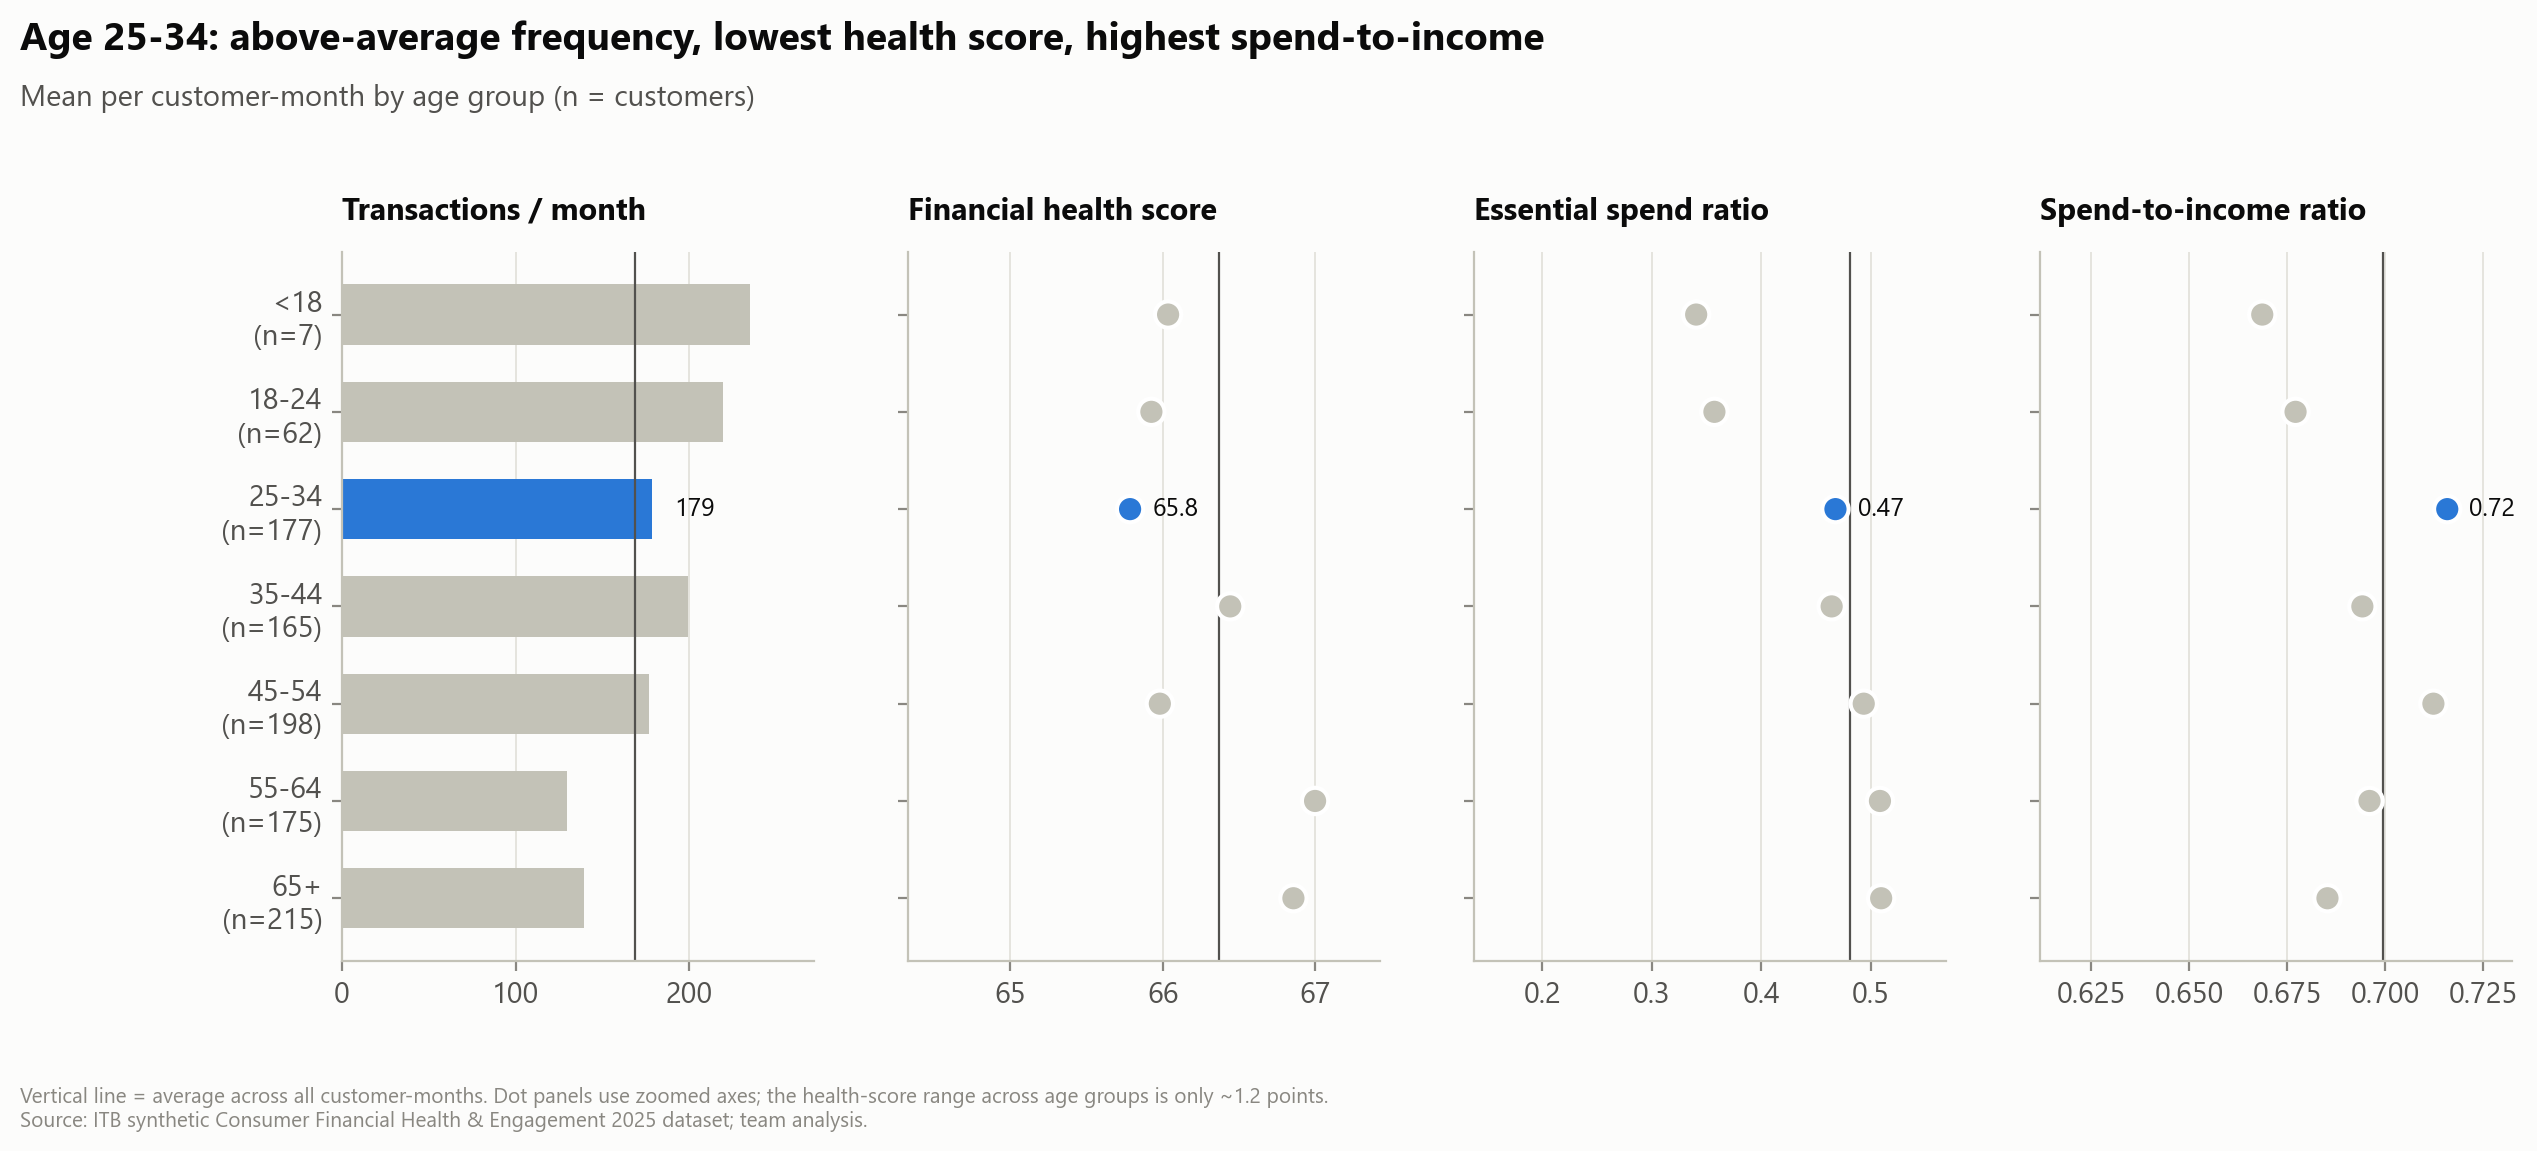

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4.6), sharey=True)
panels = [("txn_count", "Transactions / month", avg_txn, "{:.0f}"), ("health", "Financial health score",
          m.financial_health_score.mean(), "{:.1f}"), ("essential_ratio", "Essential spend ratio",
          m.essential_spend_ratio.mean(), "{:.2f}"), ("spend_to_income", "Spend-to-income ratio",
          m.spend_to_income_ratio.mean(), "{:.2f}")]
ylab = [f"{a}\n(n={ag.loc[a, 'customers']:.0f})" for a in ag.index]
for ax, (col, lab, ref, fmtstr) in zip(axes, panels):
    vals = ag[col]
    cols_ = [BLUE if a == worst else GRAY for a in ag.index]
    if col == "txn_count":   # bars only where the axis starts at zero
        ax.barh(ylab, vals, color=cols_, height=0.62)
    else:                    # zoomed axis -> dots, so length is not read as magnitude
        ax.scatter(vals, ylab, color=cols_, s=90, zorder=3, edgecolor="white", linewidth=1.5)
    ax.axvline(ref, color=INK_2, lw=0.8)
    ax.set_title(lab, fontsize=11)
    ax.grid(axis="y", visible=False)
    ax.annotate(fmtstr.format(vals[worst]), (vals[worst], list(ag.index).index(worst)), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=9)
    lo_, hi_ = vals.min(), vals.max()
    ax.set_xlim(max(0, lo_ - (hi_ - lo_) * 1.2) if col != "txn_count" else 0, hi_ + (hi_ - lo_) * 0.35)
axes[0].invert_yaxis()
show_chart(fig, "t1_q5_age_cohorts", title=f"Age {worst}: above-average frequency, lowest health score, highest spend-to-income",
     subtitle="Mean per customer-month by age group (n = customers)", note="Vertical line = average across all customer-months. Dot panels use zoomed axes; "
                                   "the health-score range across age groups is only ~1.2 points.")

**Findings - Q5 Age cohorts**
- Average transactions per customer-month = **168.5**. Cohorts above it: <18 (235), 18-24 (220), 25-34 (179), 35-44 (199), 45-54 (177).
- Among these frequent cohorts, the lowest average health is **25-34 = 65.8** (all others 66.5), with 177 customers, 179 txns/month and 28.9 active days.
- 25-34 vs others: spend-to-income **0.72 vs 0.70 (highest of all 7 cohorts)**; essential ratio **0.468 vs 0.484** (vs 0.503 for 45+); share of months with health <60 **24.5% vs 22.9%**; volatility 1.59 vs 1.56.
- **Interpretation:** young working adults transact often and spend a larger share of income, with a less essential-heavy mix. This is consistent with lifestyle-driven budget pressure.
- *Caveat:* the health range across age cohorts is only **1.2 pts**, so age is a weak driver on its own (see Task 2). The <18 cohort has only 7 customers.

## 3. Task 2 - Financial health analysis

Primary source: consumer-month file (ratio fields only when comparing customers).
Transaction file is used to go deeper on the "financially stressed but highly engaged" group.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter
from scipy.stats import kruskal
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

style()
F = Findings("task2")
m, c = load_cm(), load_cust()
F.add("# Task 2 findings - Financial health")

# Task 2 findings - Financial health


### 1. Distribution

In [ ]:
s = m.financial_health_score
seg = m.health_seg.value_counts().reindex(HEALTH_ORDER)
F.add(f"\n## 1. Distribution\n- Customer-months: {len(m):,}; mean {s.mean():.1f}, median {s.median():.1f}, std {s.std():.1f}, "
      f"P10 {s.quantile(.1):.1f}, P90 {s.quantile(.9):.1f}, min {s.min():.1f}, max {s.max():.1f}; skew {s.skew():.2f}.")
F.add("- Bands (customer-months): " + ", ".join(f"{k} {v:,} ({pct(v / len(m))})" for k, v in seg.items()))
cs = c.financial_health_score
F.add(f"- Customer level (mean over observed months, n={len(c)}): mean {cs.mean():.1f}, std {cs.std():.1f}, "
      f"range {cs.min():.1f}-{cs.max():.1f}. Month-to-month variation is larger than between-customer variation: "
      f"avg within-customer std {m.groupby('consumer_id').financial_health_score.std().mean():.1f} pts.")
F.add(f"- Customers with >=1 month below 60: {(c.low_health_months > 0).sum()} ({pct((c.low_health_months > 0).mean())}); "
      f">=1 month below 40: {(c.stressed_months > 0).sum()} ({pct((c.stressed_months > 0).mean())}); "
      f">=1 month at 80+: {(c.healthy_months > 0).sum()} ({pct((c.healthy_months > 0).mean())}).")
mh = m.groupby(m.analysis_month.dt.month).agg(score=("financial_health_score", "mean"),
                                               low=("financial_health_score", lambda x: (x < 60).mean()))
mh.to_csv(TABLES / "t2_monthly_health.csv")
F.add(f"- By month: lowest mean score {MONTHS[mh.score.idxmin() - 1]} ({mh.score.min():.1f}, {pct(mh.low.max())} of customers <60); "
      f"highest {MONTHS[mh.score.idxmax() - 1]} ({mh.score.max():.1f}).")


## 1. Distribution
- Customer-months: 10,992; mean 66.4, median 67.7, std 9.5, P10 53.2, P90 77.2, min 0.8, max 90.2; skew -0.92.
- Bands (customer-months): Stressed 95 (0.9%), Watch 2,457 (22.4%), Stable 7,965 (72.5%), Healthy 475 (4.3%)
- Customer level (mean over observed months, n=999): mean 66.3, std 4.7, range 42.3-80.8. Month-to-month variation is larger than between-customer variation: avg within-customer std 8.4 pts.
- Customers with >=1 month below 60: 869 (87.0%); >=1 month below 40: 70 (7.0%); >=1 month at 80+: 303 (30.3%).
- By month: lowest mean score Dec (54.2, 84.1% of customers <60); highest Feb (73.6).


#### 📊 Chart: `t2_health_distribution`

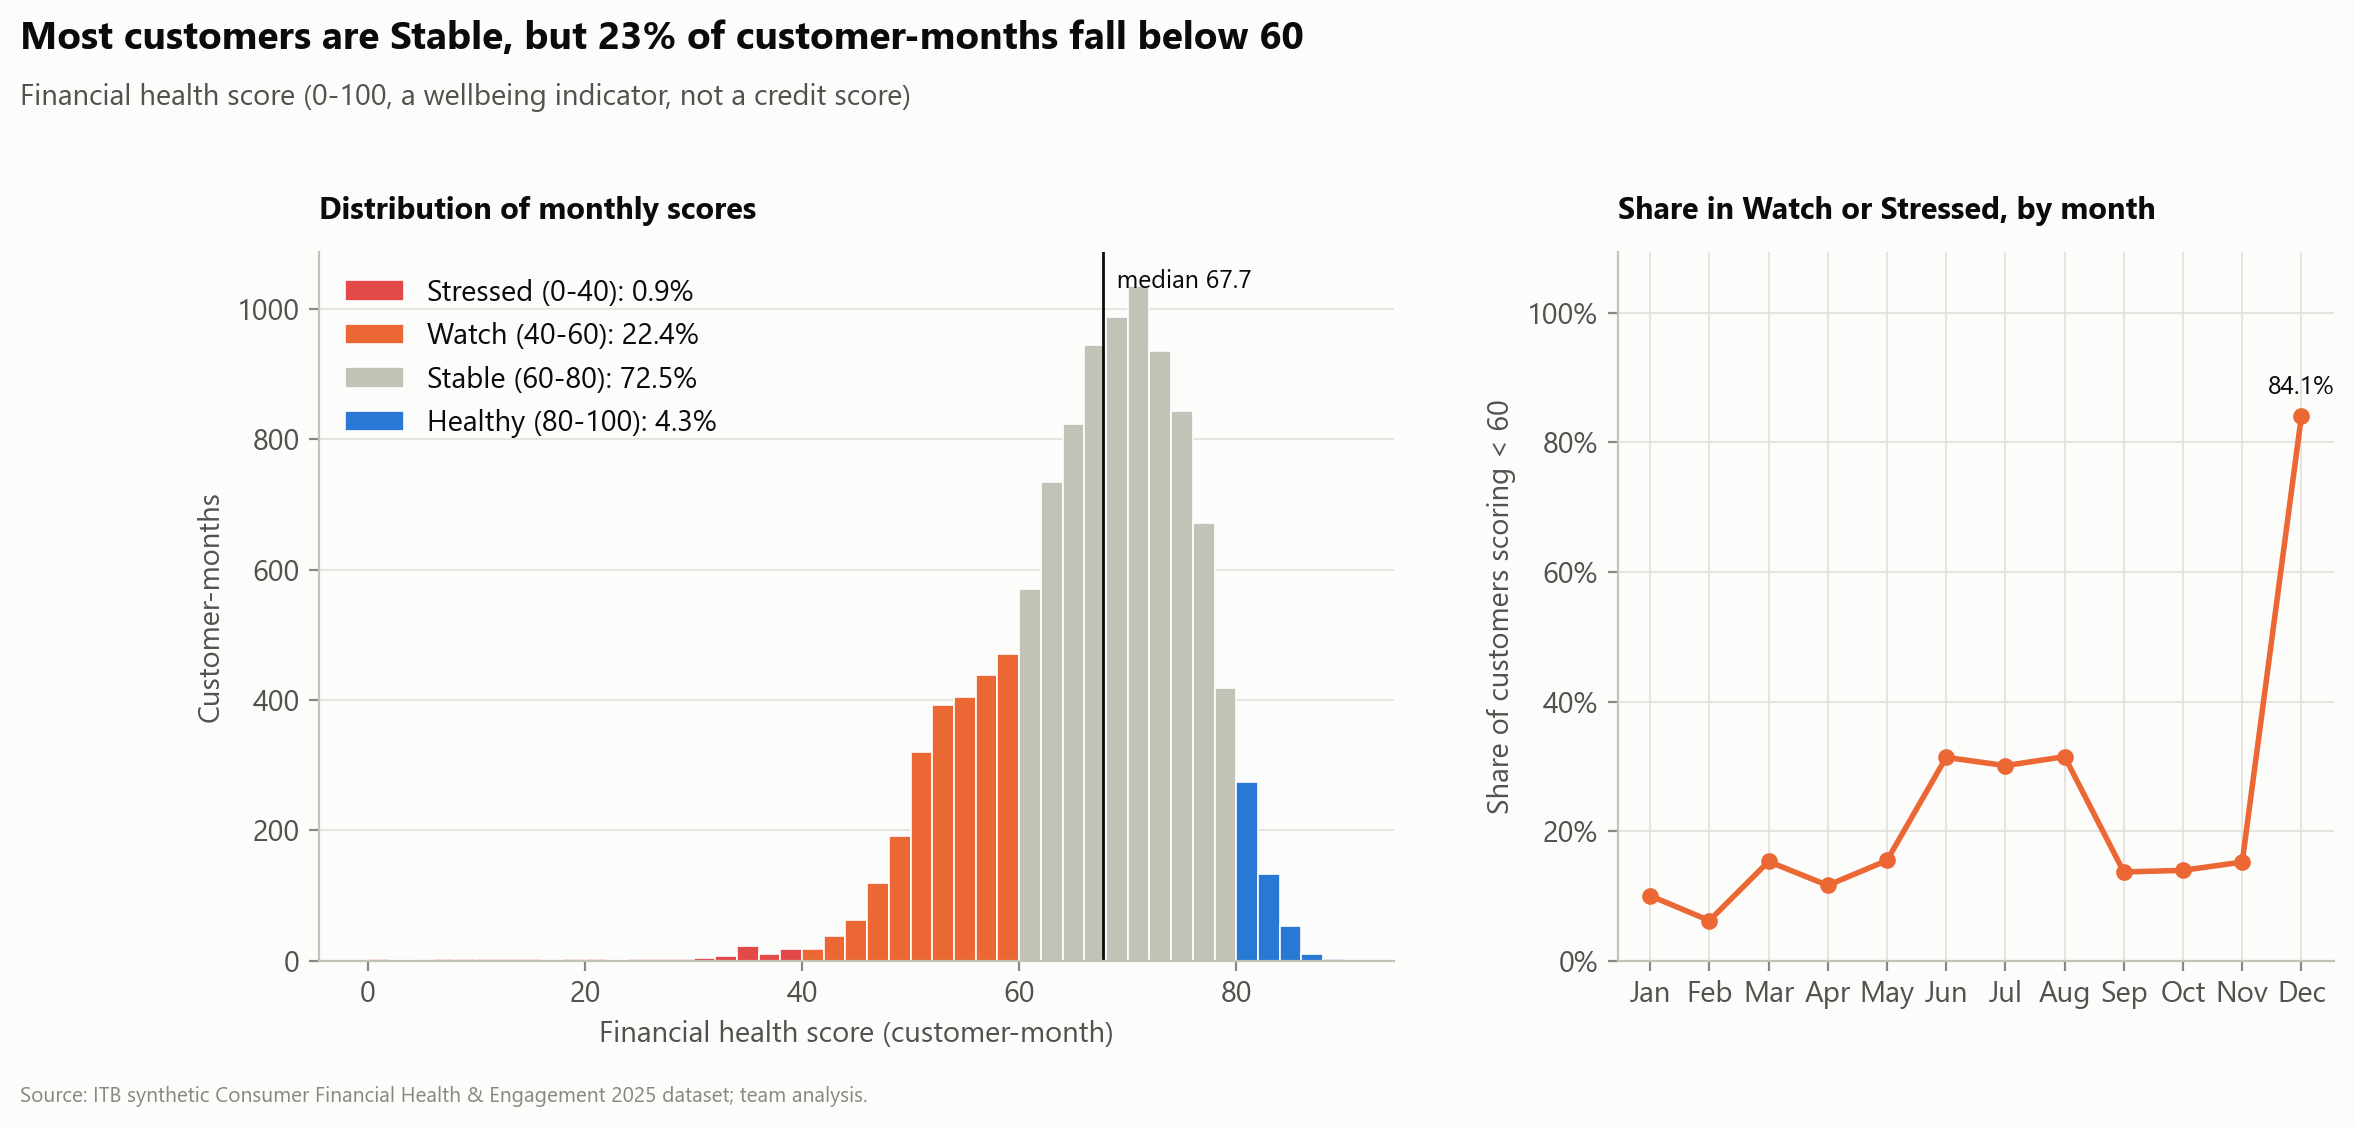

In [ ]:
band_col = {"Stressed": RED, "Watch": ORANGE, "Stable": GRAY, "Healthy": BLUE}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.5, 1], "wspace": 0.25})
ax = axes[0]
bins = np.arange(0, 92, 2)
for lo_, hi_, name in [(0, 40, "Stressed"), (40, 60, "Watch"), (60, 80, "Stable"), (80, 100, "Healthy")]:
    ax.hist(s[(s >= lo_) & (s < hi_)], bins=bins, color=band_col[name], edgecolor="white", linewidth=0.6,
            label=f"{name} ({lo_}-{hi_}): {pct(seg[name] / len(m))}")
ax.axvline(s.median(), color=INK, lw=1)
ax.text(s.median(), ax.get_ylim()[1] * 0.95, f"  median {s.median():.1f}", fontsize=9, color=INK)
ax.set_xlabel("Financial health score (customer-month)"); ax.set_ylabel("Customer-months")
ax.legend(loc="upper left"); ax.grid(axis="x", visible=False)
ax.set_title("Distribution of monthly scores", fontsize=11)
ax = axes[1]
ax.plot(MONTHS, mh.low, color=ORANGE, marker="o", ms=5)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylim(0, mh.low.max() * 1.3)
ax.set_ylabel("Share of customers scoring < 60")
ax.set_title("Share in Watch or Stressed, by month", fontsize=11)
ax.annotate(pct(mh.low.max()), (mh.low.idxmax() - 1, mh.low.max()), xytext=(0, 8), textcoords="offset points",
            ha="center", fontsize=9)
show_chart(fig, "t2_health_distribution",
     title=f"Most customers are Stable, but {pct(seg[['Stressed', 'Watch']].sum() / len(m), 0)} of customer-months fall below 60",
     subtitle="Financial health score (0-100, a wellbeing indicator, not a credit score)")

**Findings - Distribution of financial_health_score**
- Customer-months: 10,992. Mean **66.4**, median **67.7**, std 9.5, P10 53.2, P90 77.2, min 0.8, max 90.2. Left-skewed (skew -0.92).
- Bands: **Stressed 95 (0.9%)**, **Watch 2,457 (22.4%)**, **Stable 7,965 (72.5%)**, **Healthy 475 (4.3%)**.
- Customer level (mean over observed months, n=999): mean 66.3, std 4.7, range 42.3-80.8. Month-to-month swings are larger than differences between customers (average within-customer std **8.4 pts**).
- **87.0%** of customers (869) have at least one month below 60, **7.0%** (70) at least one month below 40, and **30.3%** (303) at least one month at 80+.
- By month: **December is the worst month (mean 54.2; 84.1% of customers below 60)**, and February the best (73.6). The December spending peak (Task 1 Q1) directly erodes financial health.

### 2. Drivers of low health

In [ ]:
drivers = {"spend_to_income_ratio": "Spend-to-income", "credit_utilization_ratio": "Credit utilisation",
           "balance_change_ratio": "Net balance change / income", "spending_volatility": "Spending volatility",
           "essential_spend_ratio": "Essential spend ratio", "online_spend_ratio": "Online spend ratio",
           "average_transaction_value_vnd": "Avg ticket size", "transaction_count": "Transactions / month",
           "category_diversity": "Category diversity", "engagement_score": "Engagement score"}
low = m.financial_health_score < 60
drv = pd.DataFrame({
    "corr_with_score": {k: m[k].corr(m.financial_health_score, method="spearman") for k in drivers},
    "median_low_lt60": m[low][list(drivers)].median(),
    "median_rest_ge60": m[~low][list(drivers)].median(),
})
drv["low_vs_rest"] = drv.median_low_lt60 / drv.median_rest_ge60
drv["label"] = pd.Series(drivers)
drv = drv.reindex(drv.corr_with_score.abs().sort_values(ascending=False).index)
drv.to_csv(TABLES / "t2_drivers.csv")
core = ["spend_to_income_ratio", "credit_utilization_ratio", "essential_spend_ratio", "spending_volatility"]
r2 = {}
for name, cols in [("spend_to_income only", core[:1]), ("4 core ratios", core), ("4 core + balance change", core + ["balance_change_ratio"])]:
    Z = StandardScaler().fit_transform(m[cols])
    r2[name] = LinearRegression().fit(Z, m.financial_health_score).score(Z, m.financial_health_score)
F.add("\n## 2. Drivers of low health (score < 60 vs >= 60, customer-months)")
for k, r in drv.iterrows():
    F.add(f"- {r.label}: Spearman rho {r.corr_with_score:+.2f}; median {r.median_low_lt60:,.3f} (low) vs "
          f"{r.median_rest_ge60:,.3f} (rest) = {r.low_vs_rest:.2f}x")
F.add("- Variance of the score explained (linear, standardised): " + "; ".join(f"{k} R2={v:.2f}" for k, v in r2.items()))
F.add(f"- Spend-to-income vs credit utilisation correlation {m.spend_to_income_ratio.corr(m.credit_utilization_ratio):.2f} "
      "-> both measure the same over-spending pressure.")
q = pd.qcut(m.spend_to_income_ratio, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
sti = m.groupby(q, observed=True).agg(sti_min=("spend_to_income_ratio", "min"), sti_max=("spend_to_income_ratio", "max"),
                                      score=("financial_health_score", "mean"),
                                      low_rate=("financial_health_score", lambda x: (x < 60).mean()))
sti.to_csv(TABLES / "t2_spend_to_income_quintiles.csv")
F.add("- Spend-to-income quintiles -> share of months < 60: " + ", ".join(
    f"{i} ({r.sti_min:.2f}-{r.sti_max:.2f}) {pct(r.low_rate)}" for i, r in sti.iterrows()))
over = m.spend_to_income_ratio > 1
F.add(f"- Months spending more than income (ratio > 1): {over.sum():,} ({pct(over.mean())}); {pct((m[over].financial_health_score < 60).mean())} "
      f"of them score < 60 vs {pct((m[~over].financial_health_score < 60).mean())} otherwise.")


## 2. Drivers of low health (score < 60 vs >= 60, customer-months)
- Spend-to-income: Spearman rho -0.95; median 1.040 (low) vs 0.565 (rest) = 1.84x
- Net balance change / income: Spearman rho +0.95; median -0.040 (low) vs 0.435 (rest) = -0.09x
- Credit utilisation: Spearman rho -0.87; median 0.291 (low) vs 0.149 (rest) = 1.96x
- Spending volatility: Spearman rho -0.53; median 1.869 (low) vs 1.229 (rest) = 1.52x
- Essential spend ratio: Spearman rho +0.47; median 0.416 (low) vs 0.507 (rest) = 0.82x
- Avg ticket size: Spearman rho -0.42; median 1,958,681.000 (low) vs 1,534,189.500 (rest) = 1.28x
- Engagement score: Spearman rho -0.32; median 80.100 (low) vs 77.600 (rest) = 1.03x
- Transactions / month: Spearman rho -0.26; median 178.000 (low) vs 144.000 (rest) = 1.24x
- Online spend ratio: Spearman rho -0.23; median 0.221 (low) vs 0.186 (rest) = 1.19x
- Category diversity: Spearman rho -0.14; median 14.000 (low) vs 14.000 (rest) = 1.00x
- Variance of the score explained (linear, standa

#### 📊 Chart: `t2_drivers`

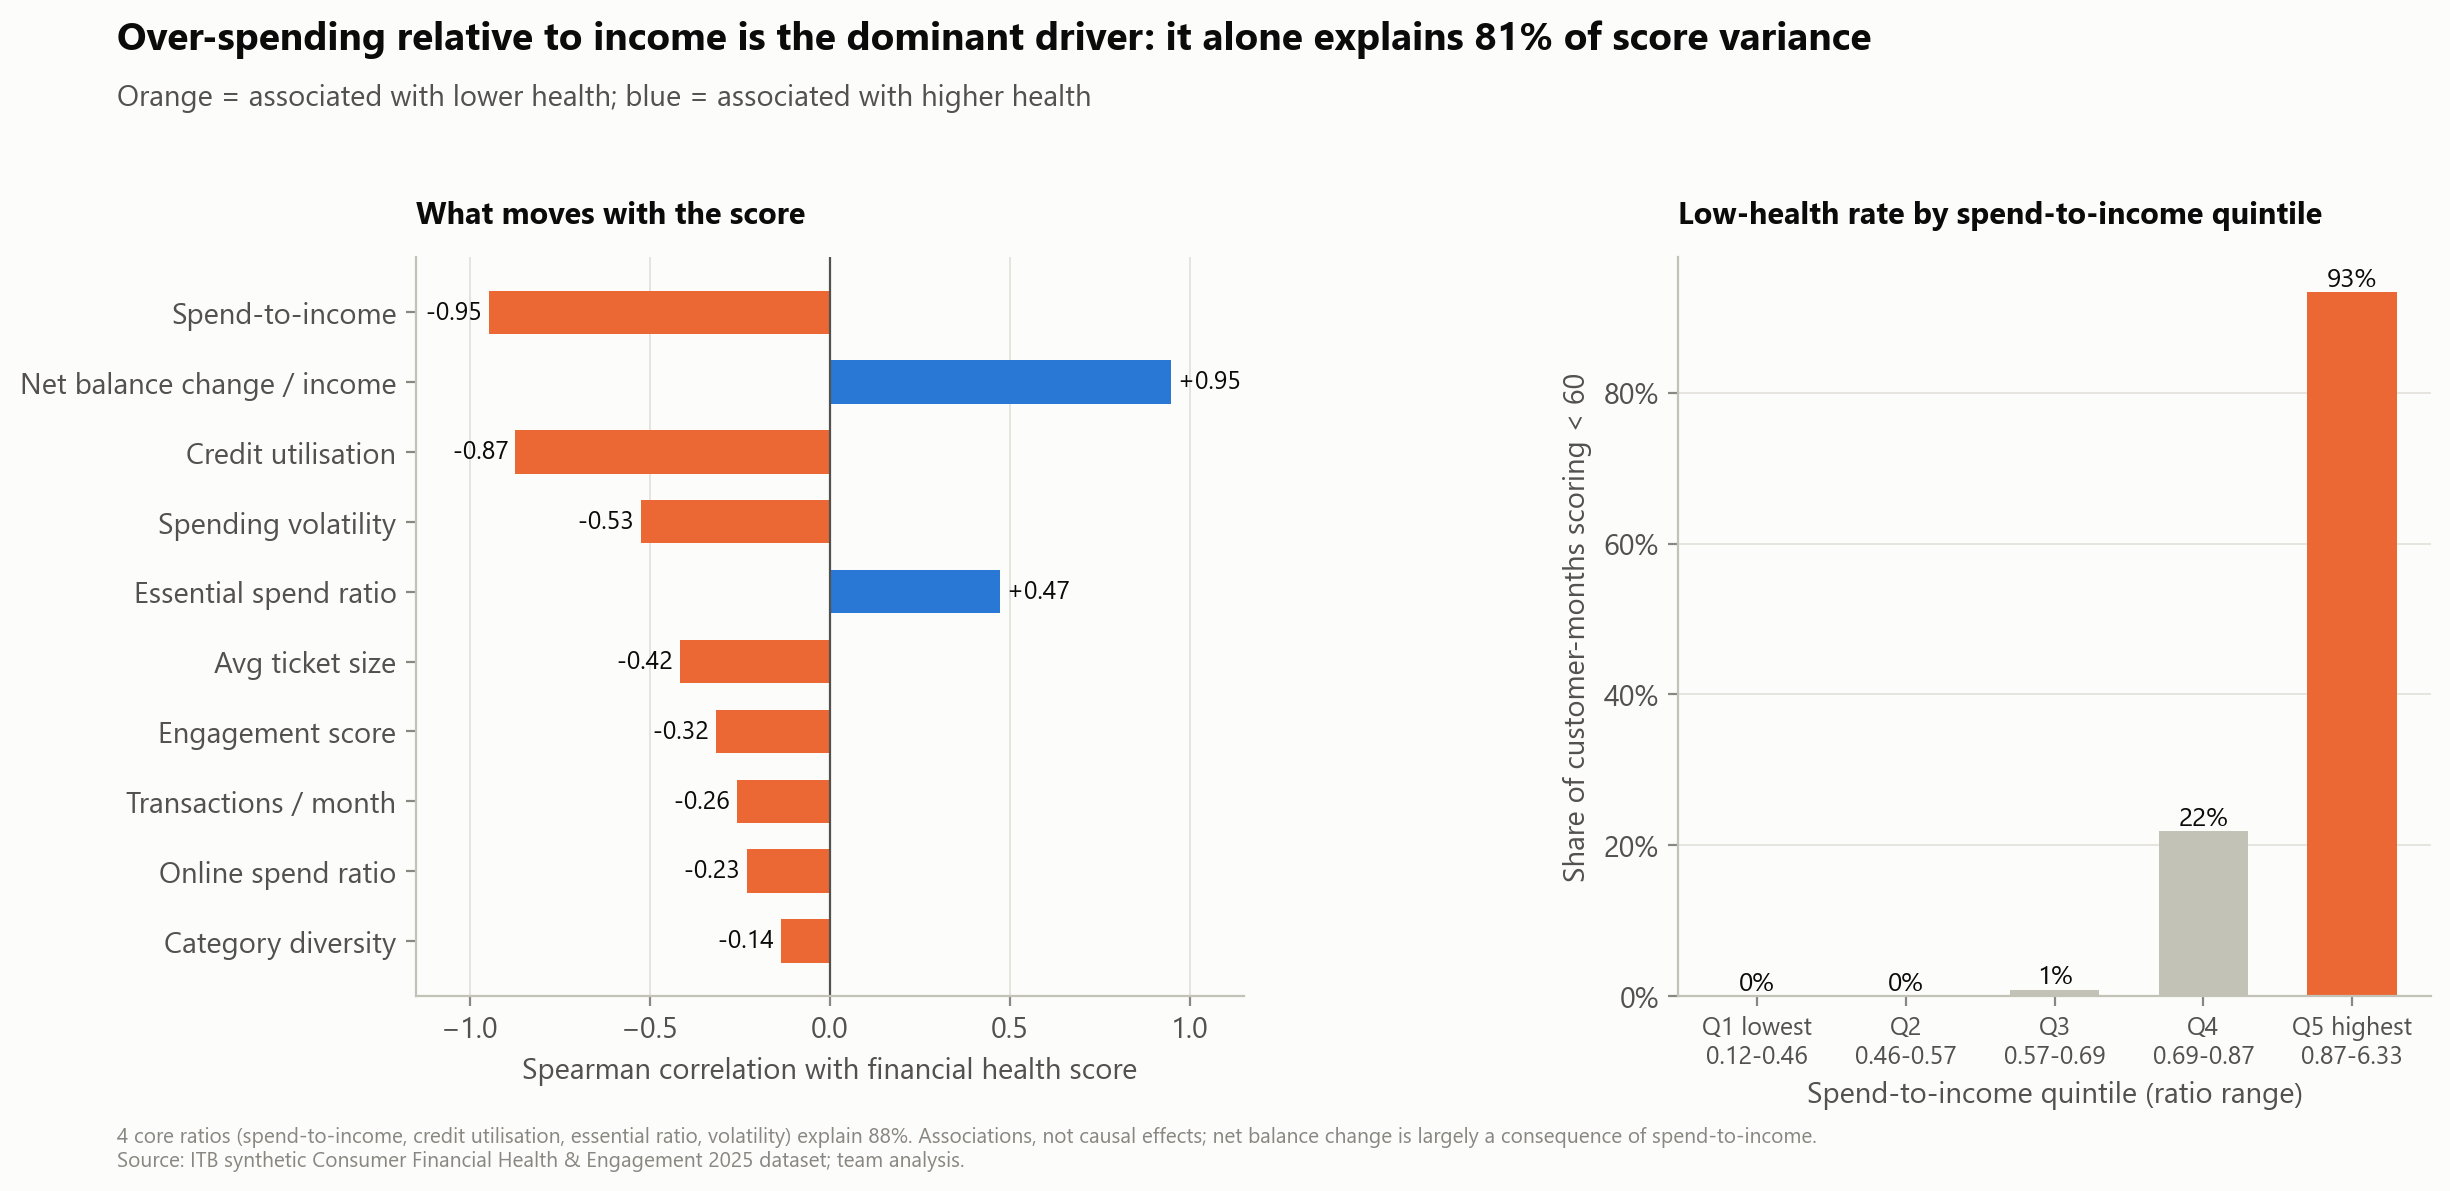

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.1, 1], "wspace": 0.55})
ax = axes[0]
d = drv.iloc[::-1]
ax.barh(d.label, d.corr_with_score, color=[BLUE if v > 0 else ORANGE for v in d.corr_with_score], height=0.62)
ax.axvline(0, color=INK_2, lw=0.8)
for i, v in enumerate(d.corr_with_score):
    ax.text(v, i, f" {v:+.2f} " if v > 0 else f" {v:+.2f} ", ha="left" if v > 0 else "right", va="center", fontsize=9)
ax.set_xlim(-1.15, 1.15); ax.grid(axis="y", visible=False)
ax.set_xlabel("Spearman correlation with financial health score")
ax.set_title("What moves with the score", fontsize=11)
ax = axes[1]
ax.bar(sti.index.astype(str), sti.low_rate, color=[GRAY] * 4 + [ORANGE], width=0.6)
for i, v in enumerate(sti.low_rate):
    ax.text(i, v, pct(v, 0), ha="center", va="bottom", fontsize=9.5)
ax.set_xticks(range(5), [f"{i}\n{r.sti_min:.2f}-{r.sti_max:.2f}" for i, r in sti.iterrows()], fontsize=9)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax.grid(axis="x", visible=False)
ax.set_ylabel("Share of customer-months scoring < 60")
ax.set_xlabel("Spend-to-income quintile (ratio range)")
ax.set_title("Low-health rate by spend-to-income quintile", fontsize=11)
show_chart(fig, "t2_drivers",
     title=f"Over-spending relative to income is the dominant driver: it alone explains {r2['spend_to_income only']:.0%} of score variance",
     subtitle="Orange = associated with lower health; blue = associated with higher health",
     note=f"4 core ratios (spend-to-income, credit utilisation, essential ratio, volatility) explain {r2['4 core ratios']:.0%}. "
          "Associations, not causal effects; net balance change is largely a consequence of spend-to-income.")

**Findings - Main factors associated with low health** (score <60 vs >=60, customer-months)

| Factor | Spearman rho with score | Median, low health | Median, rest | Ratio |
|---|---|---|---|---|
| Spend-to-income | **-0.95** | 1.040 | 0.565 | 1.84x |
| Net balance change / income | +0.95 | -0.040 | 0.435 | - |
| Credit utilisation | **-0.87** | 0.291 | 0.149 | 1.96x |
| Spending volatility | **-0.53** | 1.869 | 1.229 | 1.52x |
| Essential spend ratio | **+0.47** | 0.416 | 0.507 | 0.82x |
| Avg ticket size | -0.42 | 1.96 M | 1.53 M | 1.28x |
| Engagement score | -0.32 | 80.1 | 77.6 | 1.03x |
| Transactions / month | -0.26 | 178 | 144 | 1.24x |
| Online spend ratio | -0.23 | 0.221 | 0.186 | 1.19x |
| Category diversity | -0.14 | 14 | 14 | 1.00x |

- Spend-to-income **alone explains 81%** of score variance. The 4 core ratios (spend-to-income, credit utilisation, essential ratio, volatility) explain **88%**.
- Spend-to-income and credit utilisation correlate at 0.90; both measure the same over-spending pressure. Net balance change is largely a *consequence* of spend-to-income.
- Share of months below 60 by spend-to-income quintile: Q1 (0.12-0.46) 0.0%, Q2 (0.46-0.57) 0.0%, Q3 (0.57-0.69) 0.9%, **Q4 (0.69-0.87) 21.9%, Q5 (0.87-6.33) 93.3%**.
- **1,470 customer-months (13.4%) spend more than income**; **99.3%** of them score below 60 vs 11.5% otherwise.
- *These are associations, not causal effects.*

### 3. Occupation, age, province

In [ ]:
def breakdown(key, min_customers=1):
    g = c.groupby(key, observed=True).agg(customers=("consumer_id", "size"), score=("financial_health_score", "mean"),
                                           sti=("spend_to_income_ratio", "mean"), ess=("essential_spend_ratio", "mean"),
                                           low_months=("low_health_months", "sum"), months=("months_observed", "sum"))
    g["low_rate"] = g.low_months / g.months
    g = g[g.customers >= min_customers].sort_values("score")
    groups = [c.loc[c[key] == k, "financial_health_score"].values for k in g.index]
    p = kruskal(*groups).pvalue
    return g, p

F.add("\n## 3. Differences by occupation, age and province (customer-level mean score)")
bd = {}
for key, lab, mn in [("occupation_group", "Occupation group", 1), ("age_group", "Age group", 1),
                     ("province_city", "Province (>=15 customers)", 15)]:
    g, p = breakdown(key, mn)
    bd[key] = (g, p)
    g.to_csv(TABLES / f"t2_by_{key}.csv")
    F.add(f"- {lab}: range {g.score.min():.1f} ({g.score.idxmin()}) to {g.score.max():.1f} ({g.score.idxmax()}), "
          f"spread {g.score.max() - g.score.min():.1f} pts; Kruskal-Wallis p = {p:.3f}"
          f"{' (significant at 5%)' if p < 0.05 else ' (not significant at 5%)'}. Low-health month rate "
          f"{pct(g.low_rate.min())}-{pct(g.low_rate.max())}.")
    F.add(f"  - Lowest: {g.index[0]} score {g.score.iloc[0]:.1f}, spend-to-income {g.sti.iloc[0]:.2f}, essential {g.ess.iloc[0]:.2f}, "
          f"n={g.customers.iloc[0]}; highest: {g.index[-1]} score {g.score.iloc[-1]:.1f}, spend-to-income {g.sti.iloc[-1]:.2f}, "
          f"essential {g.ess.iloc[-1]:.2f}, n={g.customers.iloc[-1]}.")
F.add(f"- Occupation list mapped to {c.occupation_group.nunique()} groups by keyword (see tables/occupation_mapping.csv); "
      f"raw occupations have {c.occupation.nunique()} values for {len(c)} customers (~{len(c) / c.occupation.nunique():.1f} each), too thin to compare directly.")


## 3. Differences by occupation, age and province (customer-level mean score)
- Occupation group: range 63.5 (Public service & security) to 69.6 (Engineering & IT), spread 6.1 pts; Kruskal-Wallis p = 0.000 (significant at 5%). Low-health month rate 13.7%-32.3%.
  - Lowest: Public service & security score 63.5, spend-to-income 0.79, essential 0.43, n=89; highest: Engineering & IT score 69.6, spend-to-income 0.58, essential 0.46, n=143.
- Age group: range 65.7 (18-24) to 67.0 (55-64), spread 1.3 pts; Kruskal-Wallis p = 0.100 (not significant at 5%). Low-health month rate 20.2%-24.5%.
  - Lowest: 18-24 score 65.7, spend-to-income 0.66, essential 0.29, n=62; highest: 55-64 score 67.0, spend-to-income 0.68, essential 0.46, n=175.
- Province (>=15 customers): range 63.0 (Thái Nguyên) to 67.8 (Hà Nội), spread 4.8 pts; Kruskal-Wallis p = 0.006 (significant at 5%). Low-health month rate 17.2%-32.2%.
  - Lowest: Thái Nguyên score 63.0, spend-to-income 0.81, essential 0.48, n=18; highest: Hà Nội

#### 📊 Chart: `t2_health_by_segment`

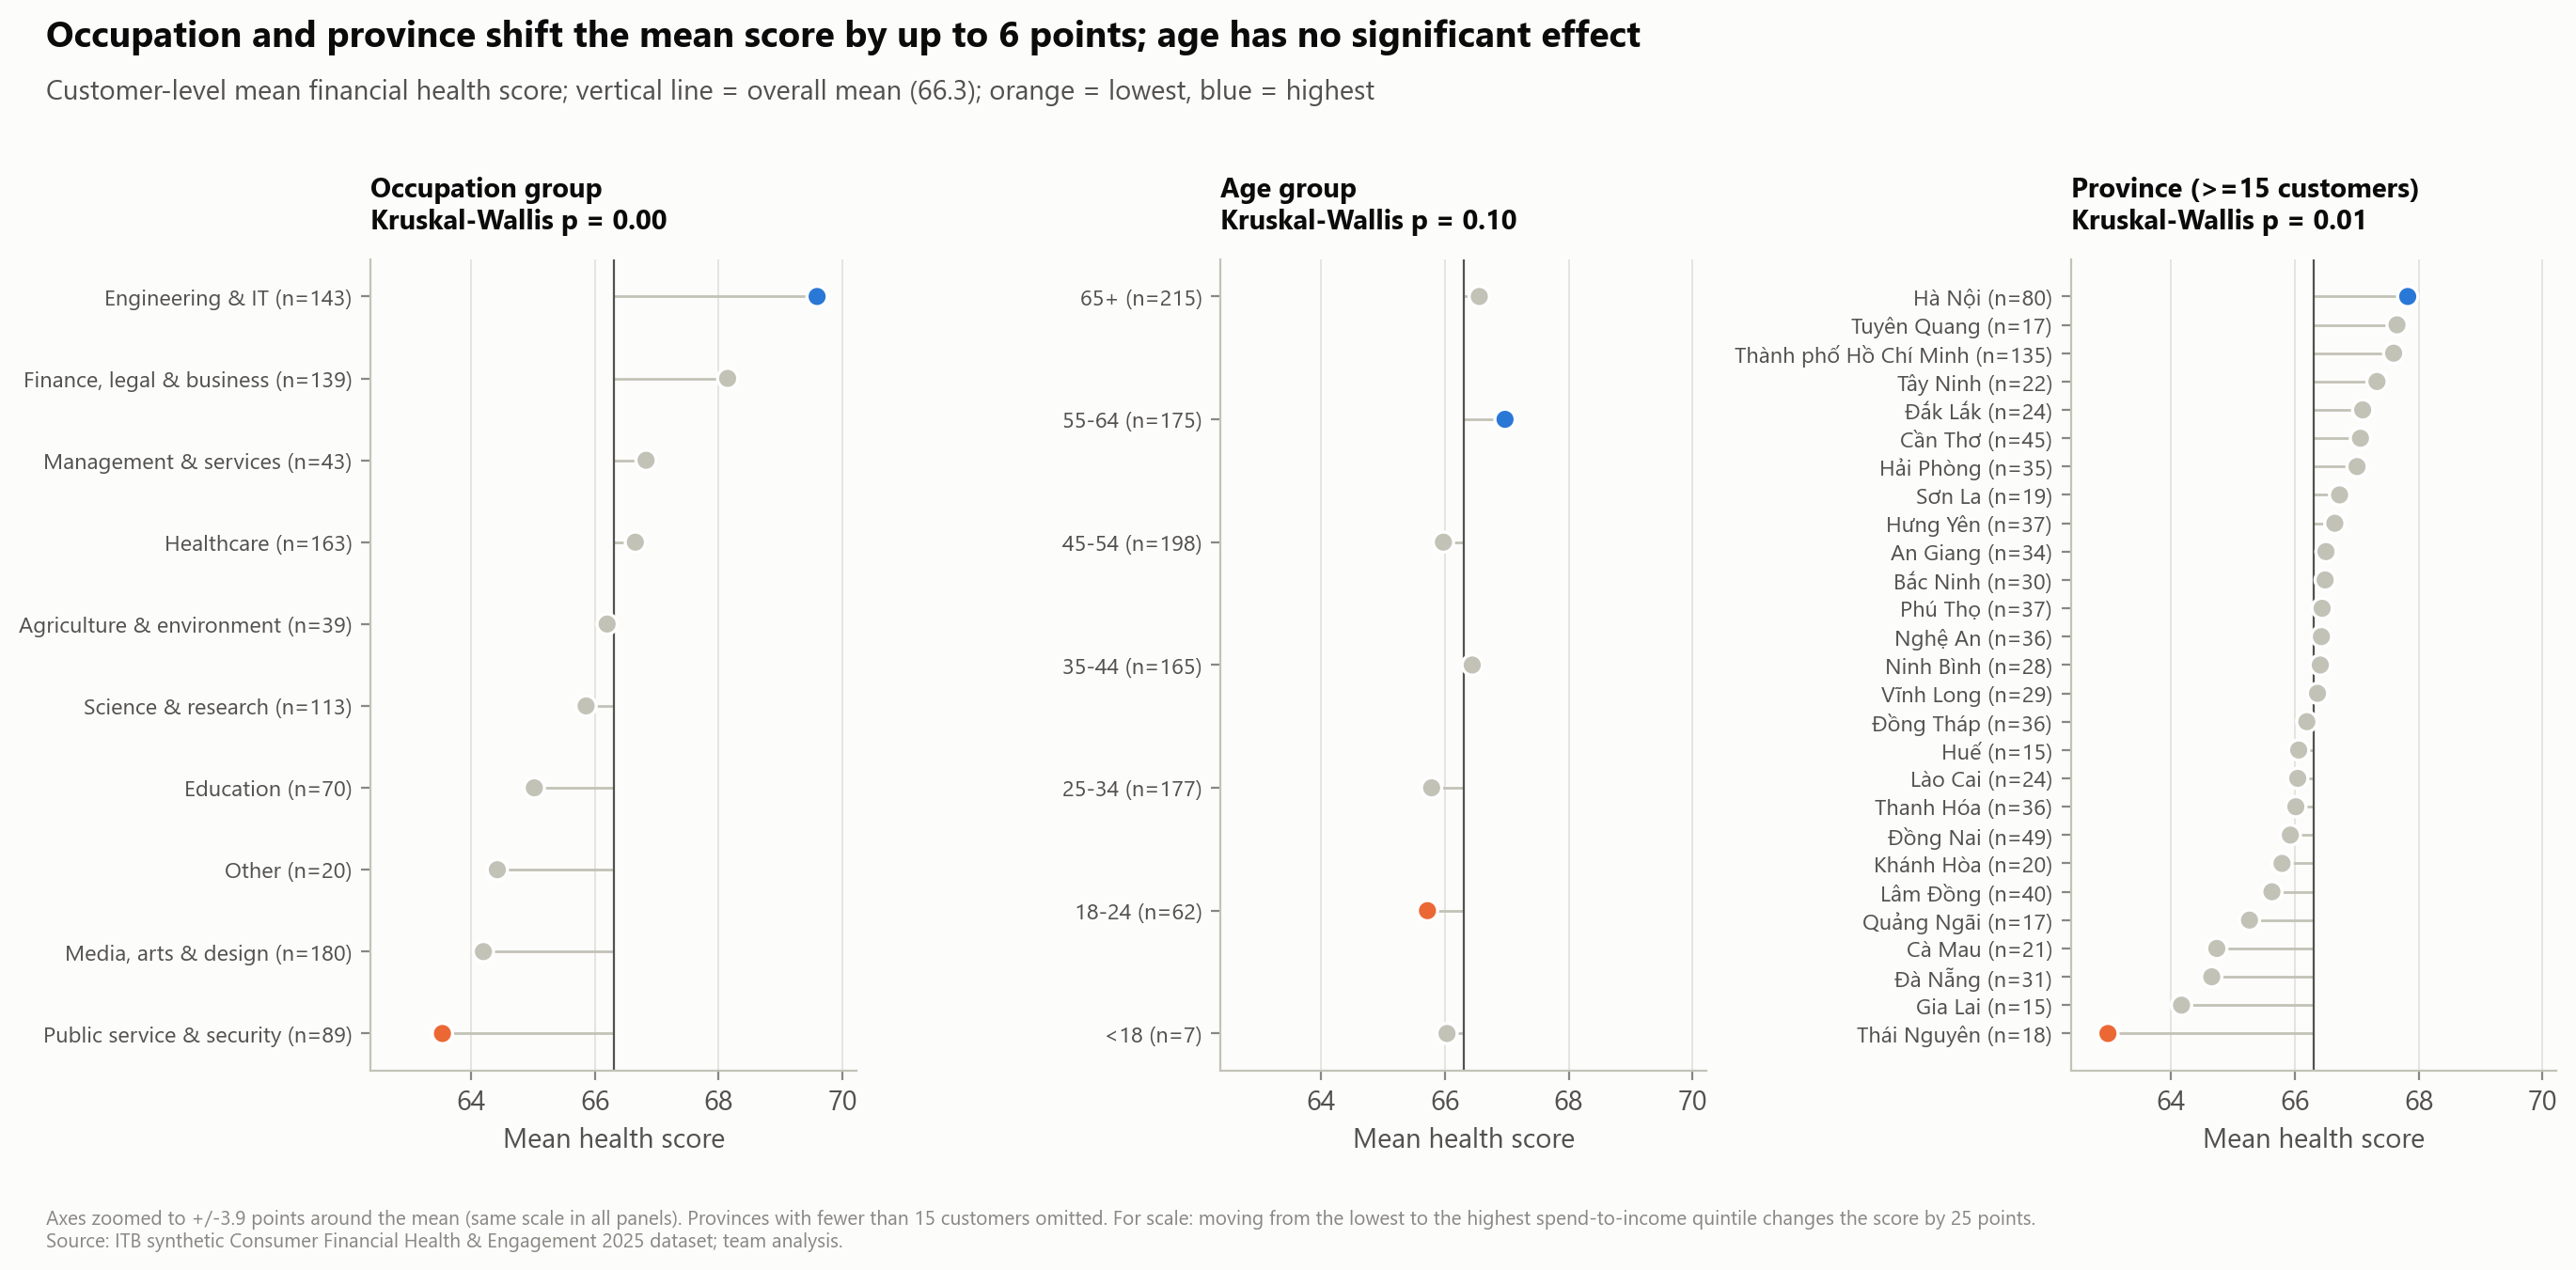

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), gridspec_kw={"wspace": 0.75})
overall = c.financial_health_score.mean()
span = max((g.score - overall).abs().max() for g, _ in bd.values()) + 0.6   # shared, symmetric, fits every point
for ax, (key, lab) in zip(axes, [("occupation_group", "Occupation group"), ("age_group", "Age group"),
                                 ("province_city", "Province (>=15 customers)")]):
    g, p = bd[key]
    if key == "age_group":
        g = g.sort_index()
    y = [f"{i} (n={n})" for i, n in zip(g.index, g.customers)]
    colors = [ORANGE if v == g.score.min() else (BLUE if v == g.score.max() else GRAY) for v in g.score]
    ax.scatter(g.score, y, color=colors, s=60, zorder=3, edgecolor="white", linewidth=1.2)
    ax.hlines(y, overall, g.score, color=GRAY, lw=1)
    ax.axvline(overall, color=INK_2, lw=0.8)
    ax.set_title(f"{lab}\nKruskal-Wallis p = {p:.2f}", fontsize=10.5)
    ax.tick_params(axis="y", labelsize=8.5)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(overall - span, overall + span)
    ax.set_xlabel("Mean health score")
show_chart(fig, "t2_health_by_segment",
     title=f"Occupation and province shift the mean score by up to {bd['occupation_group'][0].score.max() - bd['occupation_group'][0].score.min():.0f} points; age has no significant effect",
     subtitle="Customer-level mean financial health score; vertical line = overall mean "
              f"({overall:.1f}); orange = lowest, blue = highest",
     note=f"Axes zoomed to +/-{span:.1f} points around the mean (same scale in all panels). Provinces with fewer than 15 customers "
          "omitted. For scale: moving from the lowest to the highest spend-to-income quintile changes the score by "
          f"{m.groupby(q, observed=True).financial_health_score.mean().pipe(lambda s: s.iloc[0] - s.iloc[-1]):.0f} points.")

**Findings - Differences by occupation, age and province** (customer-level mean score)
- **Occupation group:** from 63.5 (**Public service & security**, spend-to-income 0.79, n=89) to 69.6 (**Engineering & IT**, spend-to-income 0.58, n=143). The spread is **6.1 pts**, Kruskal-Wallis **p < 0.001 (significant)**, and the low-health month rate ranges 13.7%-32.3%.
- **Age group:** from 65.7 (18-24, n=62) to 67.0 (55-64, n=175). The spread is only **1.3 pts**, **p = 0.10 (not significant)**, and the low-health month rate ranges 20.2%-24.5%.
- **Province (>=15 customers):** from 63.0 (**Thái Nguyên**, spend-to-income 0.81, n=18) to 67.8 (**Hà Nội**, spend-to-income 0.65, n=80). The spread is **4.8 pts**, **p = 0.006 (significant)**, and the low-health month rate ranges 17.2%-32.2%.
- The lowest groups all show **higher spend-to-income**, so the behavioural driver explains the demographic gaps. For scale, moving from the lowest to the highest spend-to-income quintile changes the score by about **25 points**.
- The 396 raw occupations (about 2.5 customers each) were mapped to 10 groups by keyword (`tables/occupation_mapping.csv`).

### 4. Financially stressed but highly engaged

In [ ]:
LOW_H, HIGH_E, MIN_SHARE = 60, 80, 0.25
c["low_share"] = c.low_health_months / c.months_observed
rule = (c.low_share >= MIN_SHARE) & (c.engagement_score >= HIGH_E)
c["stressed_engaged"] = rule
grp = c[rule]
F.add(f"\n## 4. Financially stressed but highly engaged\n- Rule (customer level, reproducible): score < {LOW_H} "
      f"(Watch/Stressed band) in >= {MIN_SHARE:.0%} of observed months AND mean engagement_score >= {HIGH_E} "
      f"(dataset's 'Very high' band).")
F.add(f"- Size: {len(grp)} customers ({pct(len(grp) / len(c))} of {len(c)}); they account for "
      f"{pct(grp.total_spend_vnd.sum() / c.total_spend_vnd.sum())} of total spend.")
sens = []
for sh in (0.15, 0.25, 0.33, 0.5):   # = 2, 3, 4, 6 of 12 months
    for he in (78, 80, 82):
        sens.append({"min_share_low_months": sh, "min_engagement": he,
                     "customers": int(((c.low_share >= sh) & (c.engagement_score >= he)).sum())})
pd.DataFrame(sens).pivot(index="min_share_low_months", columns="min_engagement", values="customers").to_csv(
    TABLES / "t2_stressed_engaged_sensitivity.csv")
F.add("- Sensitivity (customers): " + "; ".join(f"share>={d['min_share_low_months']:.0%} & eng>={d['min_engagement']}: {d['customers']}"
                                                for d in sens if d["min_engagement"] == 80))
others = c[~rule]
cols = {"financial_health_score": "Health score", "engagement_score": "Engagement", "spend_to_income_ratio": "Spend-to-income",
        "credit_utilization_ratio": "Credit utilisation", "essential_spend_ratio": "Essential ratio",
        "spending_volatility": "Volatility", "online_spend_ratio": "Online ratio", "digital_txn_share": "Digital txn share",
        "transaction_count": "Txns / month", "active_transaction_days": "Active days", "balance_change_ratio": "Balance change / income",
        "age": "Age"}
prof = pd.DataFrame({"stressed_engaged": grp[list(cols)].mean(), "others": others[list(cols)].mean()})
prof["ratio"] = prof.stressed_engaged / prof.others
prof.index = [cols[k] for k in prof.index]
prof.to_csv(TABLES / "t2_stressed_engaged_profile.csv")
for k, r in prof.iterrows():
    F.add(f"  - {k}: {r.stressed_engaged:,.2f} vs {r.others:,.2f}")
F.add("- Age mix: " + ", ".join(f"{a} {pct(v)}" for a, v in grp.age_group.value_counts(normalize=True).sort_index().items()
                                if v > 0))
F.add("- Top occupation groups: " + ", ".join(f"{a} {pct(v)}" for a, v in grp.occupation_group.value_counts(normalize=True).head(3).items()))
grp[["consumer_id", "months_observed", "low_health_months", "financial_health_score", "engagement_score",
     "spend_to_income_ratio", "essential_spend_ratio", "age_group", "occupation_group", "province_city"]].to_csv(
    TABLES / "t2_stressed_engaged_customers.csv", index=False, encoding="utf-8-sig")

# Transaction-level deep dive for the group
t = load_txn(["consumer_id", "category_en", "spend_amount_vnd", "transaction_channel", "transaction_day_of_week",
              "essential_spending_flag"])
t["grp"] = np.where(t.consumer_id.isin(grp.consumer_id), "Stressed & engaged", "Others")
catm = t.pivot_table(index="category_en", columns="grp", values="spend_amount_vnd", aggfunc="sum", observed=True)
catm = catm / catm.sum()
catm["diff_pts"] = (catm["Stressed & engaged"] - catm["Others"]) * 100
catm = catm.sort_values("diff_pts")
catm.to_csv(TABLES / "t2_stressed_engaged_category_mix.csv")
chm = pd.crosstab(t.grp, t.transaction_channel, normalize="index")[CHANNEL_ORDER]
chm.to_csv(TABLES / "t2_stressed_engaged_channel_mix.csv")
wk = t.assign(we=t.transaction_day_of_week >= 5).groupby("grp").we.mean()
F.add(f"- Transactions: top over-weight categories " + ", ".join(f"{i} {v:+.1f} pts" for i, v in catm.diff_pts.iloc[::-1].head(3).items())
      + "; under-weight " + ", ".join(f"{i} {v:+.1f} pts" for i, v in catm.diff_pts.head(3).items()) + ".")
F.add(f"- Channel mix (share of txns) group vs others: " + ", ".join(
    f"{ch} {pct(chm.loc['Stressed & engaged', ch])} vs {pct(chm.loc['Others', ch])}" for ch in CHANNEL_ORDER)
      + f"; weekend share {pct(wk['Stressed & engaged'])} vs {pct(wk['Others'])}.")


## 4. Financially stressed but highly engaged
- Rule (customer level, reproducible): score < 60 (Watch/Stressed band) in >= 25% of observed months AND mean engagement_score >= 80 (dataset's 'Very high' band).
- Size: 106 customers (10.6% of 999); they account for 16.5% of total spend.
- Sensitivity (customers): share>=15% & eng>=80: 151; share>=25% & eng>=80: 106; share>=33% & eng>=80: 75; share>=50% & eng>=80: 23
  - Health score: 62.69 vs 66.73
  - Engagement: 81.53 vs 74.67
  - Spend-to-income: 0.79 vs 0.68
  - Credit utilisation: 0.22 vs 0.19
  - Essential ratio: 0.47 vs 0.45
  - Volatility: 1.84 vs 1.45
  - Online ratio: 0.24 vs 0.25
  - Digital txn share: 0.43 vs 0.42
  - Txns / month: 239.56 vs 145.33
  - Active days: 30.10 vs 25.97
  - Balance change / income: 0.21 vs 0.32
  - Age: 38.75 vs 51.40
- Age mix: <18 0.9%, 18-24 14.2%, 25-34 25.5%, 35-44 29.2%, 45-54 21.7%, 55-64 1.9%, 65+ 6.6%
- Top occupation groups: Media, arts & design 22.6%, Healthcare 19.8%, Science & research

#### 📊 Chart: `t2_stressed_engaged`

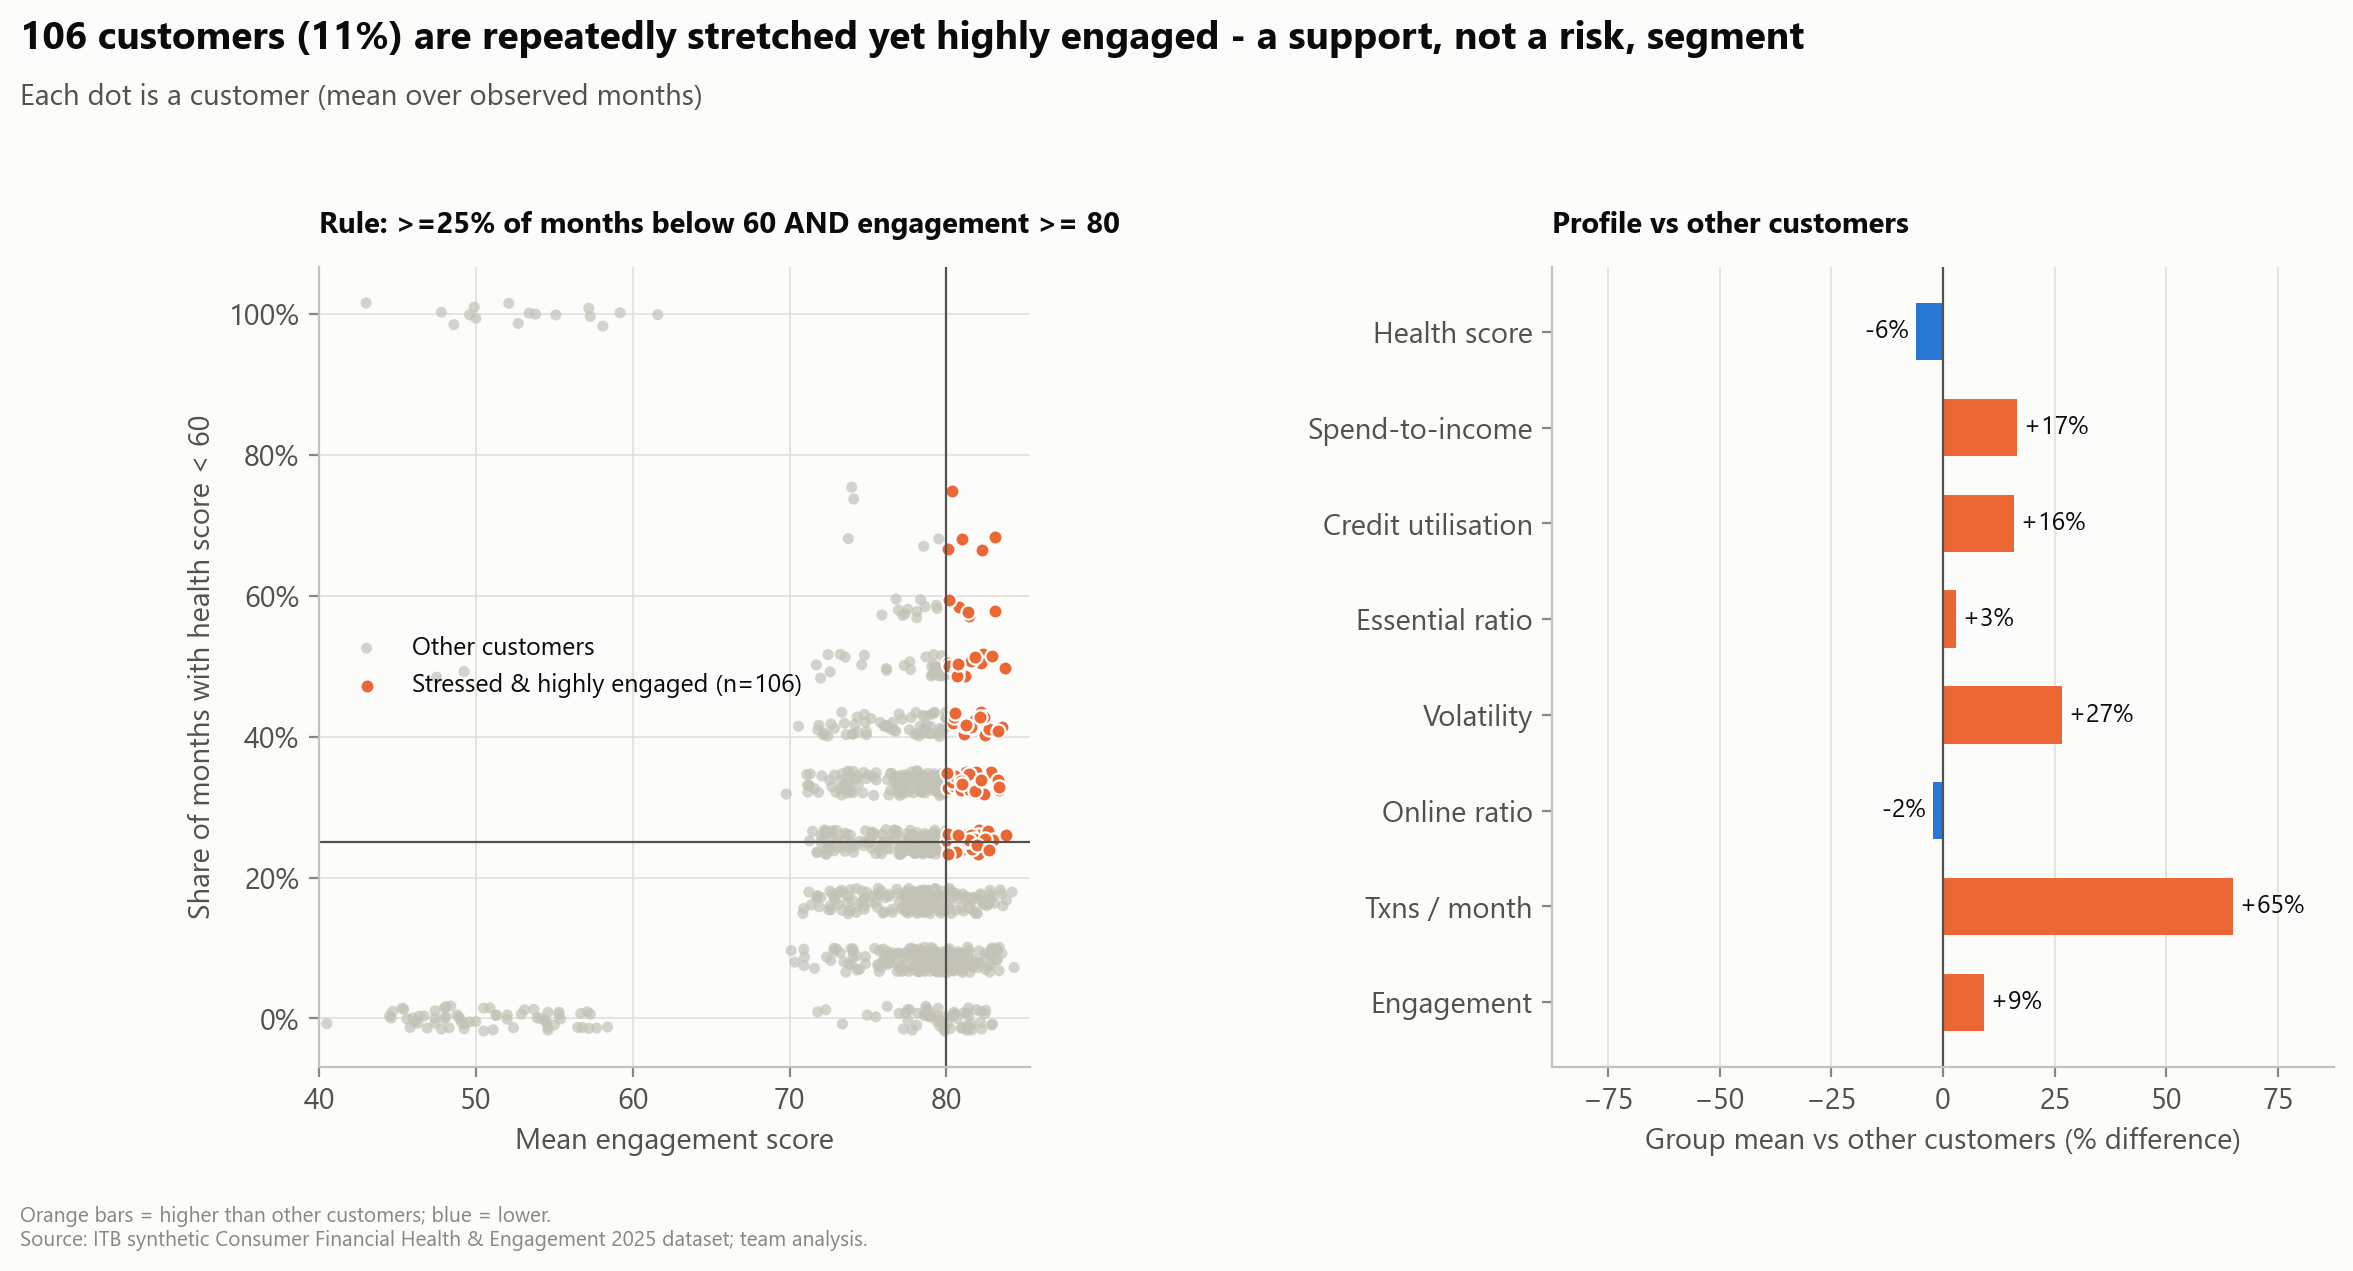

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1, 1.1], "wspace": 0.7})
ax = axes[0]
jit = np.random.default_rng(42).uniform(-0.018, 0.018, len(c))   # vertical jitter: shares take k/12 values
c["low_share_j"] = c.low_share + jit
ax.scatter(c.engagement_score[~rule], c.low_share_j[~rule], s=16, color=GRAY, alpha=0.7, edgecolor="none", label="Other customers")
ax.scatter(c.engagement_score[rule], c.low_share_j[rule], s=26, color=ORANGE, edgecolor="white", linewidth=0.8,
           label=f"Stressed & highly engaged (n={len(grp)})")
ax.axvline(HIGH_E, color=INK_2, lw=0.8); ax.axhline(MIN_SHARE, color=INK_2, lw=0.8)
ax.set_xlim(max(40, c.engagement_score.min() - 2), c.engagement_score.max() + 1)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_xlabel("Mean engagement score"); ax.set_ylabel("Share of months with health score < 60")
ax.legend(loc="center left", fontsize=9)
ax.set_title("Rule: >=25% of months below 60 AND engagement >= 80", fontsize=10.5)
ax = axes[1]
show = ["Health score", "Spend-to-income", "Credit utilisation", "Essential ratio", "Volatility", "Online ratio",
        "Txns / month", "Engagement"]
rr = prof.loc[show, "ratio"].iloc[::-1]
ax.barh(rr.index, (rr - 1) * 100, color=[ORANGE if v > 1 else BLUE for v in rr], height=0.6)
ax.axvline(0, color=INK_2, lw=0.8)
for i, v in enumerate(rr):
    ax.text((v - 1) * 100, i, f" {(v - 1) * 100:+.0f}% " if v > 1 else f" {(v - 1) * 100:+.0f}% ",
            ha="left" if v > 1 else "right", va="center", fontsize=9)
lim = np.abs((rr - 1) * 100).max() * 1.35
ax.set_xlim(-lim, lim); ax.grid(axis="y", visible=False)
ax.set_xlabel("Group mean vs other customers (% difference)")
ax.set_title("Profile vs other customers", fontsize=10.5)
show_chart(fig, "t2_stressed_engaged",
     title=f"{len(grp)} customers ({pct(len(grp) / len(c), 0)}) are repeatedly stretched yet highly engaged - a support, not a risk, segment",
     subtitle="Each dot is a customer (mean over observed months)",
     note="Orange bars = higher than other customers; blue = lower.")

**Findings - Financially stressed but highly engaged**
- **Rule (customer level, reproducible):** health score < 60 (Watch/Stressed band) in **>= 25% of observed months** (3+ of 12) **AND** mean engagement_score **>= 80** (the dataset's "Very high" band).
- **Size: 106 customers (10.6% of 999)**, accounting for **16.5% of total spend**.
- Sensitivity at engagement >=80: low-month share >=15% → 151; **>=25% → 106**; >=33% → 75; >=50% → 23.

| Metric | Stressed & engaged | Other customers |
|---|---|---|
| Health score | 62.7 | 66.7 |
| Engagement | 81.5 | 74.7 |
| Spend-to-income | 0.79 | 0.68 |
| Credit utilisation | 0.22 | 0.19 |
| Volatility | 1.84 | 1.45 |
| Txns / month | 239.6 | 145.3 |
| Active days | 30.1 | 26.0 |
| Balance change / income | 0.21 | 0.32 |
| Age (mean) | 38.8 | 51.4 |

- Age mix: 25-34 25.5%, **35-44 29.2%**, 45-54 21.7%, 18-24 14.2%. The group is working-age and younger than average.
- Top occupation groups: Media, arts & design 22.6%, Healthcare 19.8%, Science & research 13.2%.
- From the transaction file: they over-index on **Online shopping (+1.7 pts), Online grocery (+1.2), In-store shopping (+1.1)** and use more E-commerce (10.2% vs 8.4%) and Mobile App (8.5% vs 7.5%).
- **Implication:** these are loyal, digitally reachable customers whose budgets are repeatedly stretched. They are a **support** segment (budgeting tools, spend alerts), never grounds for a credit decision.

## 4. Task 3 - Customer engagement analysis

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

style()
F = Findings("task3")
m, c = load_cm(), load_cust()
t = load_txn(["consumer_id", "transaction_channel", "spend_amount_vnd", "online_transaction_flag"])
F.add("# Task 3 findings - Customer engagement")

# Task 3 findings - Customer engagement


### 1. Engagement distribution & segment shares

In [ ]:
e = m.engagement_score
seg_cm = m.eng_seg.value_counts().reindex(ENG_ORDER)
seg_c = c.eng_seg.value_counts().reindex(ENG_ORDER)
full = c.months_observed == 12
F.add(f"\n## 1. Distribution\n- Customer-months: mean {e.mean():.1f}, median {e.median():.1f}, std {e.std():.1f}, "
      f"P10 {e.quantile(.1):.1f}, P90 {e.quantile(.9):.1f}, range {e.min():.1f}-{e.max():.1f}; skew {e.skew():.2f}.")
F.add("- Segment share, customer-months: " + ", ".join(f"{k} {v:,} ({pct(v / len(m))})" for k, v in seg_cm.items()))
F.add("- Segment share, customers (mean score): " + ", ".join(f"{k} {v} ({pct(v / len(c))})" for k, v in seg_c.items()))
F.add(f"- Full-year customers (12 months, n={full.sum()}): mean engagement {c[full].engagement_score.mean():.1f}, "
      f"range {c[full].engagement_score.min():.1f}-{c[full].engagement_score.max():.1f}. Partial-year customers "
      f"(1-2 months, n={(~full).sum()}): mean {c[~full].engagement_score.mean():.1f}, "
      f"{c[~full].transaction_count.mean():.1f} txns in their single active month.")
F.add(f"- {pct((c[~full].eng_seg.isin(['Low', 'Medium'])).sum() / max(1, c.eng_seg.isin(['Low', 'Medium']).sum()))} of customers in the "
      f"Low/Medium bands are partial-year customers -> the dataset's own low bands essentially flag one-off users.")


## 1. Distribution
- Customer-months: mean 77.8, median 78.1, std 6.3, P10 70.6, P90 84.9, range 9.7-99.6; skew -1.15.
- Segment share, customer-months: Low 10 (0.1%), Medium 100 (0.9%), High 7,058 (64.2%), Very high 3,824 (34.8%)
- Segment share, customers (mean score): Low 10 (1.0%), Medium 80 (8.0%), High 668 (66.9%), Very high 241 (24.1%)
- Full-year customers (12 months, n=908): mean engagement 78.1, range 69.8-84.3. Partial-year customers (1-2 months, n=91): mean 48.7, 9.7 txns in their single active month.
- 100.0% of customers in the Low/Medium bands are partial-year customers -> the dataset's own low bands essentially flag one-off users.


#### 📊 Chart: `t3_engagement_distribution`

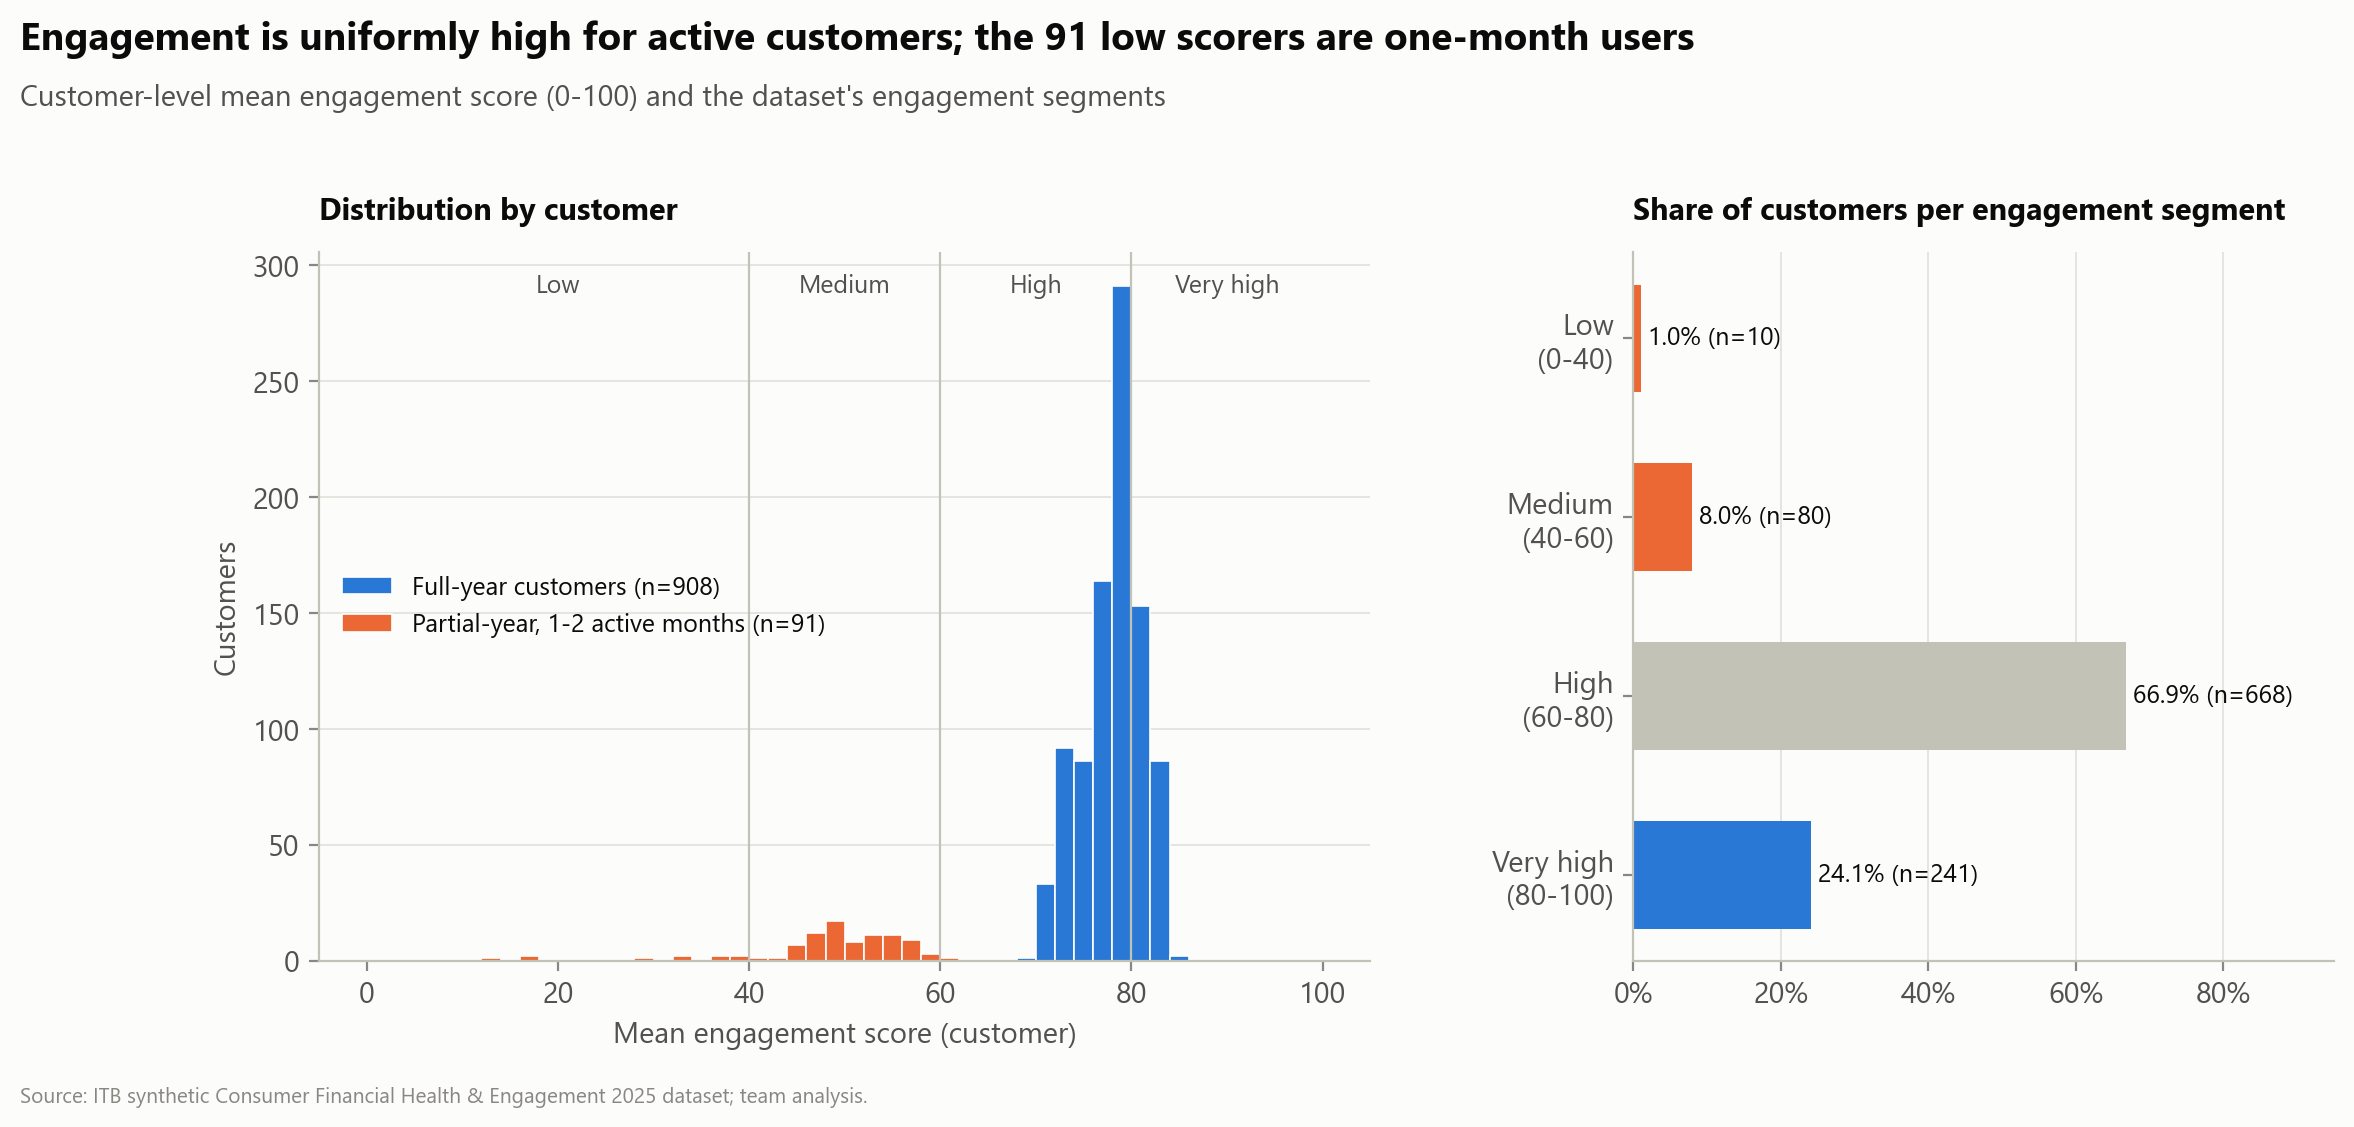

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.5, 1], "wspace": 0.3})
ax = axes[0]
bins = np.arange(0, 101, 2)
ax.hist(c.engagement_score[full], bins=bins, color=BLUE, edgecolor="white", linewidth=0.6,
        label=f"Full-year customers (n={full.sum()})")
ax.hist(c.engagement_score[~full], bins=bins, color=ORANGE, edgecolor="white", linewidth=0.6,
        label=f"Partial-year, 1-2 active months (n={(~full).sum()})")
for x in (40, 60, 80):
    ax.axvline(x, color=GRAY, lw=0.8)
for x0, x1, lab in [(0, 40, "Low"), (40, 60, "Medium"), (60, 80, "High"), (80, 100, "Very high")]:
    ax.text((x0 + x1) / 2, ax.get_ylim()[1] * 0.97, lab, ha="center", va="top", fontsize=9, color=INK_2)
ax.set_xlabel("Mean engagement score (customer)"); ax.set_ylabel("Customers")
ax.legend(loc="center left", fontsize=9); ax.grid(axis="x", visible=False)
ax.set_title("Distribution by customer", fontsize=11)
ax = axes[1]
y = np.arange(len(ENG_ORDER))[::-1]
ax.barh(y, seg_c.values / len(c), color=[ORANGE, ORANGE, GRAY, BLUE], height=0.6)
for yi, v, n in zip(y, seg_c.values / len(c), seg_c.values):
    ax.text(v, yi, f" {pct(v)} (n={n})", va="center", fontsize=9)
ax.set_yticks(y, [f"{k}\n({lo}-{hi})" for k, (lo, hi) in zip(ENG_ORDER, [(0, 40), (40, 60), (60, 80), (80, 100)])])
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax.set_xlim(0, 0.95); ax.grid(axis="y", visible=False)
ax.set_title("Share of customers per engagement segment", fontsize=11)
show_chart(fig, "t3_engagement_distribution",
     title=f"Engagement is uniformly high for active customers; the {(~full).sum()} low scorers are one-month users",
     subtitle="Customer-level mean engagement score (0-100) and the dataset's engagement segments")

**Findings - Engagement distribution and segment shares**
- Customer-months: mean **77.8**, median 78.1, std 6.3, P10 70.6, P90 84.9, range 9.7-99.6.
- Segment share (customer-months): Low 10 (0.1%), Medium 100 (0.9%), **High 7,058 (64.2%)**, **Very high 3,824 (34.8%)**.
- Segment share (customers, mean score): Low 10 (1.0%), Medium 80 (8.0%), **High 668 (66.9%)**, **Very high 241 (24.1%)**.
- Full-year customers (n=908): mean engagement 78.1, range 69.8-84.3. **Partial-year customers (n=91): mean 48.7**, with about 9.7 transactions in their single active month.
- **100% of customers in the Low/Medium bands are one-month users.** The dataset's low bands essentially flag customers who tried the service once and did not return.

### 2. Channel usage and online share

In [ ]:
chs = pd.DataFrame({
    "txn_share": t.transaction_channel.value_counts(normalize=True),
    "spend_share": t.groupby("transaction_channel", observed=True).spend_amount_vnd.sum() / t.spend_amount_vnd.sum(),
    "customers_using": t.groupby("transaction_channel", observed=True).consumer_id.nunique() / t.consumer_id.nunique(),
}).reindex(CHANNEL_ORDER)
chs["avg_share_per_customer"] = [c[f"share_txn_{ch.replace(' ', '_')}"].mean() for ch in CHANNEL_ORDER]
chs.to_csv(TABLES / "t3_channel_usage.csv")
used = c.channels_used.value_counts().sort_index()
F.add("\n## 2. Channel usage")
for ch, r in chs.iterrows():
    F.add(f"- {ch}: {pct(r.txn_share)} of transactions, {pct(r.spend_share)} of spend, used by {pct(r.customers_using)} of customers "
          f"(avg customer share {pct(r.avg_share_per_customer)}).")
F.add(f"- Average online spend ratio (online_spend_ratio, excludes QR): {pct(m.online_spend_ratio.mean())} per customer-month "
      f"(median {pct(m.online_spend_ratio.median())}); pooled {pct(m.online_spend_vnd.sum() / m.total_spend_vnd.sum())}. "
      f"Including QR (all non-POS): {pct(m.digital_spend_ratio.mean())}.")
F.add("- Number of channels used per customer (year): " + ", ".join(f"{k}: {v}" for k, v in used.items()))
F.add(f"- Customers with online spend ratio < 10% (mean): {(c.online_spend_ratio < 0.10).sum()}; > 40%: {(c.online_spend_ratio > 0.40).sum()}.")


## 2. Channel usage
- POS: 58.8% of transactions, 58.5% of spend, used by 100.0% of customers (avg customer share 57.5%).
- QR Payment: 19.8% of transactions, 19.6% of spend, used by 97.6% of customers (avg customer share 19.4%).
- E-commerce: 8.7% of transactions, 9.6% of spend, used by 99.0% of customers (avg customer share 9.8%).
- Mobile App: 7.7% of transactions, 7.6% of spend, used by 98.1% of customers (avg customer share 8.4%).
- Recurring Payment: 4.9% of transactions, 4.6% of spend, used by 94.3% of customers (avg customer share 4.9%).
- Average online spend ratio (online_spend_ratio, excludes QR): 21.0% per customer-month (median 19.2%); pooled 21.8%. Including QR (all non-POS): 40.9%.
- Number of channels used per customer (year): 2: 3, 3: 30, 4: 41, 5: 925
- Customers with online spend ratio < 10% (mean): 3; > 40%: 81.


#### 📊 Chart: `t3_channel_usage`

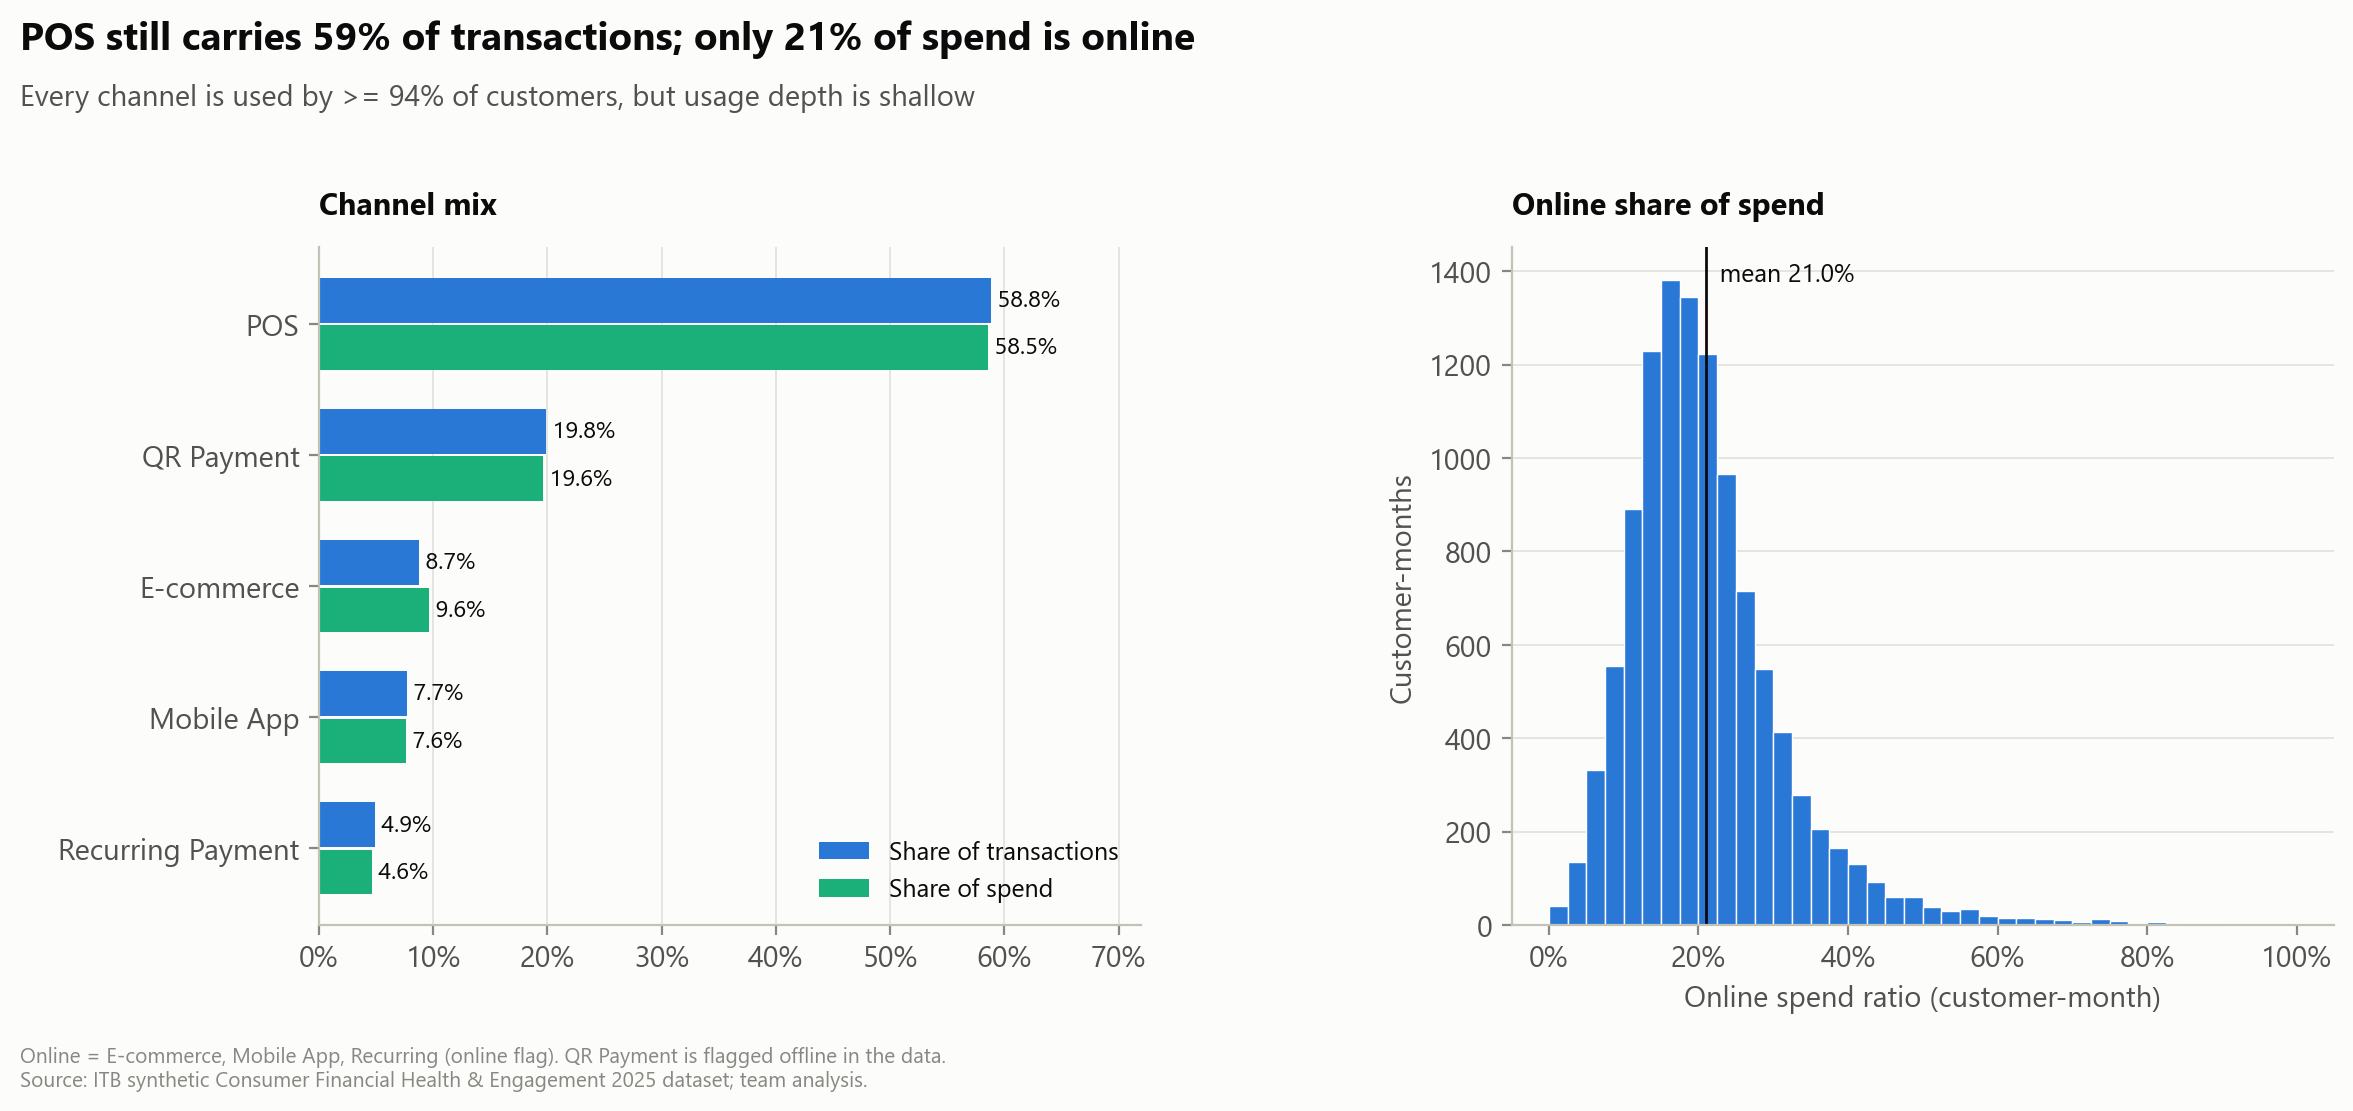

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"wspace": 0.45})
ax = axes[0]
yy = np.arange(len(CHANNEL_ORDER))[::-1]
ax.barh(yy + 0.18, chs.txn_share, height=0.34, color=BLUE, label="Share of transactions")
ax.barh(yy - 0.18, chs.spend_share, height=0.34, color=AQUA, label="Share of spend")
for yi, a, b in zip(yy, chs.txn_share, chs.spend_share):
    ax.text(a, yi + 0.18, f" {pct(a)}", va="center", fontsize=8.5)
    ax.text(b, yi - 0.18, f" {pct(b)}", va="center", fontsize=8.5)
ax.set_yticks(yy, CHANNEL_ORDER); ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_xlim(0, 0.72); ax.grid(axis="y", visible=False); ax.legend(loc="lower right", fontsize=9)
ax.set_title("Channel mix", fontsize=11)
ax = axes[1]
ax.hist(m.online_spend_ratio, bins=np.arange(0, 1.01, 0.025), color=BLUE, edgecolor="white", linewidth=0.5)
ax.axvline(m.online_spend_ratio.mean(), color=INK, lw=1)
ax.text(m.online_spend_ratio.mean(), ax.get_ylim()[1] * 0.95, f"  mean {pct(m.online_spend_ratio.mean())}", fontsize=9)
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax.grid(axis="x", visible=False)
ax.set_xlabel("Online spend ratio (customer-month)"); ax.set_ylabel("Customer-months")
ax.set_title("Online share of spend", fontsize=11)
show_chart(fig, "t3_channel_usage",
     title=f"POS still carries {pct(chs.loc['POS', 'txn_share'], 0)} of transactions; only {pct(m.online_spend_ratio.mean(), 0)} of spend is online",
     subtitle=f"Every channel is used by >= {pct(chs.customers_using.min(), 0)} of customers, but usage depth is shallow",
     note="Online = E-commerce, Mobile App, Recurring (online flag). QR Payment is flagged offline in the data.")

**Findings - Channel usage and online share**

| Channel | Share of txns | Share of spend | Customers using | Avg customer share |
|---|---|---|---|---|
| POS | 58.8% | 58.5% | 100.0% | 57.5% |
| QR Payment | 19.8% | 19.6% | 97.6% | 19.4% |
| E-commerce | 8.7% | 9.6% | 99.0% | 9.8% |
| Mobile App | 7.7% | 7.6% | 98.1% | 8.4% |
| Recurring Payment | 4.9% | 4.6% | 94.3% | 4.9% |

- Average **online spend ratio = 21.0%** per customer-month (median 19.2%; pooled 21.8%). Including QR (all non-POS) the share rises to **40.9%**.
- 925 of 999 customers use all 5 channels; only 3 customers have an online ratio below 10%, and 81 are above 40%.
- **Interpretation:** almost everyone has *tried* every channel, but usage depth is shallow. The opportunity is deepening digital usage, not first-time adoption.

### 3. Category diversity, recency, frequency vs engagement

In [ ]:
drv = {"online_spend_ratio": "Online spend ratio", "digital_spend_ratio": "Digital spend ratio (incl. QR)",
       "transaction_count": "Transactions / month", "txn_per_active_day": "Transactions per active day",
       "category_diversity": "Category diversity", "active_transaction_days": "Active days",
       "spending_volatility": "Spending volatility", "transaction_recency_days": "Recency (days)",
       "financial_health_score": "Financial health score"}
cor = pd.Series({v: m[k].corr(m.engagement_score, method="spearman") for k, v in drv.items()}).sort_values()
cor.to_csv(TABLES / "t3_engagement_correlations.csv")
F.add("\n## 3. What moves engagement (Spearman, customer-months)\n- " + "; ".join(f"{k} {v:+.2f}" for k, v in cor.iloc[::-1].items()))

cd = m.category_diversity
F.add(f"- Category diversity (monthly): range {cd.min()}-{cd.max()} of 14, median {cd.median():.0f}; "
      f"{pct((cd == 14).mean())} of customer-months use all 14; {pct((cd <= 10).mean())} use <= 10. Annual distinct categories per customer: "
      f"{c.annual_category_diversity.min()}-{c.annual_category_diversity.max()}, {pct((c.annual_category_diversity == 14).mean())} use all 14.")
div_b = pd.cut(cd, [0, 10, 12, 13, 14], labels=["<=10", "11-12", "13", "14"])
dv = m.groupby(div_b, observed=True).agg(n=("engagement_score", "size"), eng=("engagement_score", "mean"),
                                          eng_med=("engagement_score", "median"))
dv.to_csv(TABLES / "t3_engagement_by_diversity.csv")
F.add("- Engagement by diversity: " + ", ".join(f"{i} cats: {r.eng:.1f} (n={r.n:,.0f})" for i, r in dv.iterrows()))

rc = m.transaction_recency_days
F.add(f"- Recency (days from last txn to month end): range {rc.min()}-{rc.max()}; {pct((rc == 0).mean())} of customer-months = 0 days, "
      f"{pct((rc >= 7).mean())} >= 7 days.")
rc_b = pd.cut(rc, [-1, 0, 2, 7, 31], labels=["0", "1-2", "3-7", "8+"])
rv = m.groupby(rc_b, observed=True).agg(n=("engagement_score", "size"), eng=("engagement_score", "mean"))
rv.to_csv(TABLES / "t3_engagement_by_recency.csv")
F.add("- Engagement by recency: " + ", ".join(f"{i} days: {r.eng:.1f} (n={r.n:,.0f})" for i, r in rv.iterrows()))

fq = m.transaction_count
F.add(f"- Frequency (transactions/month): range {fq.min()}-{fq.max()}, median {fq.median():.0f}, P10 {fq.quantile(.1):.0f}, "
      f"P90 {fq.quantile(.9):.0f}; active days median {m.active_transaction_days.median():.0f} of month.")
fq_b = pd.qcut(fq, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
fv = m.groupby(fq_b, observed=True).agg(lo=("transaction_count", "min"), hi=("transaction_count", "max"),
                                         eng=("engagement_score", "mean"), n=("engagement_score", "size"))
fv.to_csv(TABLES / "t3_engagement_by_frequency.csv")
F.add("- Engagement by frequency quintile: " + ", ".join(f"{i} ({r.lo:.0f}-{r.hi:.0f} txns) {r.eng:.1f}" for i, r in fv.iterrows()))
on_b = pd.qcut(m.online_spend_ratio, 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])
ov = m.groupby(on_b, observed=True).agg(lo=("online_spend_ratio", "min"), hi=("online_spend_ratio", "max"),
                                         eng=("engagement_score", "mean"))
ov.to_csv(TABLES / "t3_engagement_by_online_ratio.csv")
F.add("- Engagement by online-ratio quintile: " + ", ".join(f"{i} ({r.lo:.0%}-{r.hi:.0%}) {r.eng:.1f}" for i, r in ov.iterrows()))


## 3. What moves engagement (Spearman, customer-months)
- Online spend ratio +0.83; Digital spend ratio (incl. QR) +0.59; Transactions / month +0.50; Transactions per active day +0.48; Category diversity +0.43; Active days +0.42; Spending volatility +0.33; Recency (days) -0.22; Financial health score -0.32
- Category diversity (monthly): range 2-14 of 14, median 14; 78.8% of customer-months use all 14; 1.1% use <= 10. Annual distinct categories per customer: 2-14, 90.9% use all 14.
- Engagement by diversity: <=10 cats: 51.1 (n=116), 11-12 cats: 69.9 (n=469), 13 cats: 74.4 (n=1,740), 14 cats: 79.3 (n=8,667)
- Recency (days from last txn to month end): range 0-30; 94.9% of customer-months = 0 days, 0.6% >= 7 days.
- Engagement by recency: 0 days: 78.3 (n=10,435), 1-2 days: 72.6 (n=472), 3-7 days: 58.4 (n=26), 8+ days: 44.8 (n=59)
- Frequency (transactions/month): range 2-713, median 150, P10 54, P90 312; active days median 30 of month.
- Engagement by frequency quintile: Q1 lowest (2-70

#### 📊 Chart: `t3_engagement_drivers`

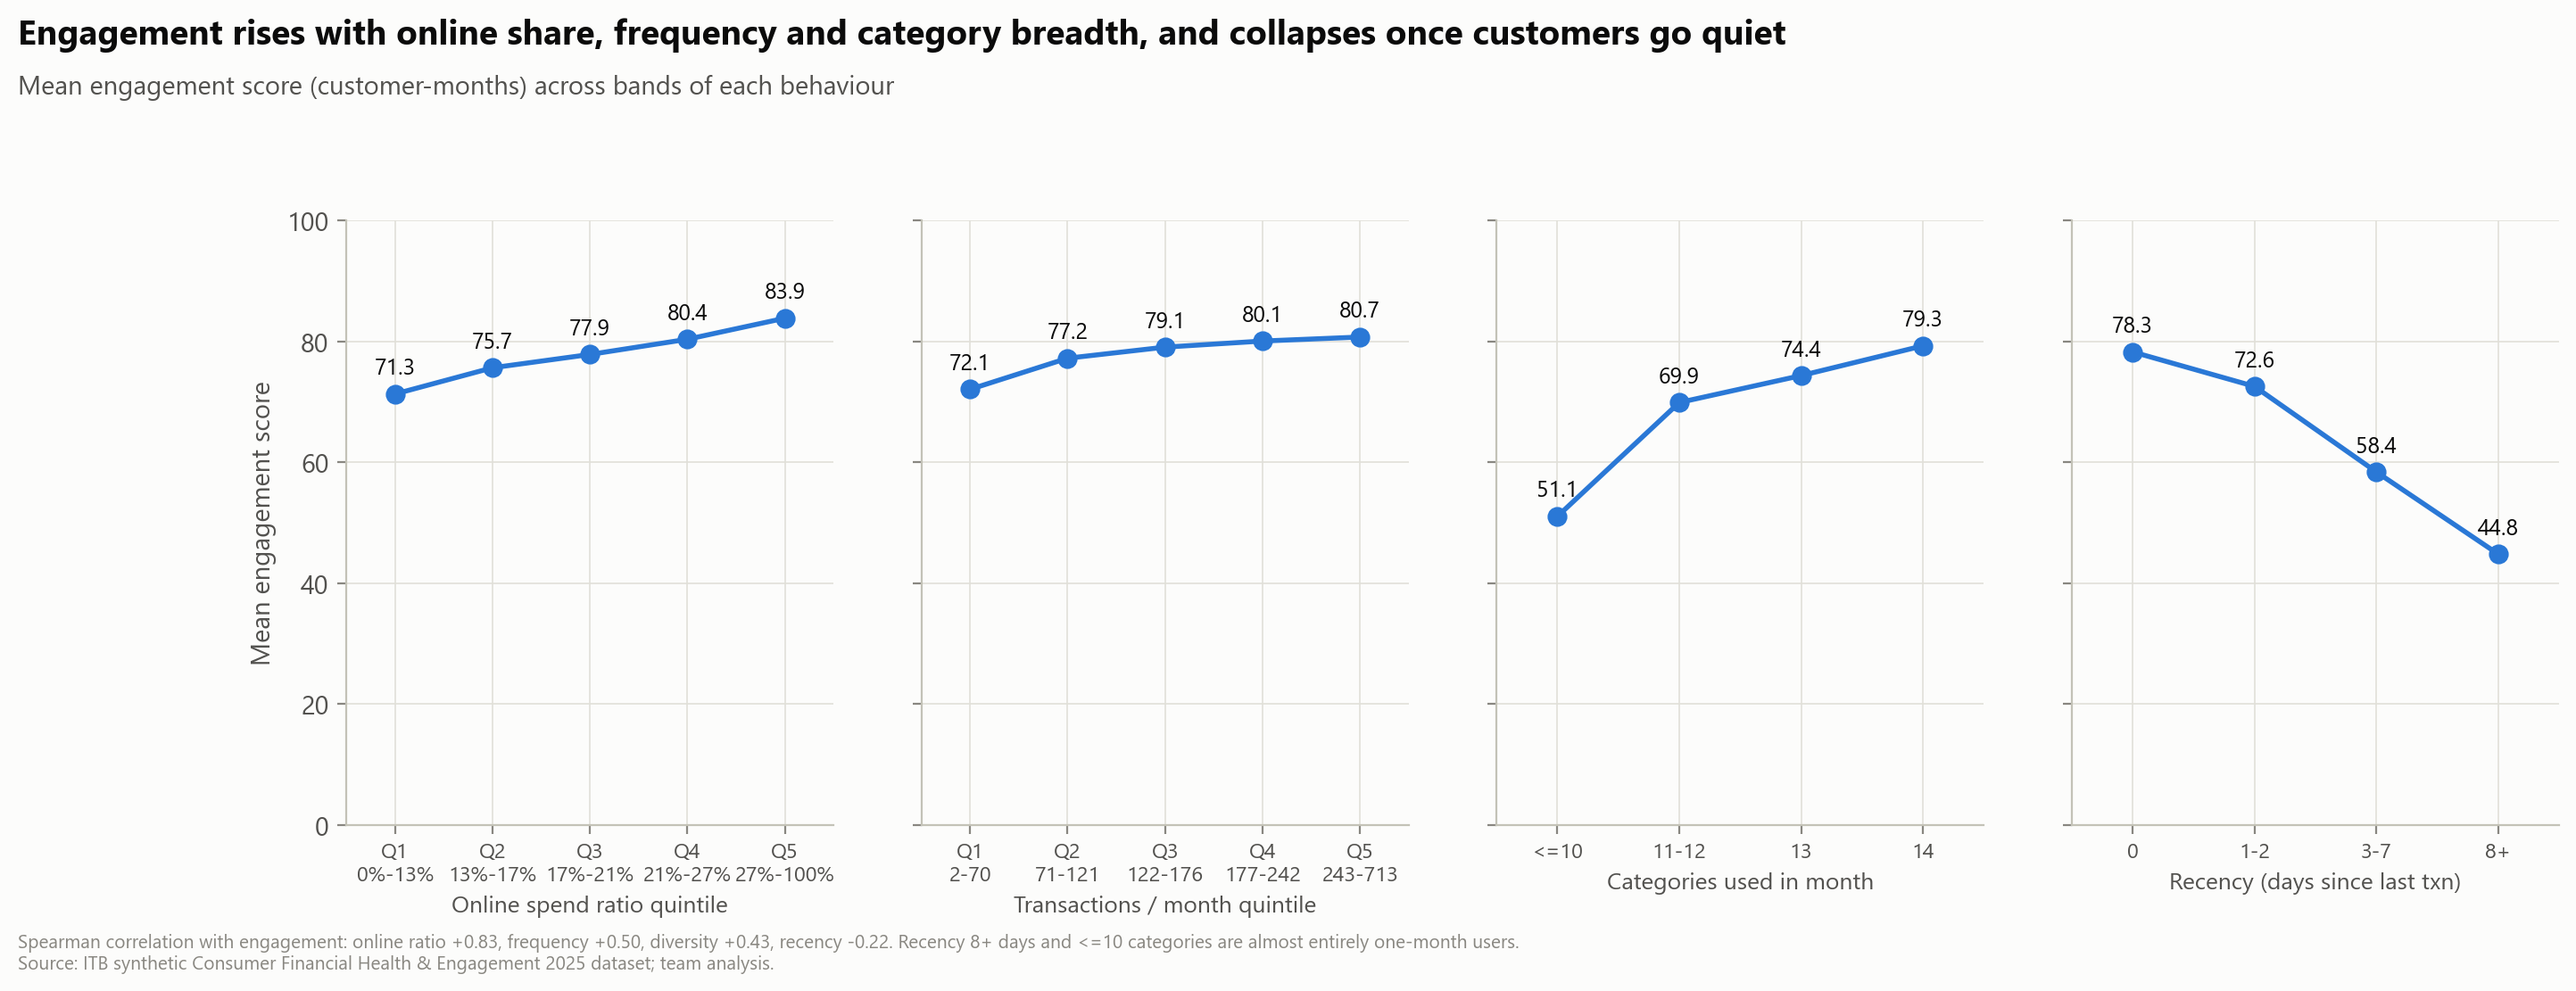

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4), sharey=True, gridspec_kw={"wspace": 0.18})
panels = [(ov, [f"{i.split()[0]}\n{r.lo:.0%}-{r.hi:.0%}" for i, r in ov.iterrows()], "Online spend ratio quintile"),
          (fv, [f"{i.split()[0]}\n{r.lo:.0f}-{r.hi:.0f}" for i, r in fv.iterrows()], "Transactions / month quintile"),
          (dv, list(dv.index.astype(str)), "Categories used in month"),
          (rv, list(rv.index.astype(str)), "Recency (days since last txn)")]
for ax, (d, labs, xl) in zip(axes, panels):
    ax.plot(labs, d.eng, color=BLUE, marker="o", ms=7)
    for i, v in enumerate(d.eng):
        ax.annotate(f"{v:.1f}", (i, v), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
    ax.set_xlabel(xl, fontsize=9.5); ax.tick_params(axis="x", labelsize=8.5)
    ax.set_xlim(-0.5, len(labs) - 0.5)
axes[0].set_ylabel("Mean engagement score"); axes[0].set_ylim(0, 100)
show_chart(fig, "t3_engagement_drivers",
     title="Engagement rises with online share, frequency and category breadth, and collapses once customers go quiet",
     subtitle="Mean engagement score (customer-months) across bands of each behaviour",
     note=f"Spearman correlation with engagement: online ratio {m.online_spend_ratio.corr(m.engagement_score, method='spearman'):+.2f}, "
          f"frequency {m.transaction_count.corr(m.engagement_score, method='spearman'):+.2f}, diversity "
          f"{m.category_diversity.corr(m.engagement_score, method='spearman'):+.2f}, recency "
          f"{m.transaction_recency_days.corr(m.engagement_score, method='spearman'):+.2f}. Recency 8+ days and <=10 categories are "
          "almost entirely one-month users.")

**Findings - Category diversity, recency, frequency and engagement**
- Spearman correlation with engagement: **online spend ratio +0.83**, digital ratio incl. QR +0.59, transactions/month +0.50, transactions per active day +0.48, **category diversity +0.43**, active days +0.42, volatility +0.33, **recency -0.22**, financial health -0.32.
- **Category diversity:** monthly range 2-14 of 14, median 14; 78.8% of customer-months use all 14 and only 1.1% use 10 or fewer. Engagement: ≤10 categories **51.1**, 11-12 69.9, 13 74.4, **14 79.3**.
- **Recency:** 0-30 days; **94.9%** of customer-months have 0 days since the last transaction. Engagement: 0 days **78.3**, 1-2 days 72.6, 3-7 days 58.4, **8+ days 44.8**.
- **Frequency:** 2-713 transactions/month, median 150 (P10 54, P90 312). Engagement by quintile: **Q1 (2-70) 72.1** → Q2 77.2 → Q3 79.1 → Q4 80.1 → **Q5 (243-713) 80.7**.
- Online ratio quintiles: **Q1 (0-13%) 71.3** → 75.7 → 77.9 → 80.4 → **Q5 (27-100%) 83.9**.
- **Interpretation:** engagement is mostly a digital-usage score. Recency 8+ days and ≤10 categories are almost entirely one-month users, which makes them early churn signals.

### 4. Financially healthy but disengaged

In [ ]:
HQ, EQ = 0.67, 0.25          # chosen cut-offs: top third on health, bottom quarter on engagement
H_CUT = c.financial_health_score.quantile(HQ)
E_CUT = c.engagement_score.quantile(EQ)
rule = (c.financial_health_score >= H_CUT) & (c.engagement_score <= E_CUT)
c["healthy_disengaged"] = rule
g = c[rule]
F.add(f"\n## 4. Financially healthy but disengaged (churn-risk)\n- Official bands cannot be used: at customer level only "
      f"{(c.financial_health_score >= 80).sum()} customers average >= 80 health, and engagement < 60 captures only "
      f"{(c.engagement_score < 60).sum()} customers, almost all one-month users. So cut-offs are relative (percentiles of the 999 customers).")
F.add(f"- HIGH health = customer mean score >= P67 = {H_CUT:.1f} (top third). LOW engagement = mean score <= P25 = {E_CUT:.1f} (bottom quarter).")
F.add(f"- Size: {len(g)} customers ({pct(len(g) / len(c))}); {int((g.months_observed == 12).sum())} are full-year but under-engaged, "
      f"{int((g.months_observed < 12).sum())} are one-month users who never came back. Share of spend {pct(g.total_spend_vnd.sum() / c.total_spend_vnd.sum())}.")
sens = []
for hq in (0.5, 0.67, 0.75):
    for eq in (0.2, 0.25, 0.33):
        r_ = (c.financial_health_score >= c.financial_health_score.quantile(hq)) & (c.engagement_score <= c.engagement_score.quantile(eq))
        sub = c[r_ & full]
        sens.append({"health_pct": hq, "health_cut": round(c.financial_health_score.quantile(hq), 1),
                     "eng_pct": eq, "eng_cut": round(c.engagement_score.quantile(eq), 1), "customers": int(r_.sum()),
                     "full_year": int((r_ & full).sum()), "one_month_share": round(1 - (r_ & full).sum() / max(1, r_.sum()), 3),
                     "full_year_eng_gap_to_median": round(c[full].engagement_score.median() - sub.engagement_score.mean(), 2),
                     "full_year_months_below_60": round(sub.low_health_months.mean(), 2),
                     "full_year_spend_to_income": round(sub.spend_to_income_ratio.mean(), 3)})
sens = pd.DataFrame(sens)
sens.to_csv(TABLES / "t3_healthy_disengaged_sensitivity.csv", index=False)
F.add("- Sensitivity (customers, full-year in brackets): " + "; ".join(
    f"H>=P{int(r.health_pct * 100)} ({r.health_cut}) & E<=P{int(r.eng_pct * 100)} ({r.eng_cut}): {r.customers} [{r.full_year}]"
    for r in sens.itertuples()))
S = sens.set_index(["health_pct", "eng_pct"])
chosen, e20, e33, h50, h75 = S.loc[(HQ, EQ)], S.loc[(HQ, 0.2)], S.loc[(HQ, 0.33)], S.loc[(0.5, EQ)], S.loc[(0.75, EQ)]
fy_med, fy_sd = c[full].engagement_score.median(), c[full].engagement_score.std()
z = lambda q_: (fy_med - c.engagement_score.quantile(q_)) / fy_sd
F.add(f"- Why engagement P25: full-year engagement median {fy_med:.1f}, std only {fy_sd:.1f} pts. The P25 cut ({E_CUT:.1f}) is "
      f"{z(EQ):.1f} std below that median; the P33 cut ({c.engagement_score.quantile(.33):.1f}) only {z(.33):.1f} std, i.e. inside the "
      f"normal range -> ordinary customers would be labelled disengaged. At P20 the group loses {int(chosen.full_year - e20.full_year)} of the {int(chosen.full_year)} "
      f"still-active customers and one-month users rise to {pct(e20.one_month_share, 0)} of it (vs {pct(chosen.one_month_share, 0)}).")
F.add(f"- Why health top third (P67): at the median cut the full-year members average {h50.full_year_months_below_60:.1f} months below 60 "
      f"(vs {chosen.full_year_months_below_60:.1f}) and spend-to-income {h50.full_year_spend_to_income:.2f} (vs {chosen.full_year_spend_to_income:.2f}) "
      f"-> not clearly 'healthy'. P75 only trims the group from {int(chosen.customers)} to {int(h75.customers)} without a material "
      f"change in health ({h75.full_year_months_below_60:.1f} months below 60), so P67 keeps more reachable customers at similar quality.")
healthy_engaged = c[(c.financial_health_score >= H_CUT) & (c.engagement_score > c.engagement_score.quantile(0.5))]
cols = {"financial_health_score": "Health score", "engagement_score": "Engagement", "spend_to_income_ratio": "Spend-to-income",
        "essential_spend_ratio": "Essential ratio", "online_spend_ratio": "Online ratio", "digital_txn_share": "Digital txn share",
        "transaction_count": "Txns / month", "active_transaction_days": "Active days", "category_diversity": "Category diversity",
        "channels_used": "Channels used", "low_health_months": "Months < 60", "age": "Age"}
gf = g[g.months_observed == 12]
prof = pd.DataFrame({"healthy_disengaged_all": g[list(cols)].mean(), "healthy_disengaged_full_year": gf[list(cols)].mean(),
                     "healthy_engaged": healthy_engaged[list(cols)].mean(), "full_year_customers": c[full][list(cols)].mean(),
                     "all_customers": c[list(cols)].mean()})
prof.index = [cols[k] for k in prof.index]
prof.to_csv(TABLES / "t3_healthy_disengaged_profile.csv")
F.add(f"- Profile (all {len(g)} | full-year {len(gf)} | healthy & engaged {len(healthy_engaged)} | full-year customers | all customers):")
for k, r in prof.iterrows():
    F.add(f"  - {k}: {r.healthy_disengaged_all:,.2f} | {r.healthy_disengaged_full_year:,.2f} | {r.healthy_engaged:,.2f} | {r.full_year_customers:,.2f} | {r.all_customers:,.2f}")
F.add("- Age mix: " + ", ".join(f"{a} {pct(v)}" for a, v in g.age_group.value_counts(normalize=True).sort_index().items() if v > 0))
F.add("- Top occupation groups: " + ", ".join(f"{a} {pct(v)}" for a, v in g.occupation_group.value_counts(normalize=True).head(3).items()))
F.add("- Top provinces: " + ", ".join(f"{a} {v}" for a, v in g.province_city.value_counts().head(3).items()))
g[["consumer_id", "months_observed", "financial_health_score", "engagement_score", "online_spend_ratio",
   "transaction_count", "age_group", "occupation_group", "province_city"]].to_csv(
    TABLES / "t3_healthy_disengaged_customers.csv", index=False, encoding="utf-8-sig")


## 4. Financially healthy but disengaged (churn-risk)
- Official bands cannot be used: at customer level only 1 customers average >= 80 health, and engagement < 60 captures only 90 customers, almost all one-month users. So cut-offs are relative (percentiles of the 999 customers).
- HIGH health = customer mean score >= P67 = 68.3 (top third). LOW engagement = mean score <= P25 = 74.8 (bottom quarter).
- Size: 85 customers (8.5%); 53 are full-year but under-engaged, 32 are one-month users who never came back. Share of spend 2.4%.
- Sensitivity (customers, full-year in brackets): H>=P50 (66.2) & E<=P20 (73.7): 100 [60]; H>=P50 (66.2) & E<=P25 (74.8): 127 [87]; H>=P50 (66.2) & E<=P33 (76.5): 173 [133]; H>=P67 (68.3) & E<=P20 (73.7): 71 [39]; H>=P67 (68.3) & E<=P25 (74.8): 85 [53]; H>=P67 (68.3) & E<=P33 (76.5): 115 [83]; H>=P75 (69.3) & E<=P20 (73.7): 55 [27]; H>=P75 (69.3) & E<=P25 (74.8): 66 [38]; H>=P75 (69.3) & E<=P33 (76.5): 87 [59]
- Why engagement P25: full-year engagement median 7

#### 📊 Chart: `t3_healthy_disengaged`

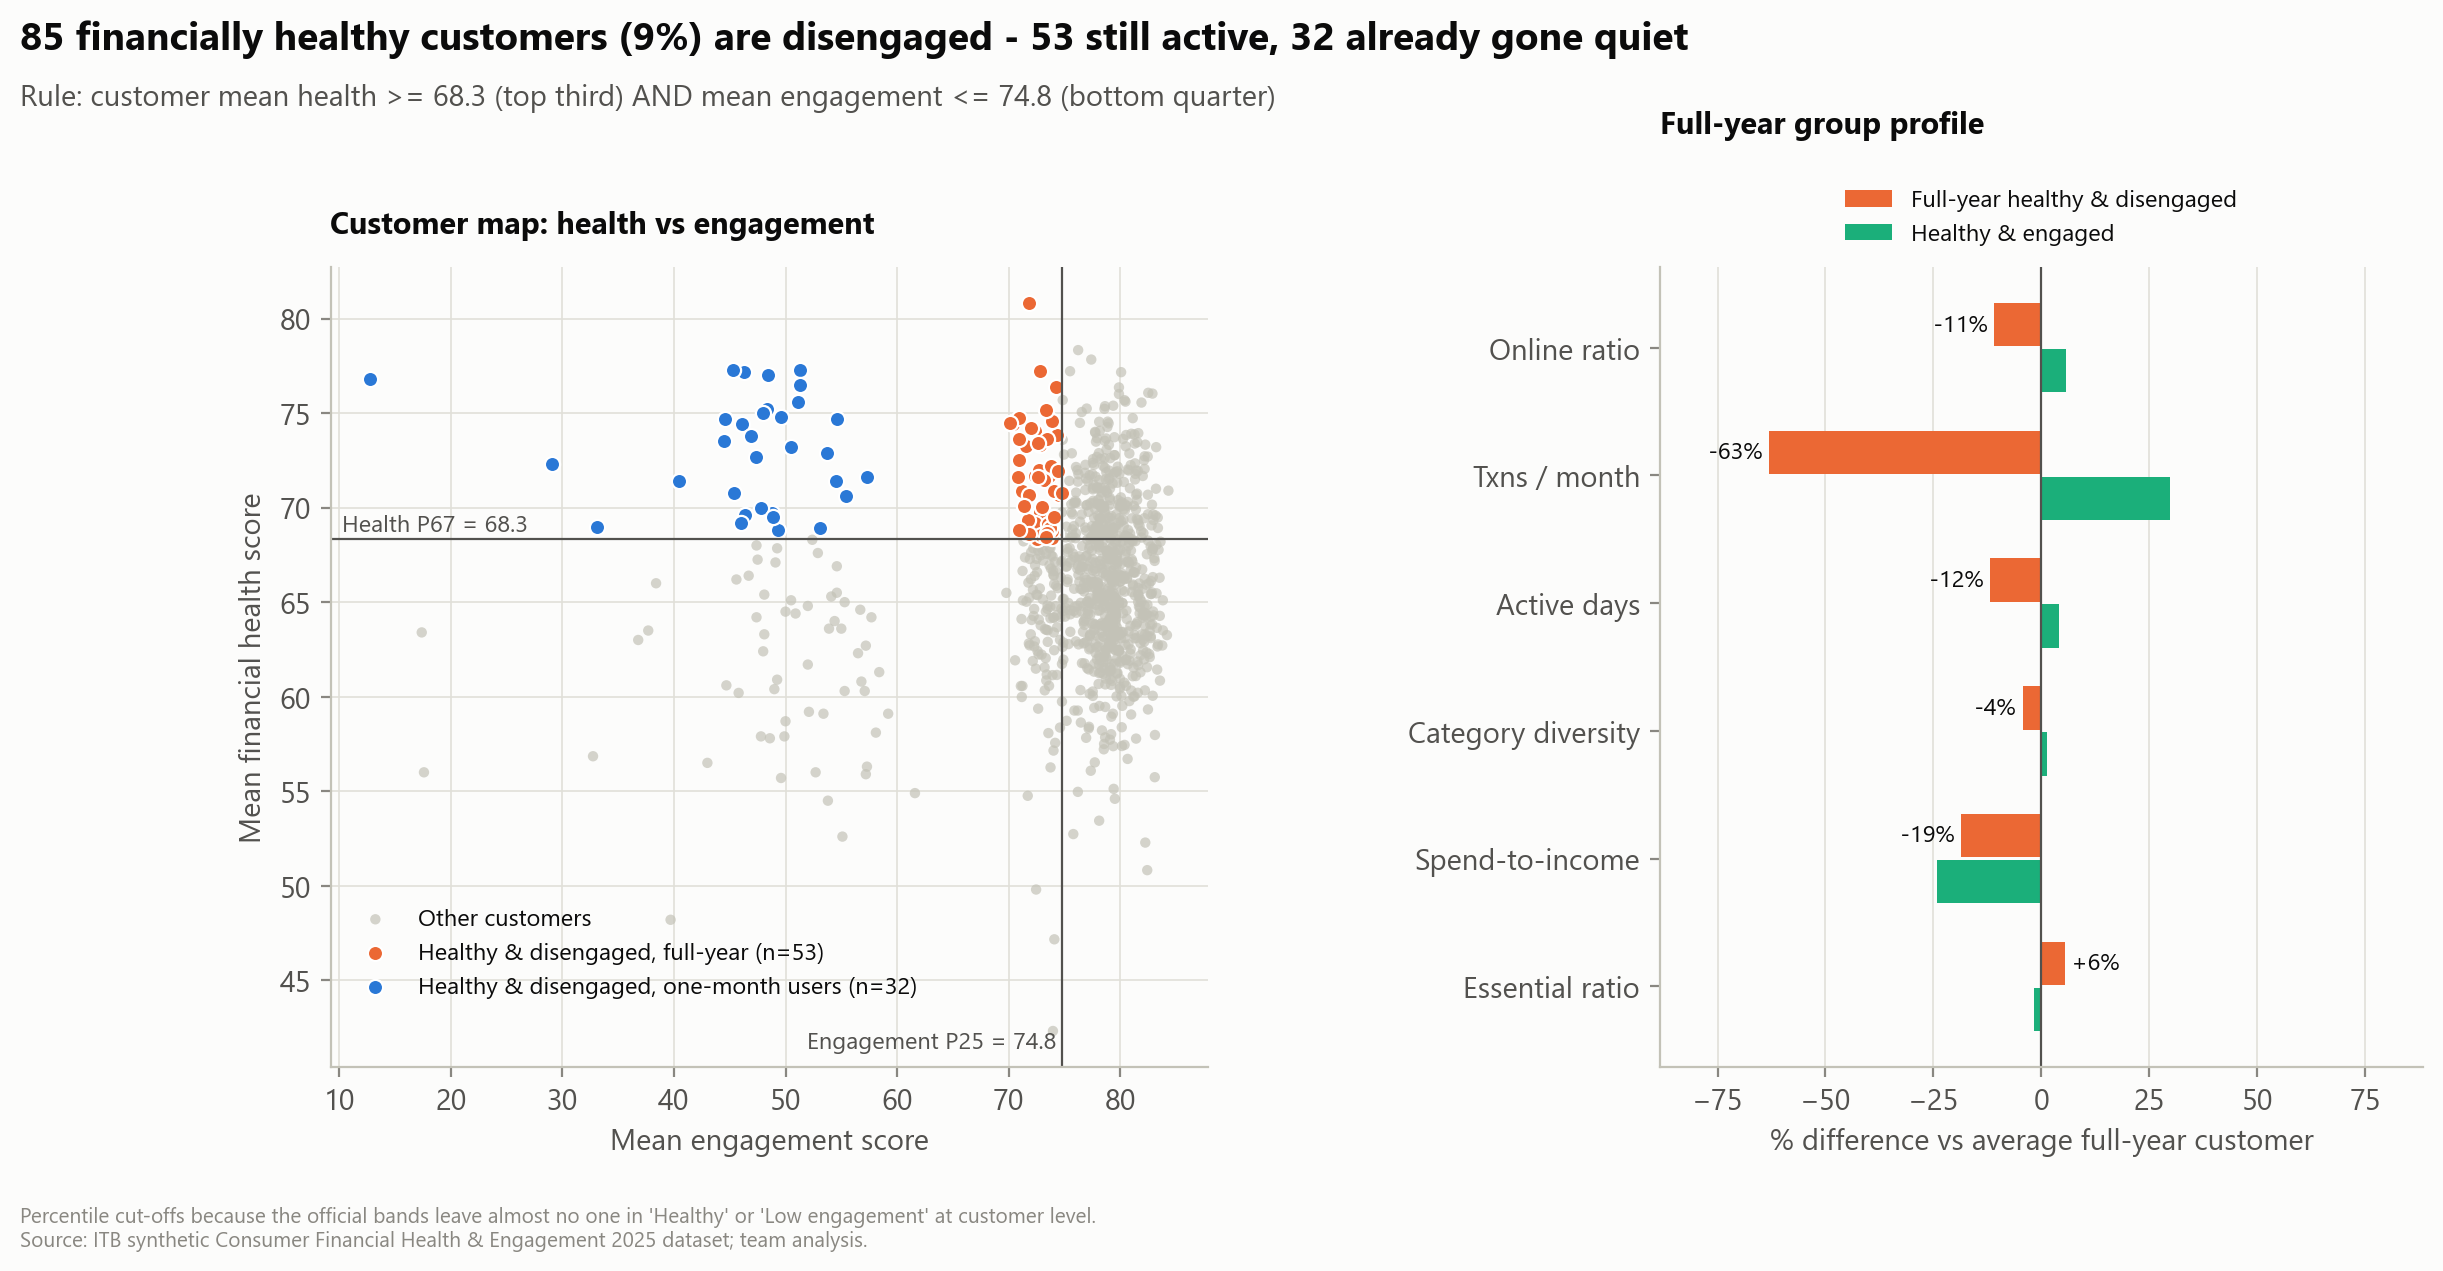

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), gridspec_kw={"width_ratios": [1.15, 1], "wspace": 0.55})
ax = axes[0]
ax.scatter(c.engagement_score[~rule], c.financial_health_score[~rule], s=14, color=GRAY, alpha=0.7, edgecolor="none",
           label="Other customers")
gm = rule & full
ax.scatter(c.engagement_score[gm], c.financial_health_score[gm], s=30, color=ORANGE, edgecolor="white", linewidth=0.8,
           label=f"Healthy & disengaged, full-year (n={gm.sum()})")
go = rule & ~full
ax.scatter(c.engagement_score[go], c.financial_health_score[go], s=30, color=BLUE, edgecolor="white", linewidth=0.8,
           label=f"Healthy & disengaged, one-month users (n={go.sum()})")
ax.axhline(H_CUT, color=INK_2, lw=0.8); ax.axvline(E_CUT, color=INK_2, lw=0.8)
ax.text(ax.get_xlim()[0] + 1, H_CUT + 0.4, f"Health P67 = {H_CUT:.1f}", fontsize=8.5, color=INK_2)
ax.text(E_CUT - 0.5, ax.get_ylim()[0] + 1, f"Engagement P25 = {E_CUT:.1f}", fontsize=8.5, color=INK_2, ha="right")
ax.set_xlabel("Mean engagement score"); ax.set_ylabel("Mean financial health score")
ax.legend(loc="lower left", fontsize=8.5, bbox_to_anchor=(0, 0.06))
ax.set_title("Customer map: health vs engagement", fontsize=11)
ax = axes[1]
show = ["Online ratio", "Txns / month", "Active days", "Category diversity", "Spend-to-income", "Essential ratio"]
base = prof.loc[show, "full_year_customers"]
rel = pd.DataFrame({"Full-year healthy & disengaged": prof.loc[show, "healthy_disengaged_full_year"] / base - 1,
                    "Healthy & engaged": prof.loc[show, "healthy_engaged"] / base - 1}) * 100
yy = np.arange(len(show))[::-1]
ax.barh(yy + 0.18, rel.iloc[:, 0], height=0.34, color=ORANGE, label=rel.columns[0])
ax.barh(yy - 0.18, rel.iloc[:, 1], height=0.34, color=AQUA, label=rel.columns[1])
ax.axvline(0, color=INK_2, lw=0.8)
for yi, a in zip(yy, rel.iloc[:, 0]):
    ax.text(a, yi + 0.18, f" {a:+.0f}% " if a >= 0 else f" {a:+.0f}% ", ha="left" if a >= 0 else "right", va="center", fontsize=8.5)
ax.set_yticks(yy, show); ax.grid(axis="y", visible=False)
lim = np.abs(rel.values).max() * 1.4
ax.set_xlim(-lim, lim)
ax.set_xlabel("% difference vs average full-year customer")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), fontsize=8.5, ncol=1)
ax.set_title("Full-year group profile", fontsize=11, pad=48)
show_chart(fig, "t3_healthy_disengaged",
     title=f"{len(g)} financially healthy customers ({pct(len(g) / len(c), 0)}) are disengaged - {gm.sum()} still active, {go.sum()} already gone quiet",
     subtitle=f"Rule: customer mean health >= {H_CUT:.1f} (top third) AND mean engagement <= {E_CUT:.1f} (bottom quarter)",
     note="Percentile cut-offs because the official bands leave almost no one in 'Healthy' or 'Low engagement' at customer level.")

**Findings - Financially healthy but NOT engaged (churn risk)**
- **Why not the official bands:** at customer level only 1 customer averages ≥80 health, and engagement <60 captures only 90 customers, almost all one-month users. Cut-offs are therefore percentiles of the 999 customers.
- **Cut-offs:** HIGH health = mean score **≥ P67 = 68.3** (top third). LOW engagement = mean score **≤ P25 = 74.8** (bottom quarter).
- **Size: 85 customers (8.5%)**: **53 full-year but under-engaged** plus **32 one-month users who never came back**. They hold 2.4% of spend.
- **Why P25 engagement:** full-year engagement has median 78.5 and std only 3.1 pts. The P25 cut is **1.2 std** below the median, while P33 (76.5) is only 0.7 std below, inside the normal range, so ordinary customers would be labelled disengaged. At P20 the group loses 14 of the 53 still-active customers and one-month users rise to 45% of it (vs 38%).
- **Why health top third:** at the median cut, full-year members average 2.1 months below 60 (vs 1.7) and spend-to-income 0.62 (vs 0.57), so they are not clearly "healthy". P75 only trims the group from 85 to 66 with no material change in health (1.4 months below 60).

| Sensitivity (customers [full-year]) | Eng ≤ P20 (73.7) | Eng ≤ P25 (74.8) | Eng ≤ P33 (76.5) |
|---|---|---|---|
| Health ≥ P50 (66.2) | 100 [60] | 127 [87] | 173 [133] |
| **Health ≥ P67 (68.3)** | 71 [39] | **85 [53]** | 115 [83] |
| Health ≥ P75 (69.3) | 55 [27] | 66 [38] | 87 [59] |

| Profile | Healthy & disengaged (all 85) | ... full-year (53) | Healthy & engaged (154) | Full-year customers |
|---|---|---|---|---|
| Health score | 72.1 | 71.5 | 71.1 | 66.4 |
| Engagement | 63.0 | 72.8 | 80.2 | 78.1 |
| Spend-to-income | 0.54 | 0.57 | 0.53 | 0.70 |
| Online ratio | 0.35 | 0.18 | 0.22 | 0.21 |
| Txns / month | 42.8 | 62.6 | 220.6 | 169.9 |
| Active days | 16.6 | 25.5 | 30.0 | 28.9 |
| Category diversity | 10.0 | 13.1 | 13.9 | 13.7 |
| Age (mean) | 55.3 | 53.8 | 45.2 | 49.2 |

- **Who they are:** older (55-64 31.8%, 65+ 27.1%), mostly **Engineering & IT (35.3%)**, Finance/legal/business (17.6%) and Healthcare (16.5%). Top provinces: TP. Hồ Chí Minh 10, Cần Thơ 10, Hà Nội 5.
- **Implication:** the full-year members have healthy finances but use the card for only a slice of their spending (**63% fewer transactions** and an 11% lower online ratio than a typical full-year customer). This is a retention and share-of-wallet opportunity, not a risk.

In [ ]:
c[["consumer_id", "healthy_disengaged"]].to_parquet(TABLES.parent.parent / "data_cache" / "t3_flags.parquet", index=False)